# CSCI 7350 Project: Predicting Cancer Drug Sensitivity
This notebook cleans the RNA-seq matrix, merges it with GDSC drug response and model metadata, and trains baseline ML models.

**Important correction:** the RNA-seq file should be read with its original header row intact. The first three *data rows* are metadata rows and should be dropped; do **not** replace the column names with row 2, because that destroys the `SIDM...` sample IDs.

In [ ]:
# Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings, os, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, auc, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

print("XGBoost available:", XGB_AVAILABLE)


XGBoost available: True


In [ ]:
# Set paths
DATA_DIR = "/content/drive/MyDrive/CSCI_7350_datafolder"

gene_file = f"{DATA_DIR}/rnaseq_merged_rsem_tpm_20250922.csv"
drug_file = f"{DATA_DIR}/GDSC2_fitted_dose_response_27Oct23.xlsx"
meta_file = f"{DATA_DIR}/model_list_latest.csv.gz"

for f in [gene_file, drug_file, meta_file]:
    print(f, "->", os.path.exists(f))

/content/drive/MyDrive/CSCI_7350_datafolder/rnaseq_merged_rsem_tpm_20250922.csv -> True
/content/drive/MyDrive/CSCI_7350_datafolder/GDSC2_fitted_dose_response_27Oct23.xlsx -> True
/content/drive/MyDrive/CSCI_7350_datafolder/model_list_latest.csv.gz -> True


In [ ]:
# Load data
# IMPORTANT: keep the original header row in the RNA-seq file
expr_raw = pd.read_csv(gene_file, low_memory=False)
drug_df = pd.read_excel(drug_file)
meta_df = pd.read_csv(meta_file, low_memory=False)

print("expr_raw shape:", expr_raw.shape)
print("drug_df shape :", drug_df.shape)
print("meta_df shape :", meta_df.shape)

print("\nRNA-seq preview:")
display(expr_raw.head())

expr_raw shape: (41148, 1786)
drug_df shape : (242036, 16)
meta_df shape : (1984, 51)

RNA-seq preview:


,model_id,Unnamed: 1,Unnamed: 2,SIDM00001,SIDM00002,SIDM00003,SIDM00005,SIDM00006,SIDM00007,SIDM00008,...,SIDM02150,SIDM02151,SIDM02152,SIDM02153,SIDM02154,SIDM02155,SIDM02156,SIDM02157,SIDM02159,SIDM02160
0,model_name,NaN,NaN,MEC-1,NBsusSR,M14,MDA-MB-134-VI,MCC26,MCC13,MCAS,...,UPCI-SCC-200,WA-OSEL,MM253,MM485,NO36,NZM3,UM-RC-7,WM3772F,HAP1,P2UR_K-562
1,data_source,NaN,NaN,Broad,Sanger,Sanger,Broad,Sanger,Sanger,Broad,...,Broad,Broad,Broad,Broad,Broad,Broad,Broad,Broad,Broad,Broad
2,gene_symbol,ensembl_gene_id,gene_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A1BG,ENSG00000121410,SIDG00001,3.853,4.5059,3.9736,5.7038,3.9069,6.1198,0.0566,...,0.0286,3.796,2.4594,1.5261,0.0426,3.4594,0.1635,3.0807,2.4906,1.5705
4,A1BG-AS1,ENSG00000268895,SIDG00002,1.8156,2.3868,3.1408,3.3334,2.5801,3.5336,0.0976,...,0.0704,1.5753,2.6893,2.5729,0.2016,3.1938,0.4647,2.6064,1.9672,1.3161


## 1. Clean the RNA-seq matrix
The RNA-seq file already has correct column names like `model_id`, `Unnamed: 1`, `Unnamed: 2`, `SIDM00001`, ...
Rows 0–2 are metadata rows inside the table. We keep the original columns and drop those rows.

In [ ]:
# Drop the first three metadata rows (model_name, data_source, gene_symbol helper row)
expr = expr_raw.iloc[3:].copy().reset_index(drop=True)

# Force the first three columns to the names we need, by position
cols = list(expr.columns)
cols[0] = "gene_symbol"
cols[1] = "ensembl_gene_id"
cols[2] = "gene_id"
expr.columns = cols

print("First 10 columns after fix:")
print(list(expr.columns[:10]))
display(expr.head())

First 10 columns after fix:
['gene_symbol', 'ensembl_gene_id', 'gene_id', 'SIDM00001', 'SIDM00002', 'SIDM00003', 'SIDM00005', 'SIDM00006', 'SIDM00007', 'SIDM00008']


,gene_symbol,ensembl_gene_id,gene_id,SIDM00001,SIDM00002,SIDM00003,SIDM00005,SIDM00006,SIDM00007,SIDM00008,...,SIDM02150,SIDM02151,SIDM02152,SIDM02153,SIDM02154,SIDM02155,SIDM02156,SIDM02157,SIDM02159,SIDM02160
0,A1BG,ENSG00000121410,SIDG00001,3.853,4.5059,3.9736,5.7038,3.9069,6.1198,0.0566,...,0.0286,3.796,2.4594,1.5261,0.0426,3.4594,0.1635,3.0807,2.4906,1.5705
1,A1BG-AS1,ENSG00000268895,SIDG00002,1.8156,2.3868,3.1408,3.3334,2.5801,3.5336,0.0976,...,0.0704,1.5753,2.6893,2.5729,0.2016,3.1938,0.4647,2.6064,1.9672,1.3161
2,A1CF,ENSG00000148584,SIDG00003,0.0,0.0286,0.0144,0.0566,0.0426,0.0144,0.0426,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A2M,ENSG00000175899,SIDG00004,0.2388,0.5753,4.1326,0.5261,5.6562,0.0976,0.0976,...,0.111,0.0,6.9176,9.5967,0.0,10.3639,0.251,9.4471,0.0144,0.4114
4,A2M-AS1,ENSG00000245105,SIDG00005,0.0,0.3448,0.4114,1.4489,0.5656,0.6599,0.0286,...,0.0976,0.0,0.2987,0.3785,0.0286,1.2327,1.0356,1.3785,0.0976,0.0144


In [ ]:
# Keep gene IDs and SIDM sample columns
id_cols = ["gene_symbol", "ensembl_gene_id", "gene_id"]
sidm_cols = [c for c in expr.columns if isinstance(c, str) and c.startswith("SIDM")]

expr_small = expr[id_cols + sidm_cols].copy()

# Convert expression values to numeric
for c in sidm_cols:
    expr_small[c] = pd.to_numeric(expr_small[c], errors="coerce")

print("expr_small shape:", expr_small.shape)
print("number of SIDM columns:", len(sidm_cols))
display(expr_small.head())

expr_small shape: (41145, 1786)
number of SIDM columns: 1783


,gene_symbol,ensembl_gene_id,gene_id,SIDM00001,SIDM00002,SIDM00003,SIDM00005,SIDM00006,SIDM00007,SIDM00008,...,SIDM02150,SIDM02151,SIDM02152,SIDM02153,SIDM02154,SIDM02155,SIDM02156,SIDM02157,SIDM02159,SIDM02160
0,A1BG,ENSG00000121410,SIDG00001,3.8530,4.5059,3.9736,5.7038,3.9069,6.1198,0.0566,...,0.0286,3.7960,2.4594,1.5261,0.0426,3.4594,0.1635,3.0807,2.4906,1.5705
1,A1BG-AS1,ENSG00000268895,SIDG00002,1.8156,2.3868,3.1408,3.3334,2.5801,3.5336,0.0976,...,0.0704,1.5753,2.6893,2.5729,0.2016,3.1938,0.4647,2.6064,1.9672,1.3161
2,A1CF,ENSG00000148584,SIDG00003,0.0000,0.0286,0.0144,0.0566,0.0426,0.0144,0.0426,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,A2M,ENSG00000175899,SIDG00004,0.2388,0.5753,4.1326,0.5261,5.6562,0.0976,0.0976,...,0.1110,0.0000,6.9176,9.5967,0.0000,10.3639,0.2510,9.4471,0.0144,0.4114
4,A2M-AS1,ENSG00000245105,SIDG00005,0.0000,0.3448,0.4114,1.4489,0.5656,0.6599,0.0286,...,0.0976,0.0000,0.2987,0.3785,0.0286,1.2327,1.0356,1.3785,0.0976,0.0144


In [ ]:
# Transpose so rows = cell lines and columns = genes
expr_t = expr_small.set_index("gene_symbol")[sidm_cols].T
expr_t.index.name = "SANGER_MODEL_ID"
expr_t.reset_index(inplace=True)

# Clean model IDs
expr_t["SANGER_MODEL_ID"] = expr_t["SANGER_MODEL_ID"].astype(str).str.strip()

print("expr_t shape:", expr_t.shape)
display(expr_t.iloc[:5, :8])

print("Example expression IDs:")
print(expr_t["SANGER_MODEL_ID"].head().tolist())

expr_t shape: (1783, 41146)


gene_symbol,SANGER_MODEL_ID,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1
0,SIDM00001,3.8530,1.8156,0.0000,0.2388,0.0000,0.0000,0.0
1,SIDM00002,4.5059,2.3868,0.0286,0.5753,0.3448,0.4751,0.0
2,SIDM00003,3.9736,3.1408,0.0144,4.1326,0.4114,0.0000,0.0
3,SIDM00005,5.7038,3.3334,0.0566,0.5261,1.4489,0.4114,0.0
4,SIDM00006,3.9069,2.5801,0.0426,5.6562,0.5656,0.1506,0.0


Example expression IDs:
['SIDM00001', 'SIDM00002', 'SIDM00003', 'SIDM00005', 'SIDM00006']


## 2. Inspect drug-response columns and choose one drug

In [ ]:
print("Drug columns:")
print(drug_df.columns.tolist())

candidate_cols = [c for c in drug_df.columns if "IC50" in str(c).upper() or "AUC" in str(c).upper() or "AAC" in str(c).upper()]
print("\nPossible response columns:", candidate_cols)

# Clean SANGER ids in drug table
if "SANGER_MODEL_ID" not in drug_df.columns:
    raise ValueError("Expected SANGER_MODEL_ID in drug_df columns, but it was not found.")

drug_df["SANGER_MODEL_ID"] = drug_df["SANGER_MODEL_ID"].astype(str).str.strip()

Drug columns:
['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'CANCER_TYPE', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE']

Possible response columns: ['LN_IC50', 'AUC']


In [ ]:
# Show drugs with the most samples
drug_counts = (
    drug_df.groupby(["DRUG_NAME", "DRUG_ID"])
    .size()
    .reset_index(name="n_samples")
    .sort_values("n_samples", ascending=False)
)

display(drug_counts.head(20))

# Pick a drug with many samples to start
SELECTED_DRUG = drug_counts.iloc[0]["DRUG_NAME"]
print("Selected drug:", SELECTED_DRUG)

,DRUG_NAME,DRUG_ID,n_samples
164,MG-132,1862,969
74,Camptothecin,1003,968
245,Staurosporine,1034,968
211,Palbociclib,1054,968
188,Nutlin-3a (-),1047,968
201,PD0325901,1060,968
168,MK-2206,1053,968
3,5-Fluorouracil,1073,968
195,Oxaliplatin,1089,967
89,Docetaxel,1007,967


Selected drug: MG-132


In [ ]:
# Choose response column
if "LN_IC50" in drug_df.columns:
    response_col = "LN_IC50"
elif "IC50" in drug_df.columns:
    response_col = "IC50"
else:
    raise ValueError("Could not find LN_IC50 or IC50 in the drug table.")

print("Using response column:", response_col)

# Subset one drug
drug_one = drug_df[drug_df["DRUG_NAME"] == SELECTED_DRUG].copy()
drug_one = drug_one.dropna(subset=["SANGER_MODEL_ID", response_col])

print("Rows for selected drug:", drug_one.shape[0])
display(drug_one[["DRUG_NAME", "DRUG_ID", "SANGER_MODEL_ID", response_col]].head())

Using response column: LN_IC50
Rows for selected drug: 969


,DRUG_NAME,DRUG_ID,SANGER_MODEL_ID,LN_IC50
174561,MG-132,1862,SIDM01132,-2.241984
174562,MG-132,1862,SIDM00848,-1.530673
174563,MG-132,1862,SIDM00263,-1.779004
174564,MG-132,1862,SIDM00269,-1.506388
174565,MG-132,1862,SIDM00203,-1.253027


## 3. Merge debugging
This section explicitly checks overlap between expression IDs and drug IDs before merging.

In [ ]:
print("Example expr_t IDs:", expr_t["SANGER_MODEL_ID"].head(10).tolist())
print("Example drug_one IDs:", drug_one["SANGER_MODEL_ID"].head(10).tolist())

common_ids = set(expr_t["SANGER_MODEL_ID"]) & set(drug_one["SANGER_MODEL_ID"])
print("Common ID count:", len(common_ids))

if len(common_ids) == 0:
    # Optional diagnostics
    expr_preview = sorted(list(set(expr_t["SANGER_MODEL_ID"])))[:10]
    drug_preview = sorted(list(set(drug_one["SANGER_MODEL_ID"])))[:10]
    print("\nNo overlapping IDs found.")
    print("First 10 unique expression IDs:", expr_preview)
    print("First 10 unique drug IDs:", drug_preview)
    raise ValueError("Merge would be empty because there are no common SANGER_MODEL_ID values. Inspect the previews above.")

Example expr_t IDs: ['SIDM00001', 'SIDM00002', 'SIDM00003', 'SIDM00005', 'SIDM00006', 'SIDM00007', 'SIDM00008', 'SIDM00009', 'SIDM00011', 'SIDM00014']
Example drug_one IDs: ['SIDM01132', 'SIDM00848', 'SIDM00263', 'SIDM00269', 'SIDM00203', 'SIDM01111', 'SIDM00909', 'SIDM00807', 'SIDM01085', 'SIDM01160']
Common ID count: 944


In [ ]:
# Optional metadata table
meta_use = meta_df.copy()
if "model_id" in meta_use.columns:
    meta_use["model_id"] = meta_use["model_id"].astype(str).str.strip()
    meta_use = meta_use.rename(columns={"model_id": "SANGER_MODEL_ID"})

# Merge
merged = drug_one.merge(expr_t, on="SANGER_MODEL_ID", how="inner")
print("Merged shape after drug + expression:", merged.shape)

# Merge metadata if available
if "SANGER_MODEL_ID" in meta_use.columns:
    keep_meta = [c for c in [
        "SANGER_MODEL_ID", "model_name", "BROAD_ID", "CCLE_ID", "COSMIC_ID",
        "cancer_type", "tissue", "growth_properties"
    ] if c in meta_use.columns]
    merged = merged.merge(meta_use[keep_meta].drop_duplicates(), on="SANGER_MODEL_ID", how="left")

print("Merged shape after metadata:", merged.shape)
display(merged.head())

Merged shape after drug + expression: (944, 41161)
Merged shape after metadata: (944, 41168)


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,...,ZYXP1,ZZEF1,ZZZ3,model_name,BROAD_ID,CCLE_ID,COSMIC_ID,cancer_type,tissue,growth_properties
0,GDSC2,343,15946488,PFSK-1,SIDM01132,Other Solid Cancers,1862,MG-132,"Proteasome, CAPN1",Protein stability and degradation,...,0.0,4.1554,4.0575,PFSK-1,ACH-001711,PFSK1_CENTRAL_NERVOUS_SYSTEM,683667,Other Solid Cancers,Central Nervous System,Adherent
1,GDSC2,343,15946753,A673,SIDM00848,Ewing's Sarcoma,1862,MG-132,"Proteasome, CAPN1",Protein stability and degradation,...,NaN,3.6064,4.5211,A673,ACH-000052,A673_BONE,684052,Ewing's Sarcoma,Bone,Adherent
2,GDSC2,343,15947040,ES5,SIDM00263,Ewing's Sarcoma,1862,MG-132,"Proteasome, CAPN1",Protein stability and degradation,...,0.0,4.5759,5.6946,ES5,ACH-002106,ES5_BONE,684057,Ewing's Sarcoma,Bone,Unknown
3,GDSC2,343,15947292,ES7,SIDM00269,Ewing's Sarcoma,1862,MG-132,"Proteasome, CAPN1",Protein stability and degradation,...,0.0,4.9340,5.4561,ES7,ACH-002108,ES7_BONE,684059,Ewing's Sarcoma,Bone,Unknown
4,GDSC2,343,15947574,EW-11,SIDM00203,Ewing's Sarcoma,1862,MG-132,"Proteasome, CAPN1",Protein stability and degradation,...,0.0,4.3590,5.3366,EW-11,ACH-002111,EW11_BONE,684062,Ewing's Sarcoma,Bone,Unknown


In [ ]:
merged.iloc[:, :100].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 100 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DATASET          944 non-null    object 
 1   NLME_RESULT_ID   944 non-null    int64  
 2   NLME_CURVE_ID    944 non-null    int64  
 3   CELL_LINE_NAME   944 non-null    object 
 4   SANGER_MODEL_ID  944 non-null    object 
 5   CANCER_TYPE      944 non-null    object 
 6   DRUG_ID          944 non-null    int64  
 7   DRUG_NAME        944 non-null    object 
 8   PUTATIVE_TARGET  944 non-null    object 
 9   PATHWAY_NAME     944 non-null    object 
 10  MIN_CONC         944 non-null    float64
 11  MAX_CONC         944 non-null    float64
 12  LN_IC50          944 non-null    float64
 13  AUC              944 non-null    float64
 14  RMSE             944 non-null    float64
 15  Z_SCORE          944 non-null    float64
 16  A1BG             944 non-null    float64
 17  A1BG-AS1       

In [ ]:
merged=merged.drop(['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET'], axis=1)

In [ ]:
merged.iloc[:, :100].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 100 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CANCER_TYPE   944 non-null    object 
 1   PATHWAY_NAME  944 non-null    object 
 2   MIN_CONC      944 non-null    float64
 3   MAX_CONC      944 non-null    float64
 4   LN_IC50       944 non-null    float64
 5   AUC           944 non-null    float64
 6   RMSE          944 non-null    float64
 7   Z_SCORE       944 non-null    float64
 8   A1BG          944 non-null    float64
 9   A1BG-AS1      944 non-null    float64
 10  A1CF          944 non-null    float64
 11  A2M           944 non-null    float64
 12  A2M-AS1       944 non-null    float64
 13  A2ML1         944 non-null    float64
 14  A2ML1-AS1     944 non-null    float64
 15  A2ML1-AS2     944 non-null    float64
 16  A2MP1         944 non-null    float64
 17  A3GALT2       944 non-null    float64
 18  A4GALT        944 non-null   

In [ ]:
merged=merged.drop(['PATHWAY_NAME', 'MIN_CONC', 'MAX_CONC', 'AUC', 'RMSE','Z_SCORE'], axis=1)

In [ ]:
merged.iloc[:, 3000:3050].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 50 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   C2orf88      944 non-null    float64
 1   C2orf92      944 non-null    float64
 2   C3           944 non-null    float64
 3   C3AR1        944 non-null    float64
 4   C3P1         944 non-null    float64
 5   C3orf18      944 non-null    float64
 6   C3orf20      944 non-null    float64
 7   C3orf22      944 non-null    float64
 8   C3orf33      944 non-null    float64
 9   C3orf36      547 non-null    float64
 10  C3orf38      944 non-null    float64
 11  C3orf49      944 non-null    float64
 12  C3orf49P1    397 non-null    float64
 13  C3orf52      944 non-null    float64
 14  C3orf62      944 non-null    float64
 15  C3orf70      944 non-null    float64
 16  C3orf80      944 non-null    float64
 17  C3orf84      944 non-null    float64
 18  C3orf85      944 non-null    float64
 19  C3orf86P

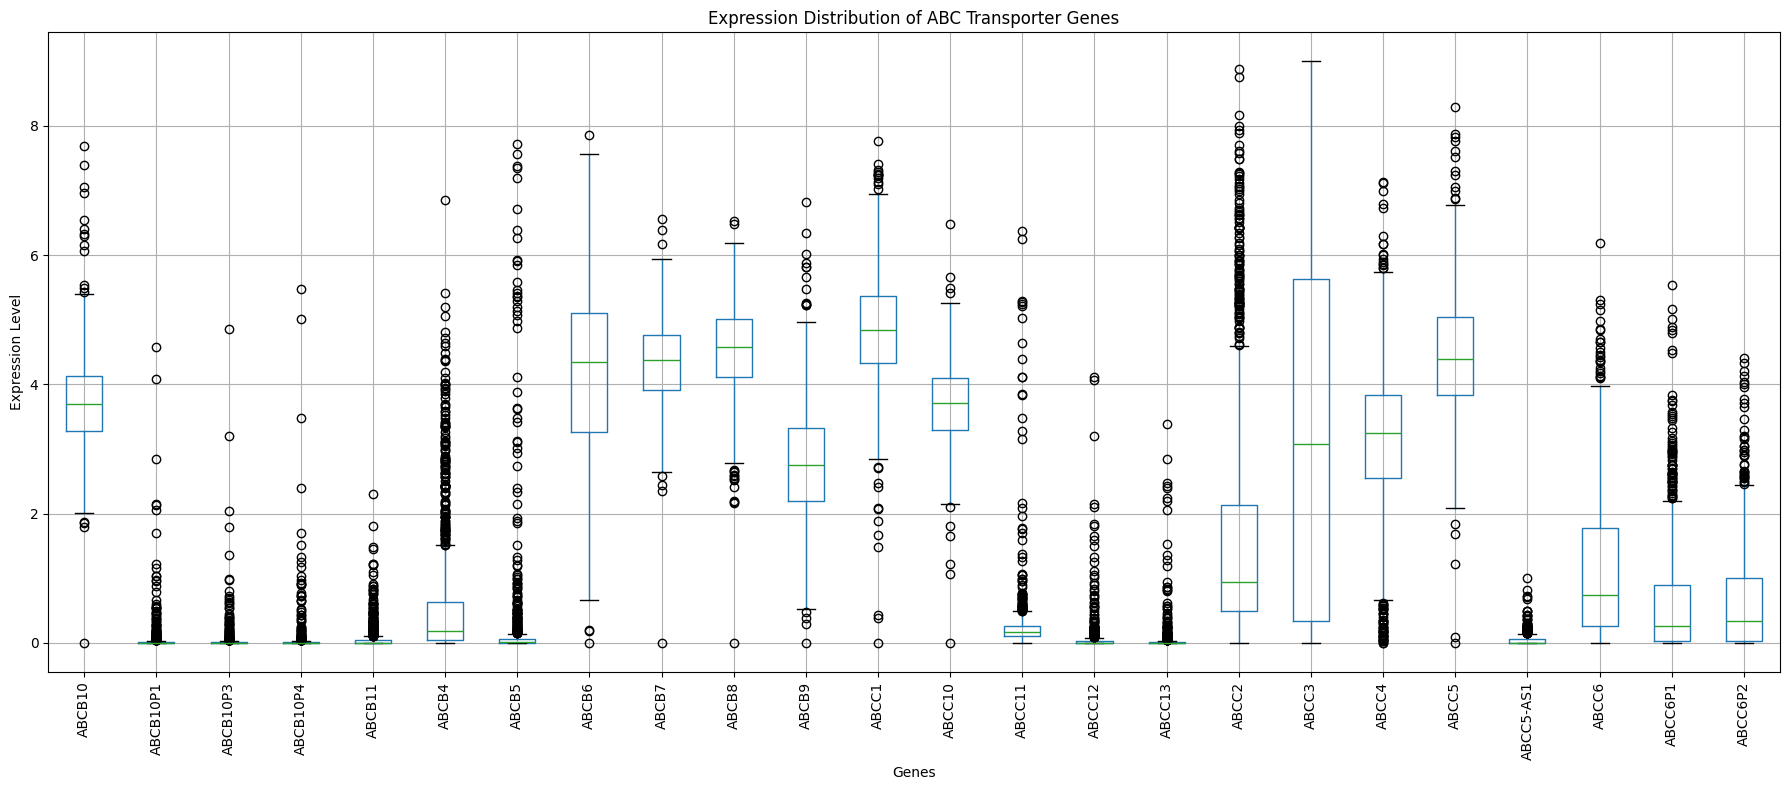

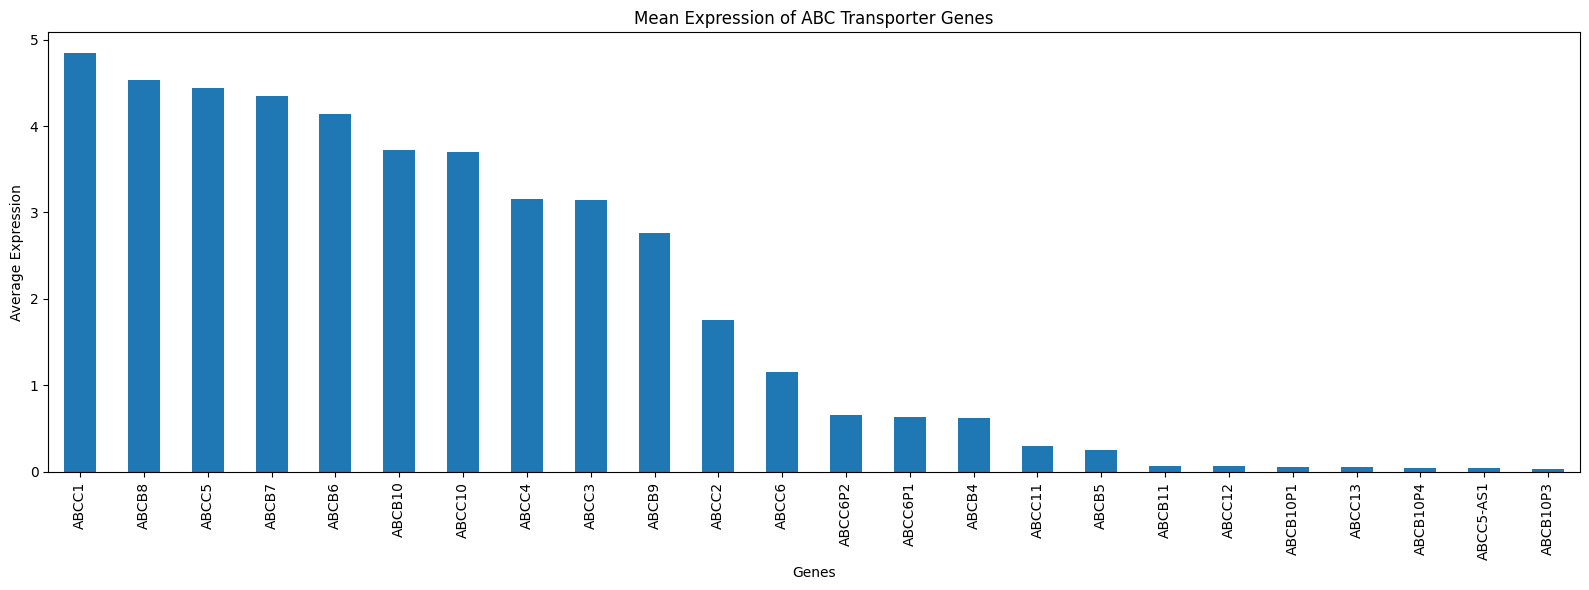

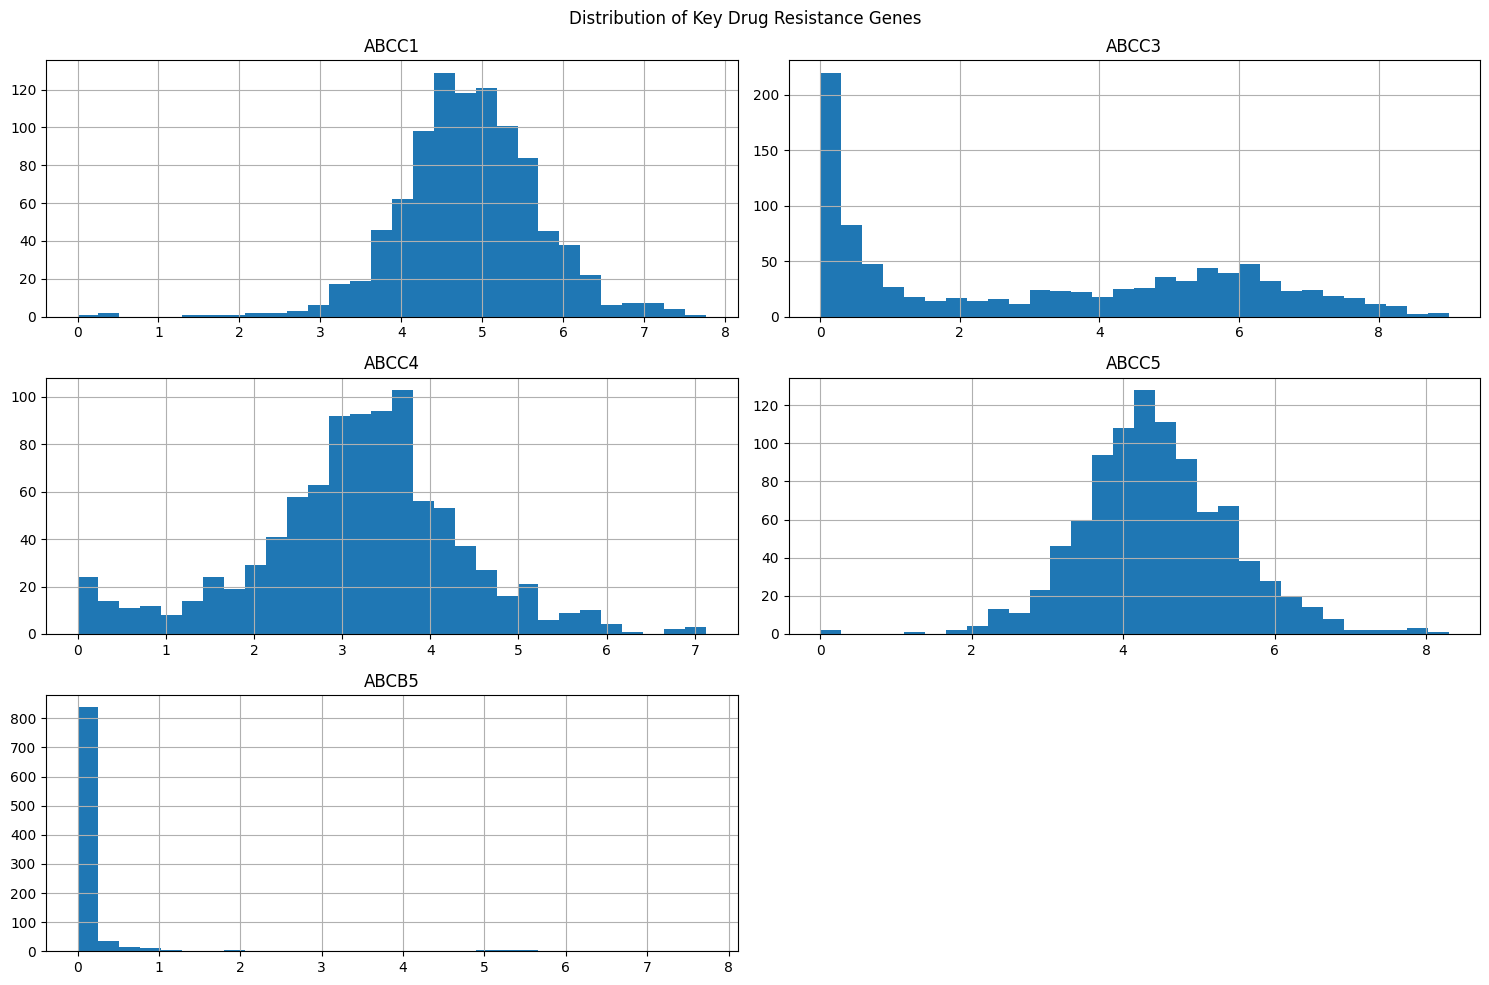

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select ABC transporter genes
abc_genes = [
    'ABCB10', 'ABCB10P1', 'ABCB10P3', 'ABCB10P4',
    'ABCB11', 'ABCB4', 'ABCB5', 'ABCB6', 'ABCB7',
    'ABCB8', 'ABCB9', 'ABCC1', 'ABCC10', 'ABCC11',
    'ABCC12', 'ABCC13', 'ABCC2', 'ABCC3', 'ABCC4',
    'ABCC5', 'ABCC5-AS1', 'ABCC6', 'ABCC6P1', 'ABCC6P2'
]

# -----------------------------
# 1. Boxplot of gene expression
# -----------------------------
plt.figure(figsize=(18,8))
merged[abc_genes].boxplot(rot=90)
plt.title("Expression Distribution of ABC Transporter Genes")
plt.ylabel("Expression Level")
plt.xlabel("Genes")
plt.tight_layout()
plt.show()


# -----------------------------
# 3. Mean expression barplot
# -----------------------------
mean_expression = merged[abc_genes].mean().sort_values(ascending=False)

plt.figure(figsize=(16,6))
mean_expression.plot(kind='bar')
plt.title("Mean Expression of ABC Transporter Genes")
plt.ylabel("Average Expression")
plt.xlabel("Genes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Histograms for major genes
# -----------------------------
major_genes = ['ABCC1', 'ABCC3', 'ABCC4', 'ABCC5', 'ABCB5']

merged[major_genes].hist(figsize=(15,10), bins=30)
plt.suptitle("Distribution of Key Drug Resistance Genes")
plt.tight_layout()
plt.show()

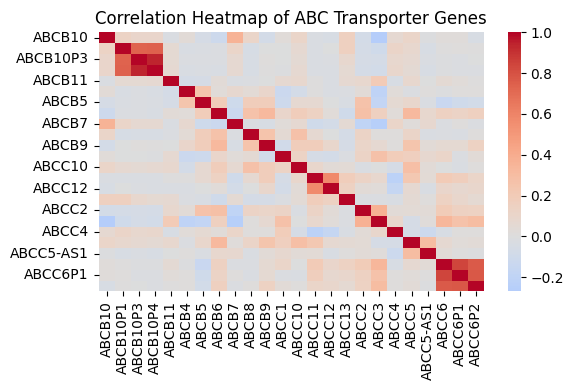

In [ ]:
# -----------------------------
# 2. Correlation heatmap
# -----------------------------
plt.figure(figsize=(6,4))
sns.heatmap(
    merged[abc_genes].corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Heatmap of ABC Transporter Genes")
plt.tight_layout()
plt.show()

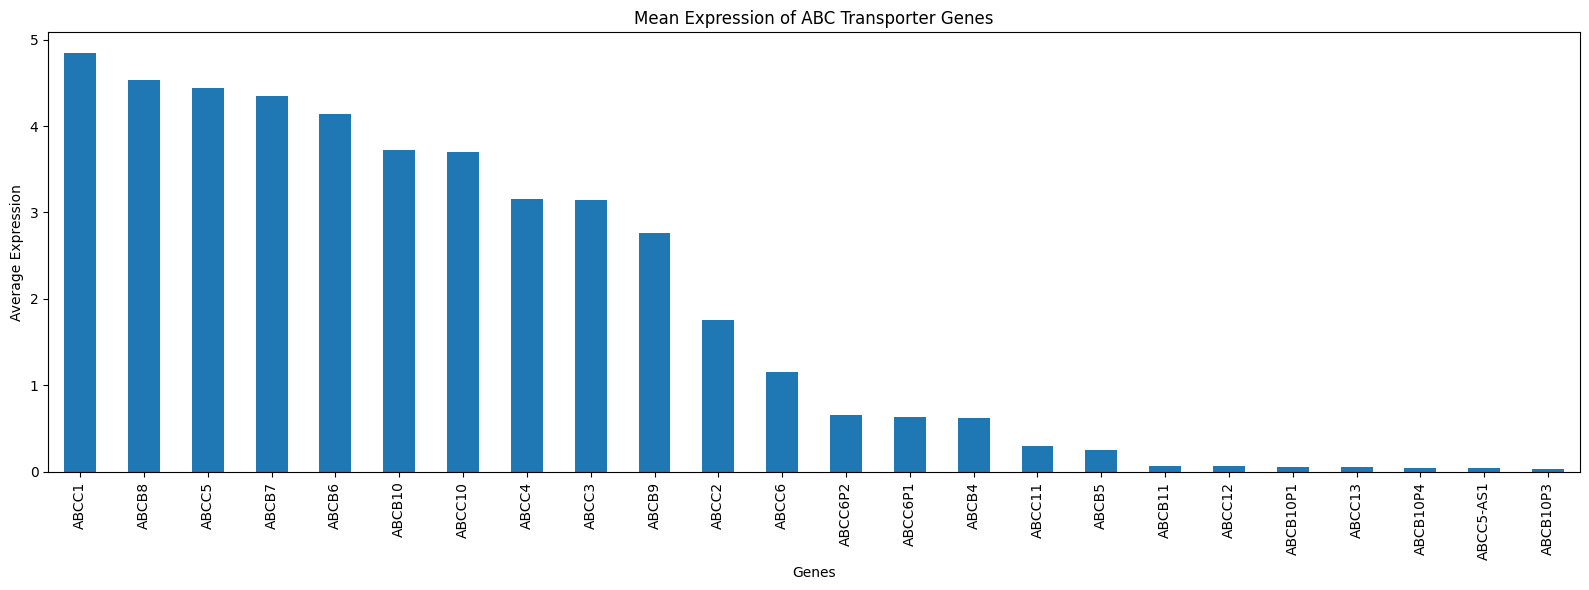

In [ ]:
# -----------------------------
# 3. Mean expression barplot
# -----------------------------
mean_expression = merged[abc_genes].mean().sort_values(ascending=False)

plt.figure(figsize=(16,6))
mean_expression.plot(kind='bar')
plt.title("Mean Expression of ABC Transporter Genes")
plt.ylabel("Average Expression")
plt.xlabel("Genes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

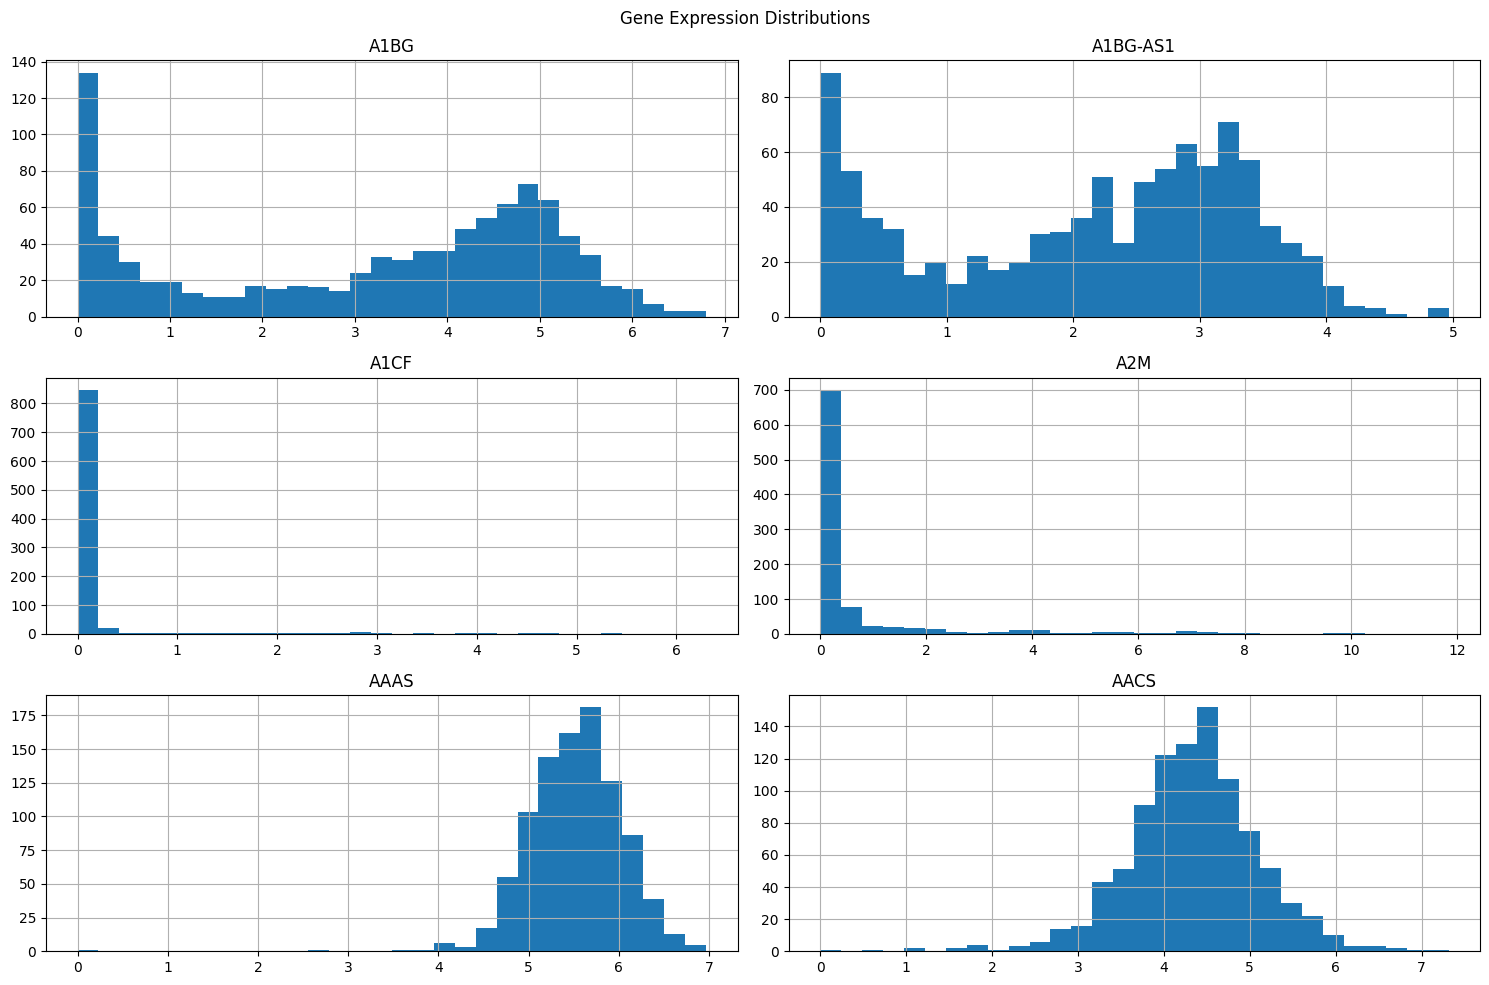

In [ ]:
import matplotlib.pyplot as plt

genes = ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'AAAS', 'AACS']

merged[genes].hist(figsize=(15,10), bins=30)

plt.suptitle("Gene Expression Distributions")
plt.tight_layout()
plt.show()

In [ ]:
merged.iloc[:, -10:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ZYXP1              397 non-null    float64
 1   ZZEF1              944 non-null    float64
 2   ZZZ3               944 non-null    float64
 3   model_name         944 non-null    object 
 4   BROAD_ID           941 non-null    object 
 5   CCLE_ID            941 non-null    object 
 6   COSMIC_ID          944 non-null    object 
 7   cancer_type        944 non-null    object 
 8   tissue             944 non-null    object 
 9   growth_properties  944 non-null    object 
dtypes: float64(3), object(7)
memory usage: 73.9+ KB


In [ ]:
merged=merged.drop(['model_name', 'BROAD_ID', 'CCLE_ID', 'COSMIC_ID'], axis=1)

In [ ]:
merged.iloc[:, -10:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ZYG11A             944 non-null    float64
 1   ZYG11AP1           944 non-null    float64
 2   ZYG11B             944 non-null    float64
 3   ZYX                944 non-null    float64
 4   ZYXP1              397 non-null    float64
 5   ZZEF1              944 non-null    float64
 6   ZZZ3               944 non-null    float64
 7   cancer_type        944 non-null    object 
 8   tissue             944 non-null    object 
 9   growth_properties  944 non-null    object 
dtypes: float64(7), object(3)
memory usage: 73.9+ KB


In [ ]:
merged=merged.drop(['cancer_type', 'tissue', 'growth_properties'], axis=1)

In [ ]:
merged.iloc[:, -20:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ZSWIM5P3    944 non-null    float64
 1   ZSWIM6      944 non-null    float64
 2   ZSWIM7      944 non-null    float64
 3   ZSWIM8      944 non-null    float64
 4   ZSWIM8-AS1  944 non-null    float64
 5   ZSWIM9      944 non-null    float64
 6   ZUP1        944 non-null    float64
 7   ZW10        944 non-null    float64
 8   ZWILCH      944 non-null    float64
 9   ZWINT       944 non-null    float64
 10  ZXDA        944 non-null    float64
 11  ZXDB        944 non-null    float64
 12  ZXDC        944 non-null    float64
 13  ZYG11A      944 non-null    float64
 14  ZYG11AP1    944 non-null    float64
 15  ZYG11B      944 non-null    float64
 16  ZYX         944 non-null    float64
 17  ZYXP1       397 non-null    float64
 18  ZZEF1       944 non-null    float64
 19  ZZZ3        944 non-null    f

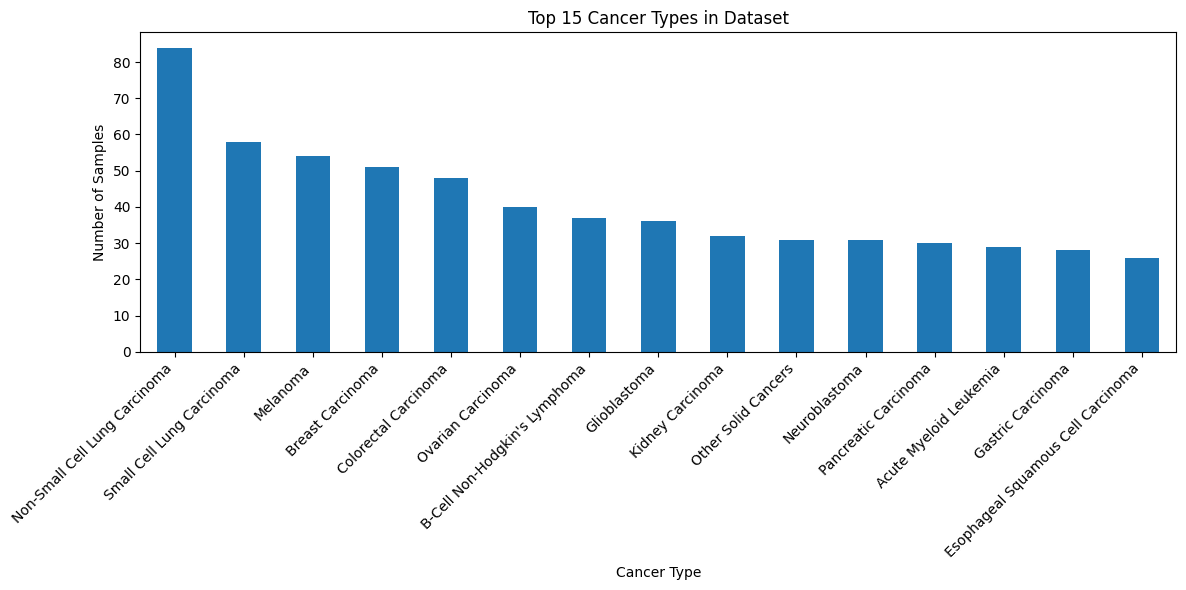

In [ ]:

import matplotlib.pyplot as plt

# Count cancer type frequencies
cancer_counts = merged['CANCER_TYPE'].value_counts()

# Plot top 15 most common cancer types
plt.figure(figsize=(12,6))
cancer_counts.head(15).plot(kind='bar')

plt.title("Top 15 Cancer Types in Dataset")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


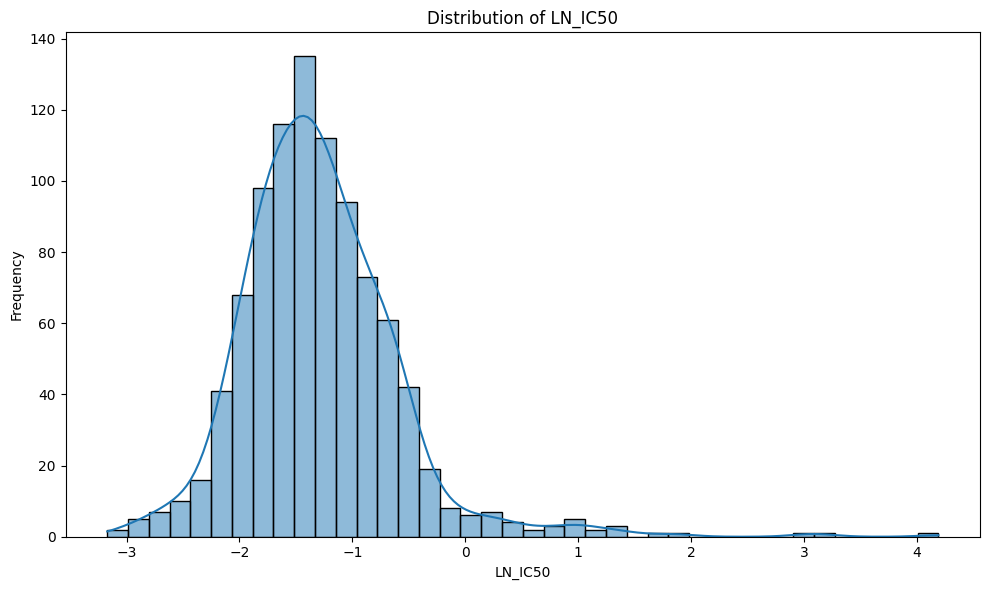

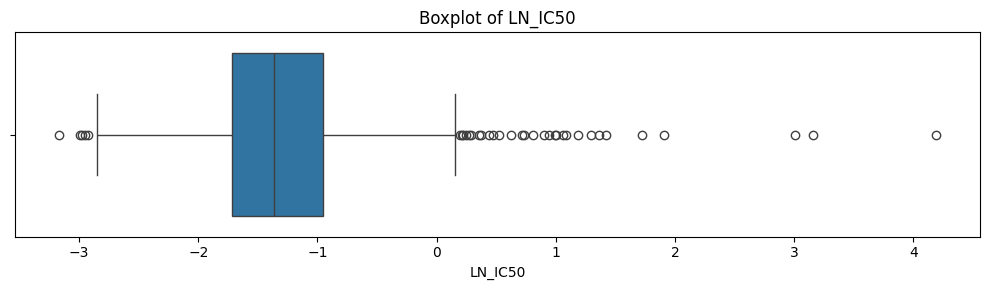

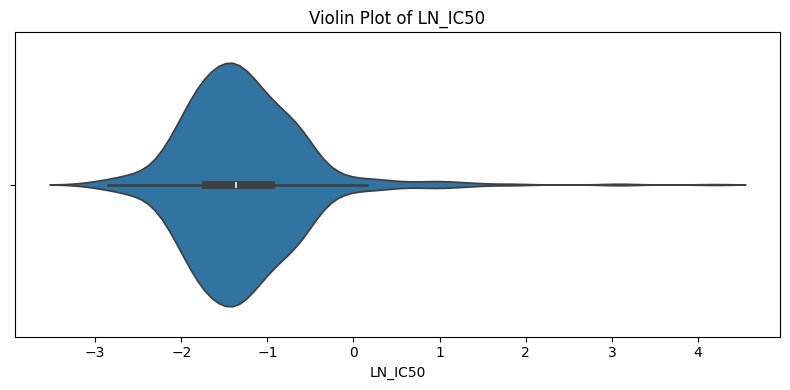

count    944.000000
mean      -1.292212
std        0.702628
min       -3.171575
25%       -1.716079
50%       -1.365895
75%       -0.952397
max        4.192223
Name: LN_IC50, dtype: float64
Skewness: 1.6751700526585949
Kurtosis: 8.26083294090323


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Remove missing values
response_data = merged[response_col].dropna()

# -----------------------------
# 1. Histogram + KDE
# -----------------------------
plt.figure(figsize=(10,6))
sns.histplot(response_data, bins=40, kde=True)

plt.title(f"Distribution of {response_col}")
plt.xlabel(response_col)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Boxplot
# -----------------------------
plt.figure(figsize=(10,3))
sns.boxplot(x=response_data)

plt.title(f"Boxplot of {response_col}")
plt.xlabel(response_col)
plt.tight_layout()
plt.show()


# -----------------------------
# 3. Violin plot
# -----------------------------
plt.figure(figsize=(8,4))
sns.violinplot(x=response_data)

plt.title(f"Violin Plot of {response_col}")
plt.xlabel(response_col)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Log-transformed distribution (if skewed)
# -----------------------------
if (response_data > 0).all():
    plt.figure(figsize=(10,6))
    sns.histplot(np.log1p(response_data), bins=40, kde=True)

    plt.title(f"Log-Transformed Distribution of {response_col}")
    plt.xlabel(f"log(1 + {response_col})")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# -----------------------------
# Summary statistics
# -----------------------------
print(response_data.describe())
print("Skewness:", response_data.skew())
print("Kurtosis:", response_data.kurtosis())

## 4. Build the binary label

In [ ]:
threshold = merged[response_col].median()
print("Median threshold for sensitivity:", threshold)

# 1 = Sensitive (lower LN_IC50), 0 = Resistant
merged["label"] = (merged[response_col] <= threshold).astype(int)

print(merged["label"].value_counts())

Median threshold for sensitivity: -1.365895
label
1    472
0    472
Name: count, dtype: int64


Median threshold for sensitivity: -1.365895
label
1    472
0    472
Name: count, dtype: int64


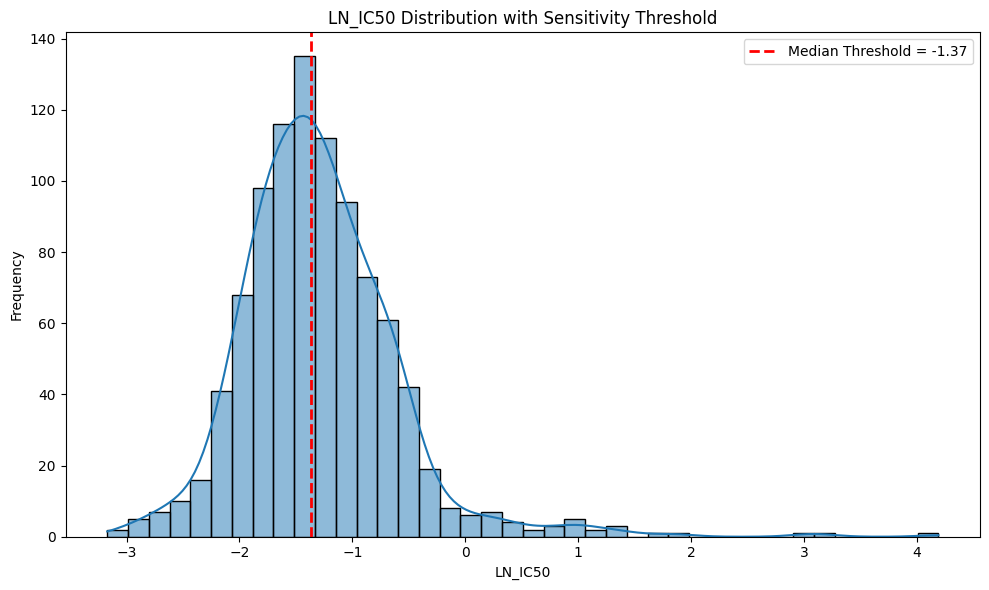

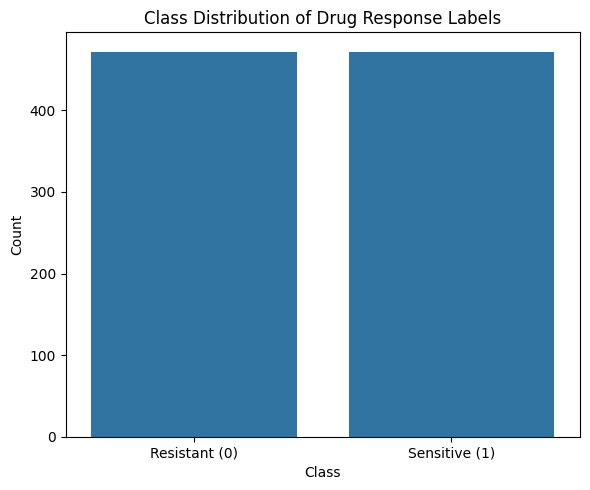

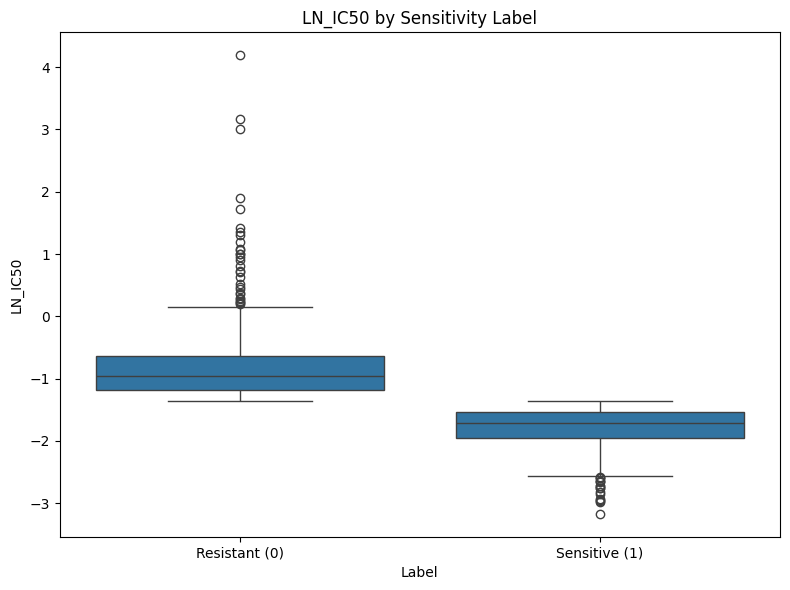

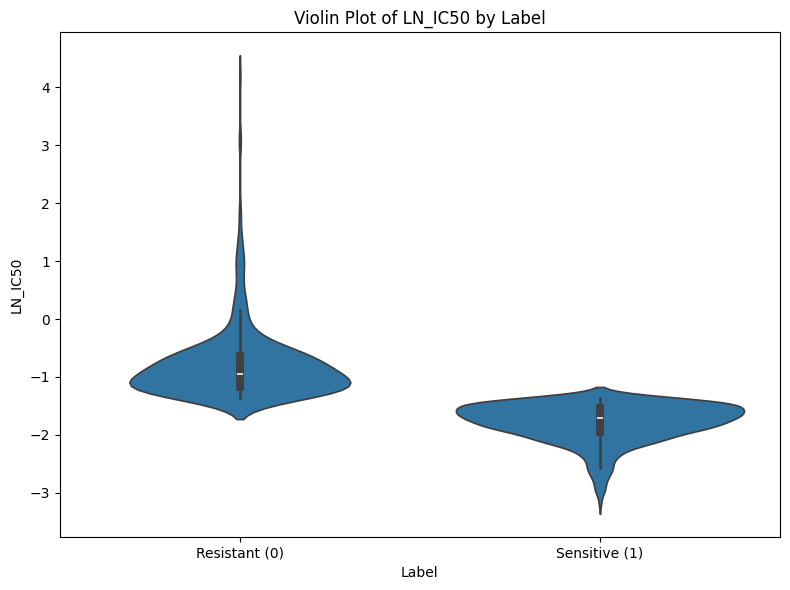

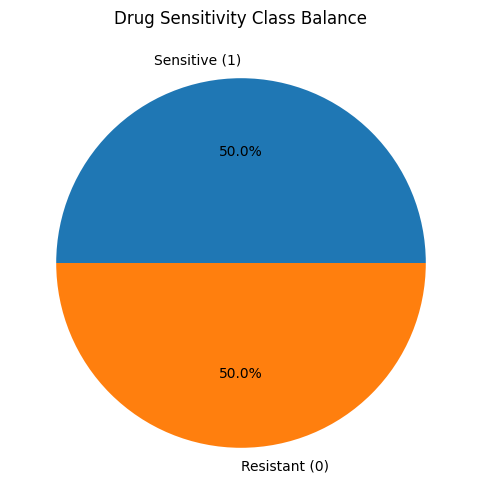

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Calculate threshold and labels
# -----------------------------
threshold = merged[response_col].median()
print("Median threshold for sensitivity:", threshold)

# 1 = Sensitive, 0 = Resistant
merged["label"] = (merged[response_col] <= threshold).astype(int)

print(merged["label"].value_counts())


# -----------------------------
# 1. Response distribution with threshold line
# -----------------------------
plt.figure(figsize=(10,6))
sns.histplot(merged[response_col], bins=40, kde=True)

plt.axvline(
    threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Median Threshold = {threshold:.2f}'
)

plt.title(f"{response_col} Distribution with Sensitivity Threshold")
plt.xlabel(response_col)
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Label count plot
# -----------------------------
plt.figure(figsize=(6,5))
sns.countplot(
    x='label',
    data=merged
)

plt.xticks([0,1], ['Resistant (0)', 'Sensitive (1)'])
plt.title("Class Distribution of Drug Response Labels")
plt.ylabel("Count")
plt.xlabel("Class")
plt.tight_layout()
plt.show()


# -----------------------------
# 3. Boxplot by label
# -----------------------------
plt.figure(figsize=(8,6))
sns.boxplot(
    x='label',
    y=response_col,
    data=merged
)

plt.xticks([0,1], ['Resistant (0)', 'Sensitive (1)'])
plt.title(f"{response_col} by Sensitivity Label")
plt.xlabel("Label")
plt.ylabel(response_col)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Violin plot by label
# -----------------------------
plt.figure(figsize=(8,6))
sns.violinplot(
    x='label',
    y=response_col,
    data=merged
)

plt.xticks([0,1], ['Resistant (0)', 'Sensitive (1)'])
plt.title(f"Violin Plot of {response_col} by Label")
plt.xlabel("Label")
plt.ylabel(response_col)
plt.tight_layout()
plt.show()


# -----------------------------
# 5. Pie chart of class balance
# -----------------------------
label_counts = merged["label"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    label_counts,
    labels=['Sensitive (1)', 'Resistant (0)'] if label_counts.index[0]==1 else ['Resistant (0)', 'Sensitive (1)'],
    autopct='%1.1f%%'
)

plt.title("Drug Sensitivity Class Balance")
plt.show()

In [ ]:
X = merged.drop(columns=["label"])
y = merged["label"]

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Columns: 41147 entries, CANCER_TYPE to ZZZ3
dtypes: float64(41146), object(1)
memory usage: 296.3+ MB


In [ ]:
X.head()

,CANCER_TYPE,LN_IC50,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,ZZZ3
0,Other Solid Cancers,-2.241984,5.1375,3.3840,0.0000,0.6135,0.0000,0.0426,0.0000,0.0,...,0.4751,1.8992,3.7623,0.9928,0.0,2.8258,6.4130,0.0,4.1554,4.0575
1,Ewing's Sarcoma,-1.530673,4.8689,3.4476,0.0000,1.9964,0.1243,3.1890,0.0000,0.0,...,1.6826,2.3306,5.1863,0.0841,0.0,3.0993,5.5242,NaN,3.6064,4.5211
2,Ewing's Sarcoma,-1.779004,5.0365,3.5558,0.0144,3.9855,0.2987,5.7968,0.0566,0.0,...,2.9486,3.3923,6.5963,4.1787,0.0,4.6809,6.3778,0.0,4.5759,5.6946
3,Ewing's Sarcoma,-1.506388,4.5497,3.8001,0.0841,3.2157,0.0566,0.5753,0.0000,0.0,...,2.8298,3.4128,6.7827,2.3190,0.0,4.2141,9.0105,0.0,4.9340,5.4561
4,Ewing's Sarcoma,-1.253027,4.2250,3.2095,0.0144,0.5059,0.0976,2.8156,0.0000,0.0,...,2.4957,3.4764,5.3071,3.0321,0.0,4.4731,6.9529,0.0,4.3590,5.3366


In [ ]:
X=X.drop(['CANCER_TYPE', 'LN_IC50'], axis=1)

In [ ]:
X.head()

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,ZZZ3
0,5.1375,3.3840,0.0000,0.6135,0.0000,0.0426,0.0000,0.0,0.0000,0.0841,...,0.4751,1.8992,3.7623,0.9928,0.0,2.8258,6.4130,0.0,4.1554,4.0575
1,4.8689,3.4476,0.0000,1.9964,0.1243,3.1890,0.0000,0.0,0.0000,0.0841,...,1.6826,2.3306,5.1863,0.0841,0.0,3.0993,5.5242,NaN,3.6064,4.5211
2,5.0365,3.5558,0.0144,3.9855,0.2987,5.7968,0.0566,0.0,0.1375,0.1110,...,2.9486,3.3923,6.5963,4.1787,0.0,4.6809,6.3778,0.0,4.5759,5.6946
3,4.5497,3.8001,0.0841,3.2157,0.0566,0.5753,0.0000,0.0,0.0841,0.1506,...,2.8298,3.4128,6.7827,2.3190,0.0,4.2141,9.0105,0.0,4.9340,5.4561
4,4.2250,3.2095,0.0144,0.5059,0.0976,2.8156,0.0000,0.0,0.0704,0.2141,...,2.4957,3.4764,5.3071,3.0321,0.0,4.4731,6.9529,0.0,4.3590,5.3366


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Feature selection (Variance Threshold)

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)

print("Original:", X_train.shape[1], "Selected:", X_train_var.shape[1])

Original: 41145 Selected: 29250


Mutual Information (SelectKBest)

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# 1. Keep only numeric columns
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

# 2. Remove target/response leakage columns if present
leakage_cols = ["label", "Z_SCORE", response_col]

X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# 3. Remove columns that are completely NaN in training data
valid_cols = X_train_num.columns[X_train_num.notna().any()]

X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# 4. Impute remaining NaNs using median
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train_num)
X_test_imp  = imputer.transform(X_test_num)

# 5. Mutual information feature selection
selector = SelectKBest(score_func=mutual_info_classif, k=20)

X_train_mi = selector.fit_transform(X_train_imp, y_train)
X_test_mi  = selector.transform(X_test_imp)

# 6. Selected feature names
selected_features = X_train_num.columns[selector.get_support()]

print("Original numeric features:", X_train_num.shape[1])
print("Selected:", X_train_mi.shape[1], "features")
print("Selected features:", list(selected_features))

Original numeric features: 41146
Selected: 20 features
Selected features: ['ANKRD20A7P', 'COL4A4', 'DCAF4', 'DENND4A', 'EPHB6', 'FASTKD5', 'IL18', 'LINC00907', 'ODAD4', 'PLCL2', 'RCSD1', 'RN7SKP47', 'RNU6-384P', 'S1PR2', 'SLC2A14', 'SMIM10L2A', 'SNRPCP15', 'TXLNGY', 'UBE2CP4', 'ZNF80']


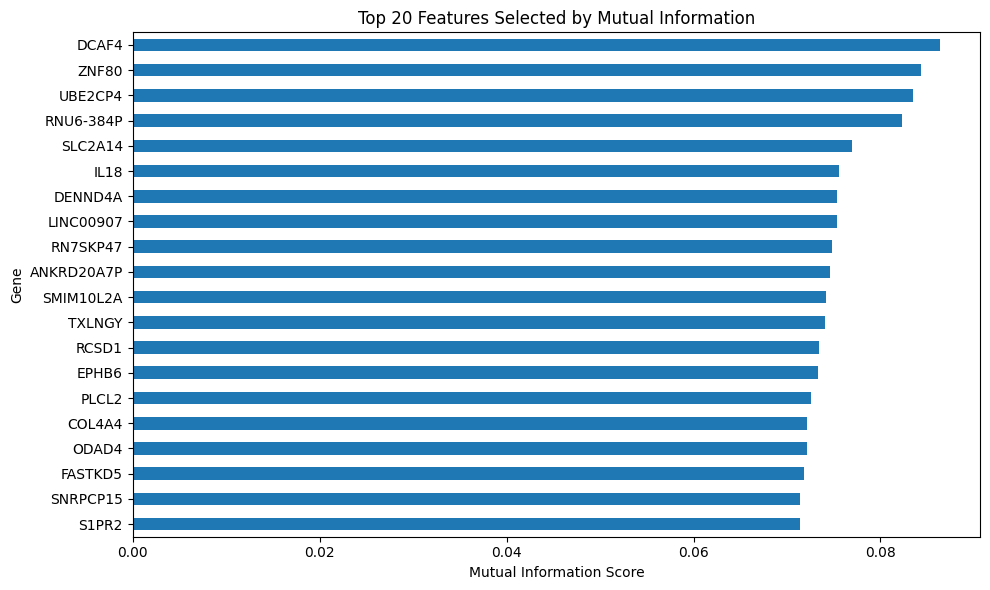

In [ ]:
# Mutual Information scores for selected top 10 genes
top_features = list(selected_features)

mi_scores = pd.Series(
    selector.scores_,
    index=X_train_num.columns
)

top_scores = mi_scores[top_features].sort_values()

# Simple bar plot
plt.figure(figsize=(10,6))
top_scores.plot(kind='barh')

plt.title("Top 20 Features Selected by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_ind
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

def ttest_feature_ranking(X, y):

    # Keep only numeric columns
    X_num = X.select_dtypes(include=[np.number]).copy()

    # Remove leakage columns if present
    X_num = X_num.drop(
        columns=["label", "Z_SCORE", response_col],
        errors="ignore"
    )

    # Remove duplicated column names
    X_num = X_num.loc[:, ~X_num.columns.duplicated()]

    # Remove all-NaN columns
    X_num = X_num.loc[:, X_num.notna().any()]

    # Impute missing values
    imputer = SimpleImputer(strategy="median")
    X_imp = pd.DataFrame(
        imputer.fit_transform(X_num),
        columns=X_num.columns,
        index=X_num.index
    )

    # Make sure y aligns with X
    y_aligned = pd.Series(y, index=X_imp.index)

    # Split classes
    X0 = X_imp[y_aligned == 0]
    X1 = X_imp[y_aligned == 1]

    # Vectorized t-test across all genes
    t_stat, p_val = ttest_ind(
        X0.values,
        X1.values,
        axis=0,
        equal_var=False,
        nan_policy="omit"
    )

    # Create result table
    results = pd.DataFrame({
        "feature": X_imp.columns,
        "t_stat": t_stat,
        "abs_t_stat": np.abs(t_stat),
        "p_value": p_val
    })

    results = results.replace([np.inf, -np.inf], np.nan)
    results = results.dropna(subset=["abs_t_stat"])

    results = results.sort_values(
        by="abs_t_stat",
        ascending=False
    ).reset_index(drop=True)

    return results


# Run t-test ranking
ttest_results = ttest_feature_ranking(X_train, y_train)

print("Top 10 features by |t|:")
print(ttest_results.head(20))

# Select top-k features
k = 20
selected_features_ttest = ttest_results["feature"].head(k).tolist()

print("\nNumber of selected features:", len(selected_features_ttest))
print("Selected features:", selected_features_ttest)

# Reduce dataset
X_train_ttest = X_train[selected_features_ttest]
X_test_ttest  = X_test[selected_features_ttest]

Top 10 features by |t|:
     feature    t_stat  abs_t_stat       p_value
0     KBTBD8 -7.225177    7.225177  1.543022e-12
1      IL21R -7.162603    7.162603  2.852730e-12
2       PIM2 -7.105237    7.105237  3.998633e-12
3    IL12RB1 -7.094077    7.094077  4.230596e-12
4       TSKU  7.024491    7.024491  5.415987e-12
5     CUEDC1  6.880069    6.880069  1.502138e-11
6   FAM177A1  6.876774    6.876774  1.437974e-11
7    TMEM45B  6.818105    6.818105  2.282902e-11
8      MYO5C  6.791320    6.791320  2.513616e-11
9      CYTIP -6.696403    6.696403  5.949626e-11
10      DDR1  6.685501    6.685501  5.047931e-11
11     KRT19  6.642540    6.642540  6.503613e-11
12     NHSL3  6.616418    6.616418  7.802779e-11
13    MAP4K1 -6.493183    6.493183  1.851631e-10
14   TSPAN15  6.478952    6.478952  1.810223e-10
15  TMEM184A  6.450794    6.450794  2.163720e-10
16   PLEKHG3  6.442859    6.442859  2.358051e-10
17      FA2H  6.420757    6.420757  2.715479e-10
18  ARHGEF16  6.371939    6.371939  3.520030e

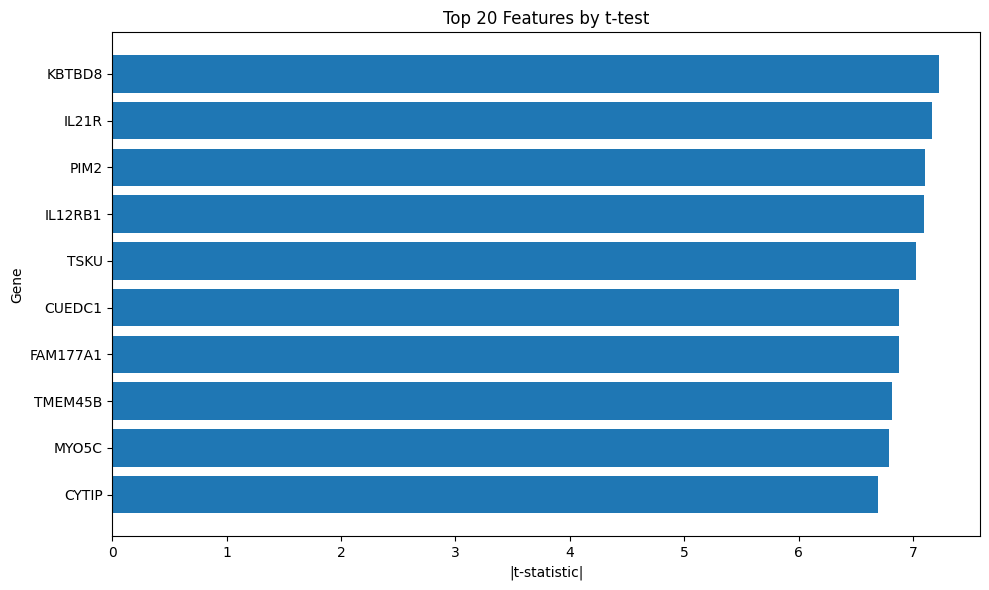

In [ ]:
import matplotlib.pyplot as plt

top10 = ttest_results.head(10).sort_values("abs_t_stat")

plt.figure(figsize=(10,6))
plt.barh(top10["feature"], top10["abs_t_stat"])
plt.title("Top 20 Features by t-test")
plt.xlabel("|t-statistic|")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

Original numeric features: 41143
Number of selected features: 10
Selected features: ['CD48', 'CD53', 'IKZF1', 'IL12RB1', 'IL21R', 'MIR142HG', 'PTPN7', 'PTPRC', 'SLAMF6', 'TMEM45B']


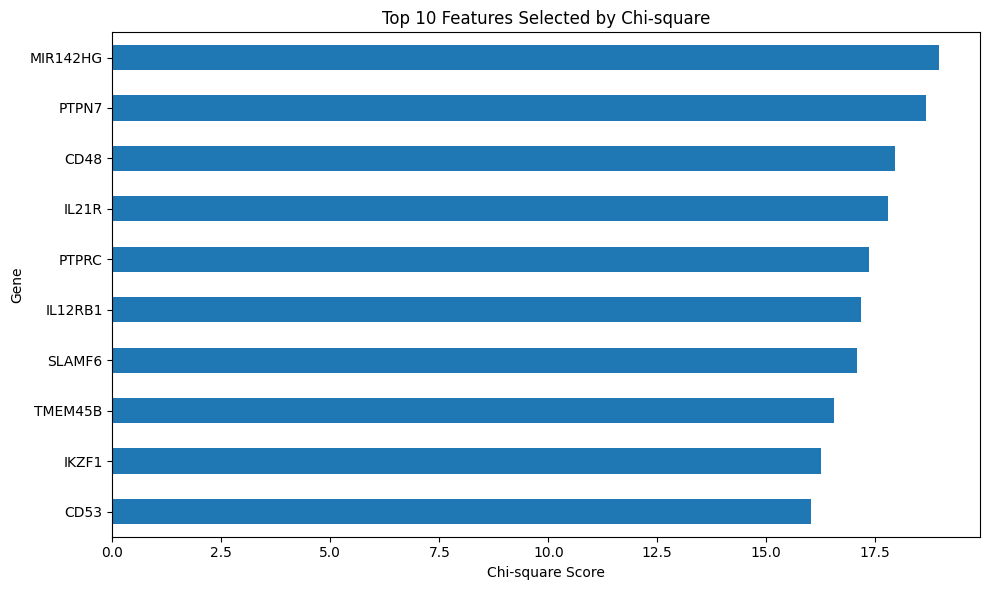

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Keep numeric columns only
X_train_num = X_train.select_dtypes(include=[np.number]).copy()
X_test_num  = X_test.select_dtypes(include=[np.number]).copy()

# 2. Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]

X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# 3. Remove duplicated columns
X_train_num = X_train_num.loc[:, ~X_train_num.columns.duplicated()]
X_test_num  = X_test_num.loc[:, ~X_test_num.columns.duplicated()]

# 4. Keep only common columns, same order as training
common_cols = X_train_num.columns.intersection(X_test_num.columns)

X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

# 5. Remove all-NaN columns based on training set
valid_cols = X_train_num.columns[X_train_num.notna().any()]

X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# 6. Impute missing values
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train_num)
X_test_imp  = imputer.transform(X_test_num)

# 7. Scale to nonnegative values for chi-square
scaler_chi2 = MinMaxScaler()

X_train_chi2_scaled = scaler_chi2.fit_transform(X_train_imp)
X_test_chi2_scaled  = scaler_chi2.transform(X_test_imp)

# 8. Select top-k features
k = 10
chi2_selector = SelectKBest(score_func=chi2, k=k)

X_train_chi2 = chi2_selector.fit_transform(X_train_chi2_scaled, y_train)
X_test_chi2  = chi2_selector.transform(X_test_chi2_scaled)

# 9. Selected feature names
selected_features_chi2 = X_train_num.columns[chi2_selector.get_support()]

print("Original numeric features:", X_train_num.shape[1])
print("Number of selected features:", len(selected_features_chi2))
print("Selected features:", list(selected_features_chi2))

# 10. Simple visualization
chi2_scores = pd.Series(
    chi2_selector.scores_,
    index=X_train_num.columns
).sort_values(ascending=False)

top10_chi2 = chi2_scores.head(10).sort_values()

plt.figure(figsize=(10,6))
top10_chi2.plot(kind="barh")

plt.title("Top 10 Features Selected by Chi-square")
plt.xlabel("Chi-square Score")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

## 5. Supervised Learning

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
def evaluate_model(X_train, X_test, y_train, y_test):

    model = LogisticRegression(max_iter=5000)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    # ---------------- ROC Curve ----------------
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # ---------------- PR Curve ----------------
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap='Blues')

    plt.title("Confusion Matrix")
    plt.show()

    return acc, prec, rec, roc_auc, pr_auc, cm

Original: 41146
Selected: 29165


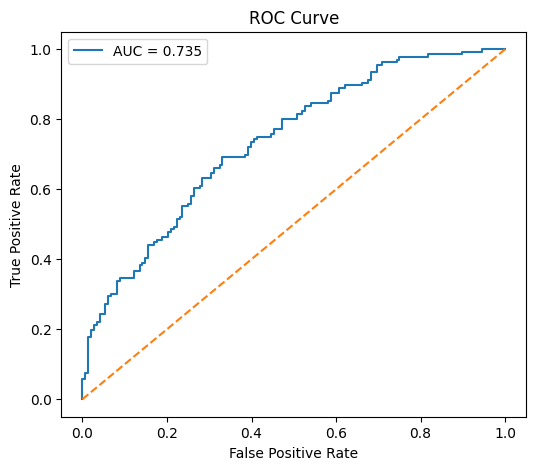

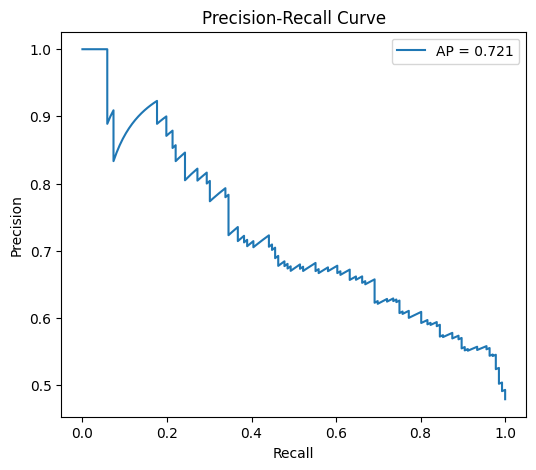

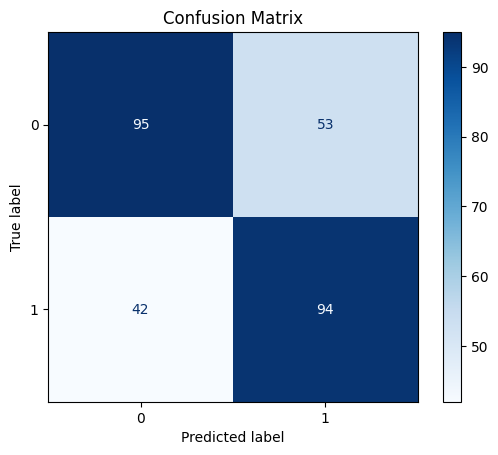

Accuracy: 0.6654929577464789
Precision: 0.6394557823129252
Recall: 0.6911764705882353
ROC-AUC: 0.7349463434022258
PR-AUC: 0.7209488705551641
Confusion Matrix:
[[95 53]
 [42 94]]


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
import numpy as np

# Numeric-only features
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]
X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Keep same columns
common_cols = X_train_num.columns.intersection(X_test_num.columns)
X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

# Remove all-NaN columns
valid_cols = X_train_num.columns[X_train_num.notna().any()]
X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# Impute missing values
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_num)
X_test_imp  = imputer.transform(X_test_num)

# Variance Threshold
selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train_imp)
X_test_var  = selector.transform(X_test_imp)

print("Original:", X_train_num.shape[1])
print("Selected:", X_train_var.shape[1])

# Evaluate model
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_var, X_test_var, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Confusion Matrix:")
print(cm)

Top 10 features by |t|:
    feature    t_stat  abs_t_stat       p_value
0    KBTBD8 -7.225177    7.225177  1.543022e-12
1     IL21R -7.162603    7.162603  2.852730e-12
2      PIM2 -7.105237    7.105237  3.998633e-12
3   IL12RB1 -7.094077    7.094077  4.230596e-12
4      TSKU  7.024491    7.024491  5.415987e-12
5    CUEDC1  6.880069    6.880069  1.502138e-11
6  FAM177A1  6.876774    6.876774  1.437974e-11
7   TMEM45B  6.818105    6.818105  2.282902e-11
8     MYO5C  6.791320    6.791320  2.513616e-11
9     CYTIP -6.696403    6.696403  5.949626e-11
Selected: 10 features
Selected features: ['KBTBD8', 'IL21R', 'PIM2', 'IL12RB1', 'TSKU', 'CUEDC1', 'FAM177A1', 'TMEM45B', 'MYO5C', 'CYTIP']


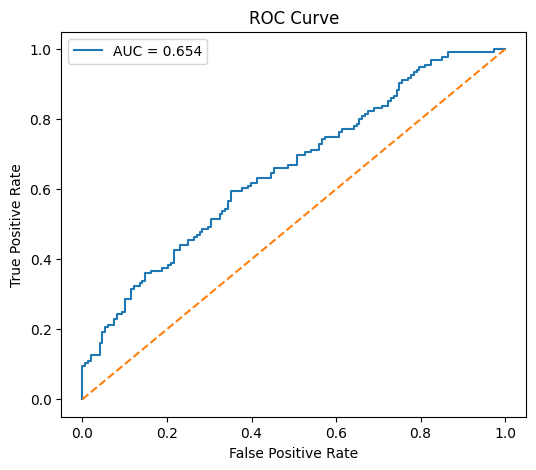

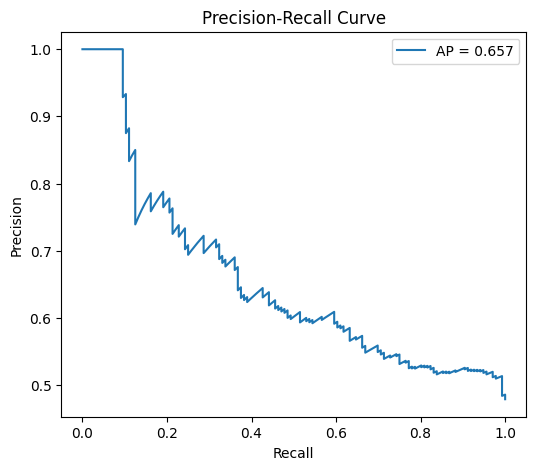

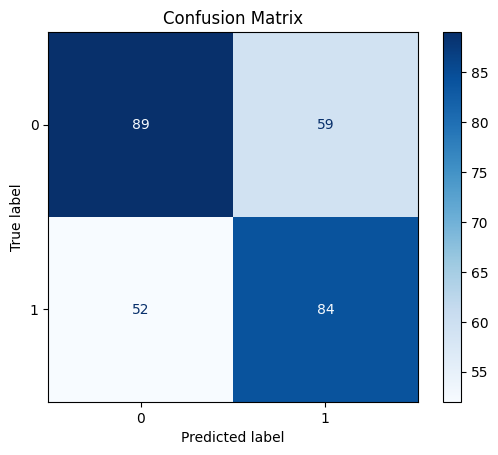

Accuracy: 0.6091549295774648
Precision: 0.5874125874125874
Recall: 0.6176470588235294
ROC-AUC: 0.6538155802861685
PR-AUC: 0.6566105884821598
Confusion Matrix:
[[89 59]
 [52 84]]


In [ ]:
from scipy.stats import ttest_ind
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# -----------------------------
# 1. Prepare numeric-only data
# -----------------------------
X_train_num = X_train.select_dtypes(include=[np.number]).copy()
X_test_num  = X_test.select_dtypes(include=[np.number]).copy()

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]
X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Remove duplicate columns
X_train_num = X_train_num.loc[:, ~X_train_num.columns.duplicated()]
X_test_num  = X_test_num.loc[:, ~X_test_num.columns.duplicated()]

# Keep same columns in same order
common_cols = X_train_num.columns.intersection(X_test_num.columns)
X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

# Remove all-NaN columns
valid_cols = X_train_num.columns[X_train_num.notna().any()]
X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# -----------------------------
# 2. Impute missing values
# -----------------------------
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train_num.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test_num.index
)

# -----------------------------
# 3. t-test feature ranking
# -----------------------------
y_train_aligned = pd.Series(y_train, index=X_train_imp.index)

X0 = X_train_imp[y_train_aligned == 0]
X1 = X_train_imp[y_train_aligned == 1]

t_stat, p_val = ttest_ind(
    X0.values,
    X1.values,
    axis=0,
    equal_var=False,
    nan_policy="omit"
)

ttest_results = pd.DataFrame({
    "feature": X_train_imp.columns,
    "t_stat": t_stat,
    "abs_t_stat": np.abs(t_stat),
    "p_value": p_val
})

ttest_results = (
    ttest_results
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["abs_t_stat"])
    .sort_values("abs_t_stat", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 features by |t|:")
print(ttest_results.head(10))

# -----------------------------
# 4. Select top-k features
# -----------------------------
k = 10
selected_features_ttest = ttest_results["feature"].head(k).tolist()

X_train_ttest = X_train_imp[selected_features_ttest]
X_test_ttest  = X_test_imp[selected_features_ttest]

print("Selected:", X_train_ttest.shape[1], "features")
print("Selected features:", selected_features_ttest)

# -----------------------------
# 5. Evaluate model
# -----------------------------
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_ttest, X_test_ttest, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Confusion Matrix:")
print(cm)

Selected: 20 features
Selected features: ['CAMK2N1', 'CEACAM7', 'DCAF4', 'DENND4A', 'HGFAC', 'HNRNPCL3', 'ICAM2', 'LAX1', 'LINC02018', 'LRRC10', 'MIR194-2HG', 'OR7E53P', 'RNU4-50P', 'RNU6-717P', 'RPL7P18', 'RPS3AP54', 'S1PR2', 'TACC2', 'TJP1', 'VDAC2P2']

Top 10 features by Mutual Information:
     feature  mi_score
0     LRRC10  0.083887
1      DCAF4  0.083248
2       LAX1  0.082176
3    OR7E53P  0.080004
4  LINC02018  0.079795
5    RPL7P18  0.076126
6      ICAM2  0.073563
7    VDAC2P2  0.072744
8   RNU4-50P  0.072609
9      S1PR2  0.072430


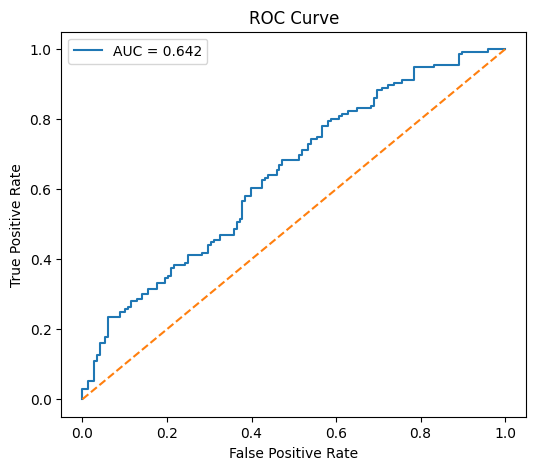

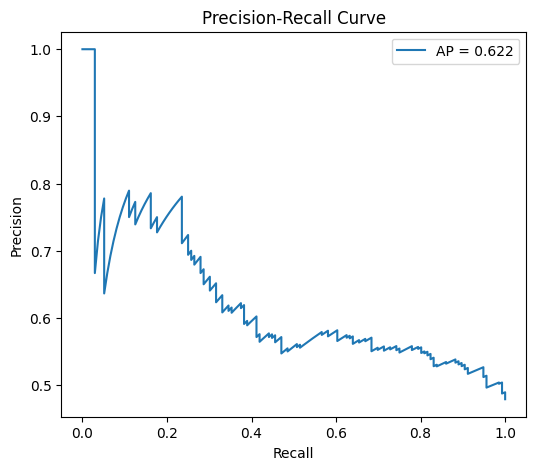

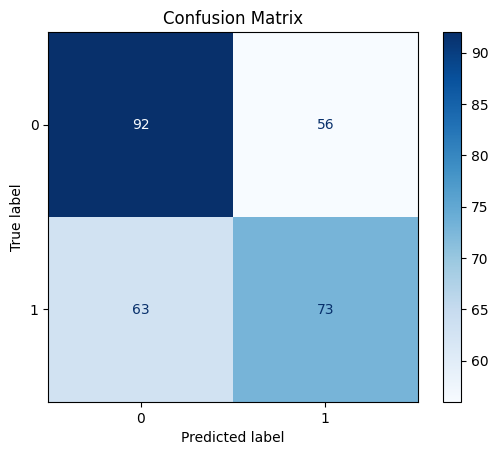

Accuracy: 0.5809859154929577
Precision: 0.5658914728682171
Recall: 0.5367647058823529
ROC-AUC: 0.642239666136725
PR-AUC: 0.6224456801232043
Confusion Matrix:
[[92 56]
 [63 73]]


In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# -----------------------------
# 1. Prepare numeric-only data
# -----------------------------
X_train_num = X_train.select_dtypes(include=[np.number]).copy()
X_test_num  = X_test.select_dtypes(include=[np.number]).copy()

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]
X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Remove duplicate columns
X_train_num = X_train_num.loc[:, ~X_train_num.columns.duplicated()]
X_test_num  = X_test_num.loc[:, ~X_test_num.columns.duplicated()]

# Keep same columns in same order
common_cols = X_train_num.columns.intersection(X_test_num.columns)
X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

# Remove all-NaN columns
valid_cols = X_train_num.columns[X_train_num.notna().any()]
X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# -----------------------------
# 2. Impute missing values
# -----------------------------
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train_num.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test_num.index
)

# -----------------------------
# 3. Mutual Information feature selection
# -----------------------------
k = 20

mi_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=k
)

X_train_mi = mi_selector.fit_transform(X_train_imp, y_train)
X_test_mi  = mi_selector.transform(X_test_imp)

selected_features_mi = X_train_imp.columns[mi_selector.get_support()].tolist()

print("Selected:", X_train_mi.shape[1], "features")
print("Selected features:", selected_features_mi)

# -----------------------------
# 4. Mutual information score table
# -----------------------------
mi_results = pd.DataFrame({
    "feature": X_train_imp.columns,
    "mi_score": mi_selector.scores_
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

print("\nTop 10 features by Mutual Information:")
print(mi_results.head(10))

# -----------------------------
# 5. Evaluate model
# -----------------------------
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_mi, X_test_mi, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Confusion Matrix:")
print(cm)

Selected: 20 features
Selected features: ['BIN2', 'CD48', 'CD53', 'CD86', 'CEACAM6', 'CYTIP', 'IKZF1', 'IL12RB1', 'IL21R', 'KLHL6', 'MIR142HG', 'NUGGC', 'P2RY8', 'PTPN7', 'PTPRC', 'RASAL3', 'SLAMF6', 'SPN', 'TESPA1', 'TMEM45B']

Top 10 features by Chi-square:
    feature  chi2_score   p_value
0  MIR142HG   18.954906  0.000013
1     PTPN7   18.658849  0.000016
2      CD48   17.957853  0.000023
3     IL21R   17.800927  0.000025
4     PTPRC   17.352420  0.000031
5   IL12RB1   17.166455  0.000034
6    SLAMF6   17.083991  0.000036
7   TMEM45B   16.544513  0.000048
8     IKZF1   16.247594  0.000056
9      CD53   16.030636  0.000062


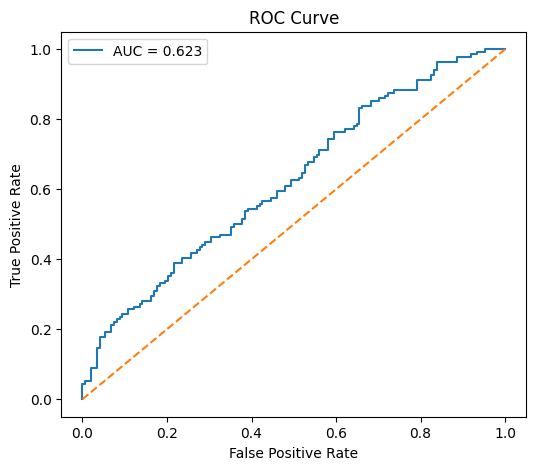

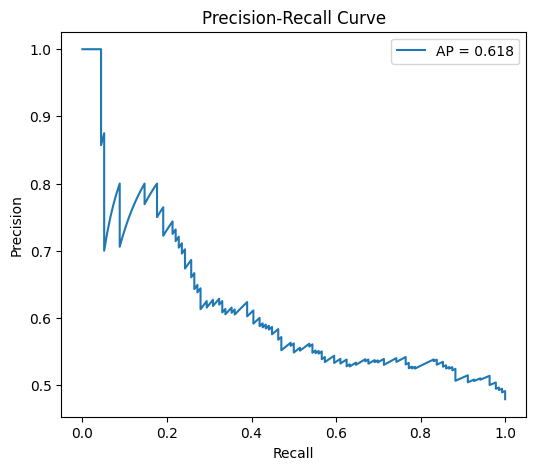

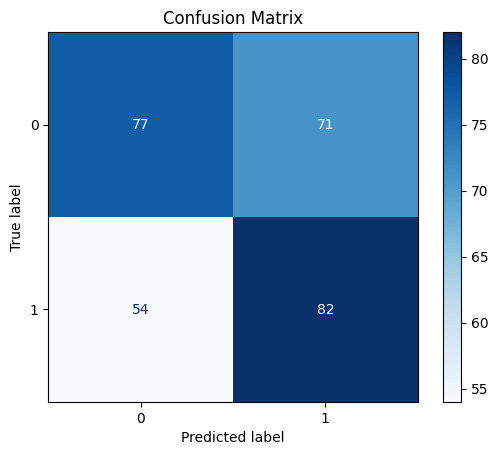

Accuracy: 0.5598591549295775
Precision: 0.5359477124183006
Recall: 0.6029411764705882
ROC-AUC: 0.6226649443561207
PR-AUC: 0.6178315939387049
Confusion Matrix:
[[77 71]
 [54 82]]


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# -----------------------------
# 1. Prepare numeric-only data
# -----------------------------
X_train_num = X_train.select_dtypes(include=[np.number]).copy()
X_test_num  = X_test.select_dtypes(include=[np.number]).copy()

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]
X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Remove duplicate columns
X_train_num = X_train_num.loc[:, ~X_train_num.columns.duplicated()]
X_test_num  = X_test_num.loc[:, ~X_test_num.columns.duplicated()]

# Keep same columns in same order
common_cols = X_train_num.columns.intersection(X_test_num.columns)
X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

# Remove all-NaN columns
valid_cols = X_train_num.columns[X_train_num.notna().any()]
X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# -----------------------------
# 2. Impute missing values
# -----------------------------
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train_num.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test_num.index
)

# -----------------------------
# 3. Scale features to nonnegative values
# Chi-square requires nonnegative input
# -----------------------------
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# -----------------------------
# 4. Chi-square feature selection
# -----------------------------
k = 20

chi2_selector = SelectKBest(
    score_func=chi2,
    k=k
)

X_train_chi2 = chi2_selector.fit_transform(X_train_scaled, y_train)
X_test_chi2  = chi2_selector.transform(X_test_scaled)

selected_features_chi2 = X_train_imp.columns[
    chi2_selector.get_support()
].tolist()

print("Selected:", X_train_chi2.shape[1], "features")
print("Selected features:", selected_features_chi2)

# -----------------------------
# 5. Chi-square score table
# -----------------------------
chi2_results = pd.DataFrame({
    "feature": X_train_imp.columns,
    "chi2_score": chi2_selector.scores_,
    "p_value": chi2_selector.pvalues_
}).sort_values("chi2_score", ascending=False).reset_index(drop=True)

print("\nTop 10 features by Chi-square:")
print(chi2_results.head(10))

# -----------------------------
# 6. Evaluate model
# -----------------------------
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_chi2, X_test_chi2, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Confusion Matrix:")
print(cm)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
def evaluate_model(X_train, X_test, y_train, y_test):

    model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
      )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    # ---------------- ROC Curve ----------------
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # ---------------- PR Curve ----------------
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap='Blues')

    plt.title("Confusion Matrix")
    plt.show()

    return acc, prec, rec, roc_auc, pr_auc, cm

Original: 41146
Selected: 29165


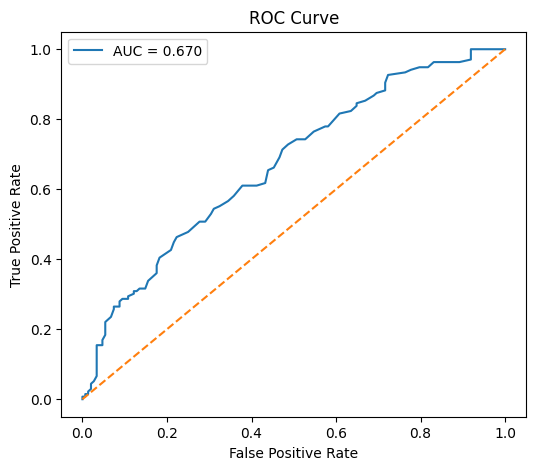

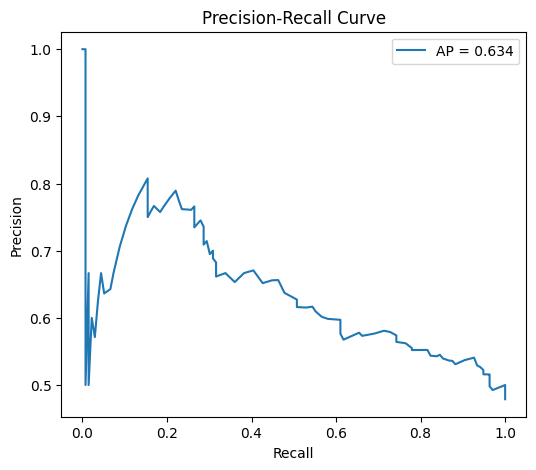

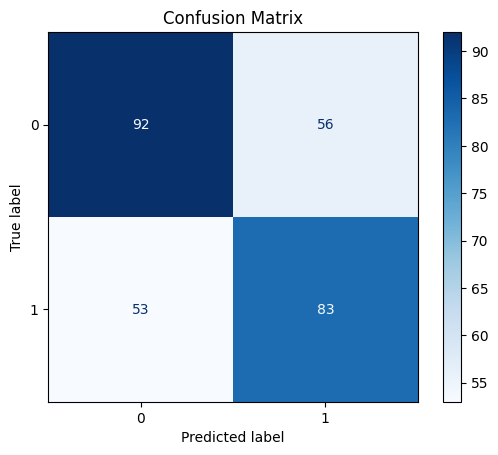

Accuracy: 0.6161971830985915
Precision: 0.5971223021582733
Recall: 0.6102941176470589
ROC-AUC: 0.6704093799682035
PR-AUC: 0.6341892422690643
Confusion Matrix:
[[92 56]
 [53 83]]


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
import numpy as np

# Numeric-only features
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]
X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Keep same columns
common_cols = X_train_num.columns.intersection(X_test_num.columns)
X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

# Remove all-NaN columns
valid_cols = X_train_num.columns[X_train_num.notna().any()]
X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# Impute missing values
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_num)
X_test_imp  = imputer.transform(X_test_num)

# Variance Threshold
selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train_imp)
X_test_var  = selector.transform(X_test_imp)

print("Original:", X_train_num.shape[1])
print("Selected:", X_train_var.shape[1])

# Evaluate model
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_var, X_test_var, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Confusion Matrix:")
print(cm)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
def evaluate_model(X_train, X_test, y_train, y_test):

    model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
      )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    # ---------------- ROC Curve ----------------
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # ---------------- PR Curve ----------------
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap='Blues')

    plt.title("Confusion Matrix")
    plt.show()

    return acc, prec, rec, roc_auc, pr_auc, cm

Original: 41146
Selected: 29165


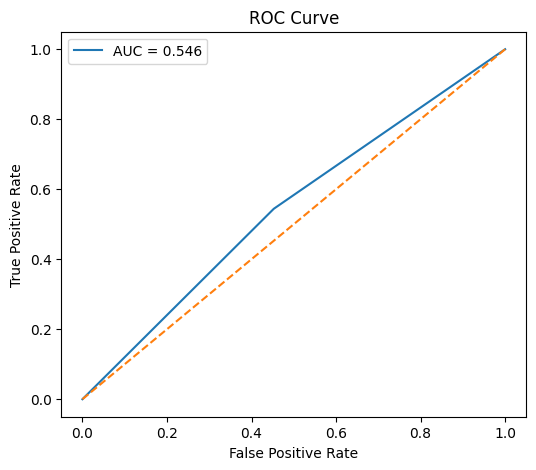

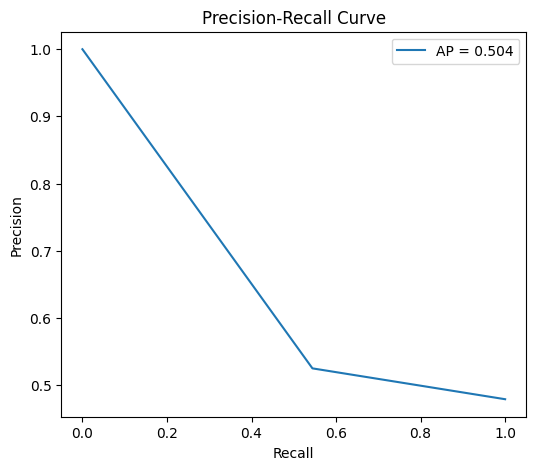

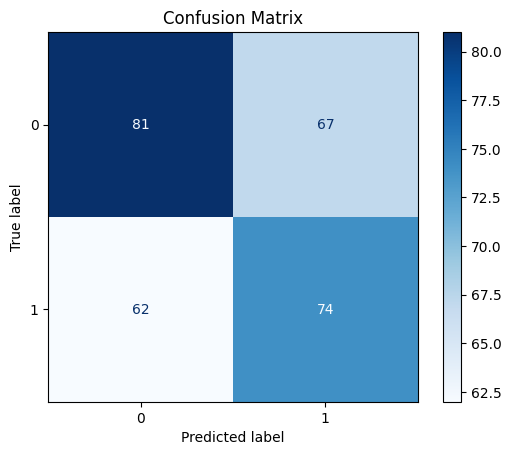

Accuracy: 0.545774647887324
Precision: 0.524822695035461
Recall: 0.5441176470588235
ROC-AUC: 0.5457074721780604
PR-AUC: 0.5038751491006951
Confusion Matrix:
[[81 67]
 [62 74]]


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
import numpy as np

# Numeric-only features
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]
X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Keep same columns
common_cols = X_train_num.columns.intersection(X_test_num.columns)
X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

# Remove all-NaN columns
valid_cols = X_train_num.columns[X_train_num.notna().any()]
X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# Impute missing values
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_num)
X_test_imp  = imputer.transform(X_test_num)

# Variance Threshold
selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train_imp)
X_test_var  = selector.transform(X_test_imp)

print("Original:", X_train_num.shape[1])
print("Selected:", X_train_var.shape[1])

# Evaluate model
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_var, X_test_var, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Confusion Matrix:")
print(cm)

In [ ]:
from sklearn.svm import SVC
def evaluate_model(X_train, X_test, y_train, y_test):

    model = SVC(
    random_state=42,
    class_weight="balanced"
      )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    # ---------------- ROC Curve ----------------
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # ---------------- PR Curve ----------------
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap='Blues')

    plt.title("Confusion Matrix")
    plt.show()

    return acc, prec, rec, roc_auc, pr_auc, cm

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def evaluate_model(X_train, X_test, y_train, y_test):

    # -----------------------------
    # Support Vector Machine model
    # -----------------------------
    model = SVC(
        kernel='rbf',
        probability=True,          # IMPORTANT FIX
        random_state=42,
        class_weight="balanced"
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # Probability scores
    prob = model.predict_proba(X_test)[:, 1]

    # -----------------------------
    # Metrics
    # -----------------------------
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    # ---------------- ROC Curve ----------------
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------- PR Curve ----------------
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, roc_auc, pr_auc, cm

Original: 41146
Selected: 29165


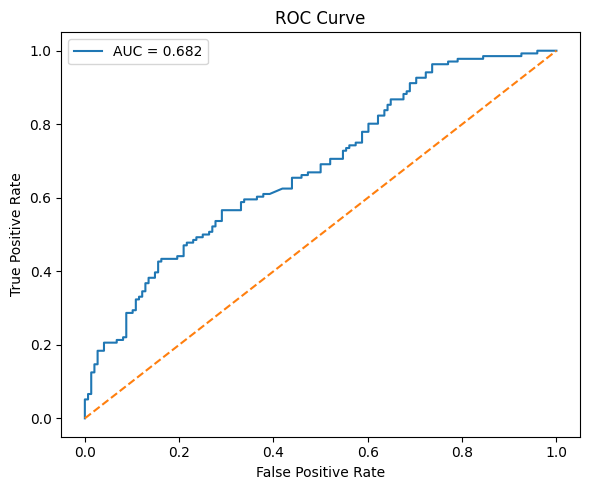

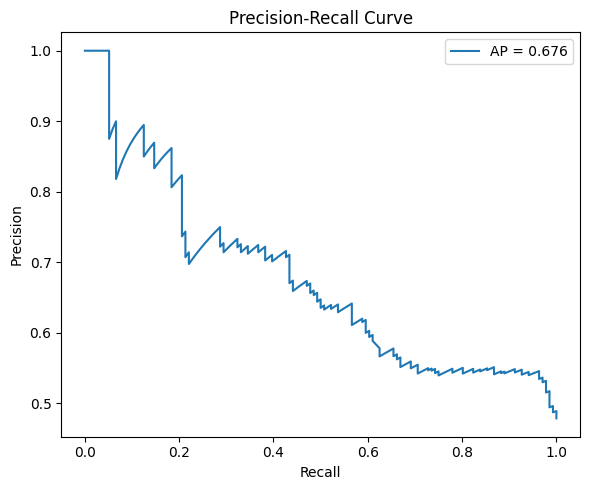

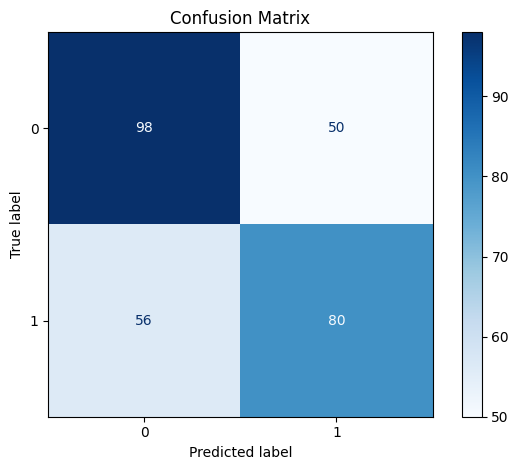

Accuracy: 0.6267605633802817
Precision: 0.6153846153846154
Recall: 0.5882352941176471
ROC-AUC: 0.6818859300476948
PR-AUC: 0.6756097528771065
Confusion Matrix:
[[98 50]
 [56 80]]


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
import numpy as np

# Numeric-only features
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]
X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Keep same columns
common_cols = X_train_num.columns.intersection(X_test_num.columns)
X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

# Remove all-NaN columns
valid_cols = X_train_num.columns[X_train_num.notna().any()]
X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# Impute missing values
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_num)
X_test_imp  = imputer.transform(X_test_num)

# Variance Threshold
selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train_imp)
X_test_var  = selector.transform(X_test_imp)

print("Original:", X_train_num.shape[1])
print("Selected:", X_train_var.shape[1])

# Evaluate model
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_var, X_test_var, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Confusion Matrix:")
print(cm)

Training shape before selection: (660, 41145)
Testing shape before selection: (284, 41145)

========== Testing C = 0.01 ==========
CV ROC-AUC: 0.6466 ± 0.0512

========== Testing C = 0.1 ==========
CV ROC-AUC: 0.6466 ± 0.0512

========== Testing C = 1 ==========
CV ROC-AUC: 0.6831 ± 0.0339

Best C: 1
Best CV ROC-AUC: 0.683119734331735

Test Performance
Accuracy : 0.6161971830985915
Precision: 0.6
Recall   : 0.5955882352941176
F1-score : 0.5977859778597786
ROC-AUC  : 0.6792527821939587
PR-AUC   : 0.6308149695763179

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.64      0.63       148
           1       0.60      0.60      0.60       136

    accuracy                           0.62       284
   macro avg       0.62      0.62      0.62       284
weighted avg       0.62      0.62      0.62       284


Hyperparameter Tuning Summary:
      C  Mean ROC-AUC  Std ROC-AUC
0  0.01      0.646551     0.051240
1  0.10      0.646551     0

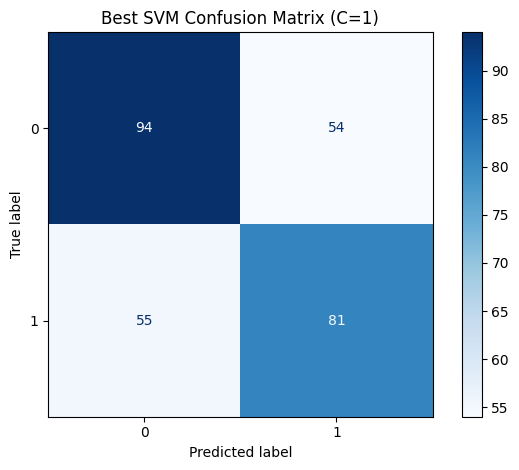

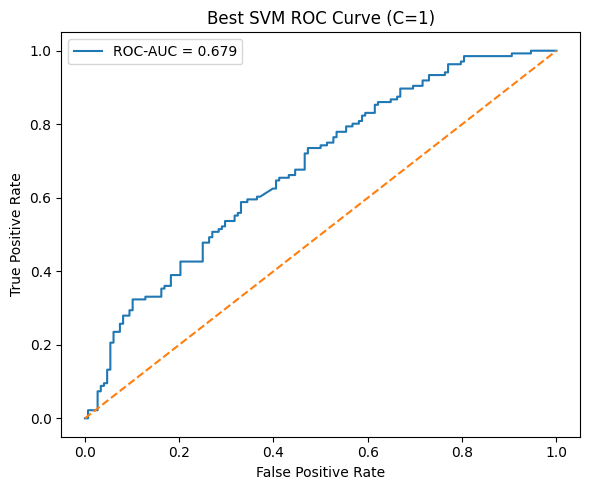

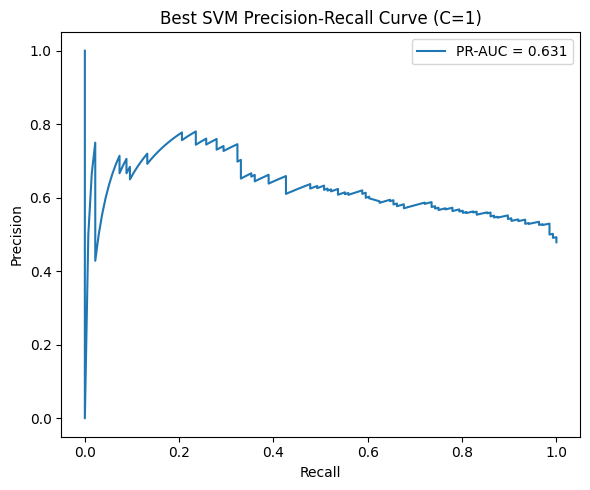

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)

# -----------------------------
# 1. Prepare numeric features
# -----------------------------
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]

X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Keep common columns only
common_cols = X_train_num.columns.intersection(X_test_num.columns)

X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

print("Training shape before selection:", X_train_num.shape)
print("Testing shape before selection:", X_test_num.shape)

# -----------------------------
# 2. Cross-validation setup
# -----------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -----------------------------
# 3. Tune only C manually
# -----------------------------
C_values = [0.01, 0.1, 1]

best_score = -np.inf
best_C = None
best_model = None

results = []

for C_val in C_values:

    print(f"\n========== Testing C = {C_val} ==========")

    svm_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            gamma="scale",
            C=C_val,
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])

    # Cross-validation ROC-AUC
    cv_scores = cross_val_score(
        svm_pipeline,
        X_train_num,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)

    print(f"CV ROC-AUC: {mean_score:.4f} ± {std_score:.4f}")

    results.append({
        "C": C_val,
        "Mean ROC-AUC": mean_score,
        "Std ROC-AUC": std_score
    })

    # Track best model
    if mean_score > best_score:
        best_score = mean_score
        best_C = C_val
        best_model = svm_pipeline

# -----------------------------
# 4. Final best parameter
# -----------------------------
print("\n====================================")
print("Best C:", best_C)
print("Best CV ROC-AUC:", best_score)
print("====================================")

# -----------------------------
# 5. Train best model on full training data
# -----------------------------
best_model.fit(X_train_num, y_train)

# -----------------------------
# 6. Evaluate on test set
# -----------------------------
pred = best_model.predict(X_test_num)
prob = best_model.predict_proba(X_test_num)[:, 1]

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_auc = roc_auc_score(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

print("\nTest Performance")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# 7. Show tuning summary
# -----------------------------
results_df = pd.DataFrame(results)

print("\nHyperparameter Tuning Summary:")
print(results_df)

# -----------------------------
# 8. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Best SVM Confusion Matrix (C={best_C})")
plt.tight_layout()
plt.show()

# -----------------------------
# 9. ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Best SVM ROC Curve (C={best_C})")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Precision-Recall curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Best SVM Precision-Recall Curve (C={best_C})")
plt.legend()
plt.tight_layout()
plt.show()

Training shape before selection: (660, 41145)
Testing shape before selection: (284, 41145)

========== Testing C = 5 ==========
CV ROC-AUC: 0.7037 ± 0.0440

Best C: 5
Best CV ROC-AUC: 0.7037445865975552

Test Performance
Accuracy : 0.6408450704225352
Precision: 0.6148648648648649
Recall   : 0.6691176470588235
F1-score : 0.6408450704225352
ROC-AUC  : 0.6972128378378377
PR-AUC   : 0.6444089382281434

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.61      0.64       148
           1       0.61      0.67      0.64       136

    accuracy                           0.64       284
   macro avg       0.64      0.64      0.64       284
weighted avg       0.64      0.64      0.64       284


Hyperparameter Tuning Summary:
   C  Mean ROC-AUC  Std ROC-AUC
0  5      0.703745     0.044049


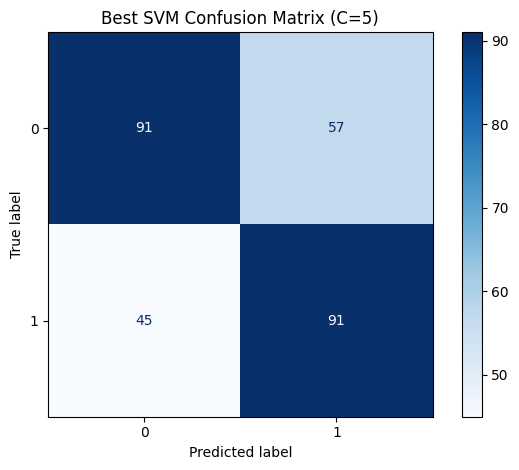

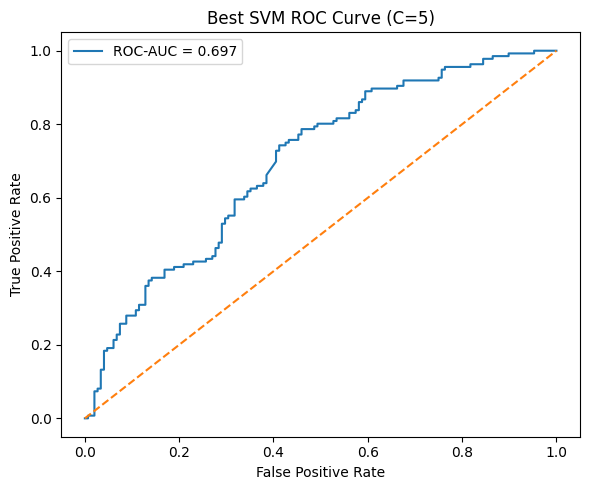

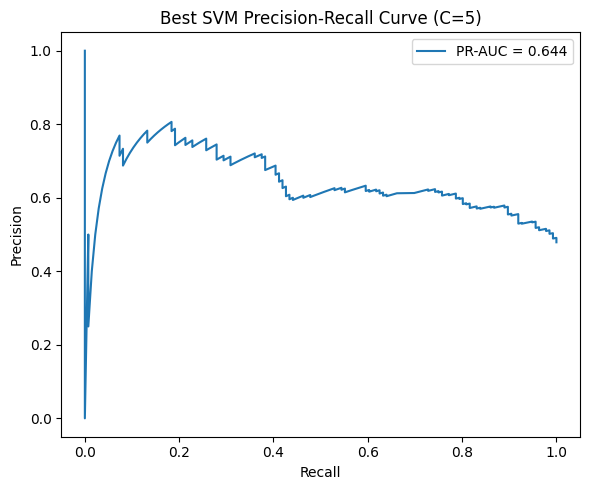

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)

# -----------------------------
# 1. Prepare numeric features
# -----------------------------
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]

X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Keep common columns only
common_cols = X_train_num.columns.intersection(X_test_num.columns)

X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

print("Training shape before selection:", X_train_num.shape)
print("Testing shape before selection:", X_test_num.shape)

# -----------------------------
# 2. Cross-validation setup
# -----------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -----------------------------
# 3. Tune only C manually
# -----------------------------
C_values = [5]

best_score = -np.inf
best_C = None
best_model = None

results = []

for C_val in C_values:

    print(f"\n========== Testing C = {C_val} ==========")

    svm_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            gamma="scale",
            C=C_val,
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])

    # Cross-validation ROC-AUC
    cv_scores = cross_val_score(
        svm_pipeline,
        X_train_num,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)

    print(f"CV ROC-AUC: {mean_score:.4f} ± {std_score:.4f}")

    results.append({
        "C": C_val,
        "Mean ROC-AUC": mean_score,
        "Std ROC-AUC": std_score
    })

    # Track best model
    if mean_score > best_score:
        best_score = mean_score
        best_C = C_val
        best_model = svm_pipeline

# -----------------------------
# 4. Final best parameter
# -----------------------------
print("\n====================================")
print("Best C:", best_C)
print("Best CV ROC-AUC:", best_score)
print("====================================")

# -----------------------------
# 5. Train best model on full training data
# -----------------------------
best_model.fit(X_train_num, y_train)

# -----------------------------
# 6. Evaluate on test set
# -----------------------------
pred = best_model.predict(X_test_num)
prob = best_model.predict_proba(X_test_num)[:, 1]

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_auc = roc_auc_score(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

print("\nTest Performance")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# 7. Show tuning summary
# -----------------------------
results_df = pd.DataFrame(results)

print("\nHyperparameter Tuning Summary:")
print(results_df)

# -----------------------------
# 8. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Best SVM Confusion Matrix (C={best_C})")
plt.tight_layout()
plt.show()

# -----------------------------
# 9. ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Best SVM ROC Curve (C={best_C})")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Precision-Recall curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Best SVM Precision-Recall Curve (C={best_C})")
plt.legend()
plt.tight_layout()
plt.show()

Training shape before selection: (660, 41145)
Testing shape before selection: (284, 41145)

========== Testing C = 10 ==========
CV ROC-AUC: 0.7037 ± 0.0440

Best C: 10
Best CV ROC-AUC: 0.7037445865975552

Test Performance
Accuracy : 0.6408450704225352
Precision: 0.6148648648648649
Recall   : 0.6691176470588235
F1-score : 0.6408450704225352
ROC-AUC  : 0.6972128378378377
PR-AUC   : 0.6444089382281434

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.61      0.64       148
           1       0.61      0.67      0.64       136

    accuracy                           0.64       284
   macro avg       0.64      0.64      0.64       284
weighted avg       0.64      0.64      0.64       284


Hyperparameter Tuning Summary:
    C  Mean ROC-AUC  Std ROC-AUC
0  10      0.703745     0.044049


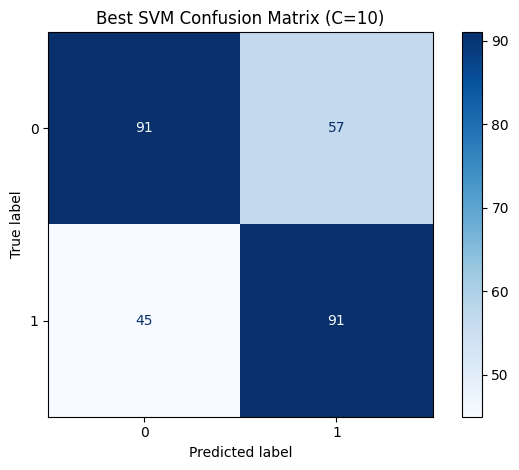

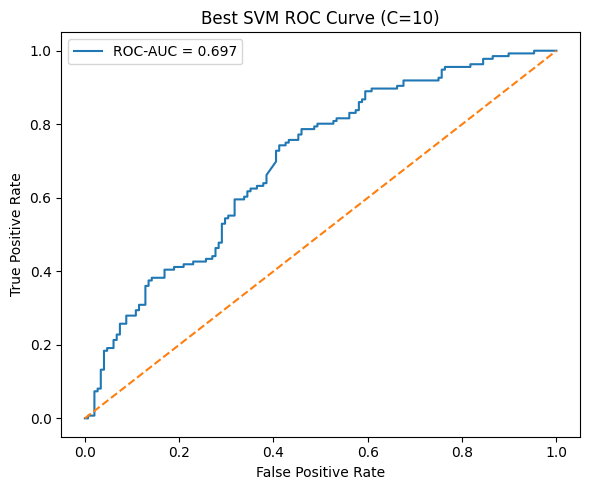

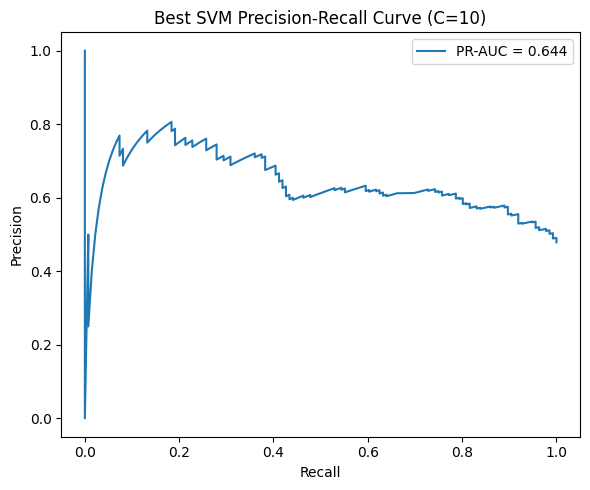

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)

# -----------------------------
# 1. Prepare numeric features
# -----------------------------
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]

X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Keep common columns only
common_cols = X_train_num.columns.intersection(X_test_num.columns)

X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

print("Training shape before selection:", X_train_num.shape)
print("Testing shape before selection:", X_test_num.shape)

# -----------------------------
# 2. Cross-validation setup
# -----------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -----------------------------
# 3. Tune only C manually
# -----------------------------
C_values = [10]

best_score = -np.inf
best_C = None
best_model = None

results = []

for C_val in C_values:

    print(f"\n========== Testing C = {C_val} ==========")

    svm_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            gamma="scale",
            C=C_val,
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])

    # Cross-validation ROC-AUC
    cv_scores = cross_val_score(
        svm_pipeline,
        X_train_num,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)

    print(f"CV ROC-AUC: {mean_score:.4f} ± {std_score:.4f}")

    results.append({
        "C": C_val,
        "Mean ROC-AUC": mean_score,
        "Std ROC-AUC": std_score
    })

    # Track best model
    if mean_score > best_score:
        best_score = mean_score
        best_C = C_val
        best_model = svm_pipeline

# -----------------------------
# 4. Final best parameter
# -----------------------------
print("\n====================================")
print("Best C:", best_C)
print("Best CV ROC-AUC:", best_score)
print("====================================")

# -----------------------------
# 5. Train best model on full training data
# -----------------------------
best_model.fit(X_train_num, y_train)

# -----------------------------
# 6. Evaluate on test set
# -----------------------------
pred = best_model.predict(X_test_num)
prob = best_model.predict_proba(X_test_num)[:, 1]

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_auc = roc_auc_score(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

print("\nTest Performance")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# 7. Show tuning summary
# -----------------------------
results_df = pd.DataFrame(results)

print("\nHyperparameter Tuning Summary:")
print(results_df)

# -----------------------------
# 8. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Best SVM Confusion Matrix (C={best_C})")
plt.tight_layout()
plt.show()

# -----------------------------
# 9. ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Best SVM ROC Curve (C={best_C})")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Precision-Recall curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Best SVM Precision-Recall Curve (C={best_C})")
plt.legend()
plt.tight_layout()
plt.show()

       C  ROC_AUC
0   0.01   0.6466
1   0.10   0.6466
2   1.00   0.6831
3   5.00   0.7037
4  10.00   0.7037


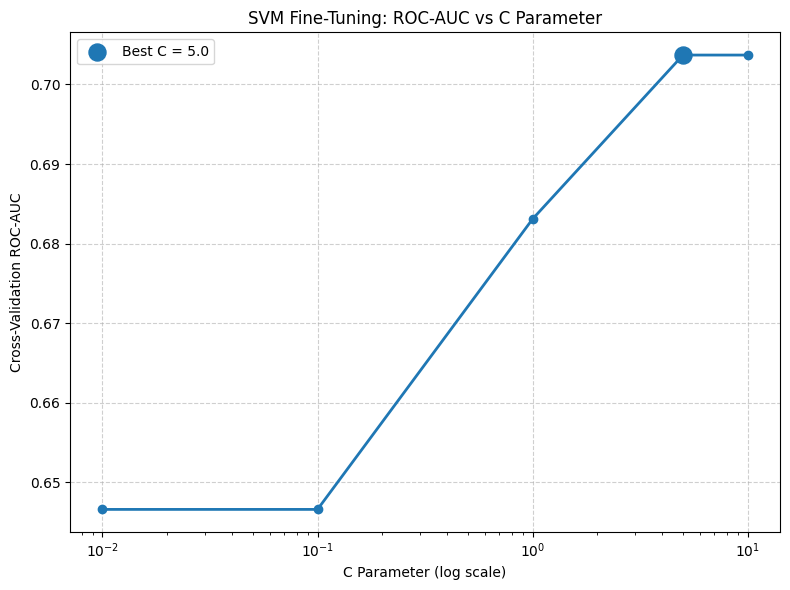

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# ROC-AUC results for each C
# -----------------------------
results = {
    "C": [0.01, 0.1, 1, 5, 10],
    "ROC_AUC": [
        0.6466,
        0.6466,
        0.6831,
        0.7037,
        0.7037
    ]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

# -----------------------------
# Plot ROC-AUC vs C
# -----------------------------
plt.figure(figsize=(8,6))

plt.plot(
    results_df["C"],
    results_df["ROC_AUC"],
    marker='o',
    linewidth=2
)

# Log scale for better spacing
plt.xscale("log")

# Highlight best C
best_idx = results_df["ROC_AUC"].idxmax()
best_C = results_df.loc[best_idx, "C"]
best_score = results_df.loc[best_idx, "ROC_AUC"]

plt.scatter(
    best_C,
    best_score,
    s=150,
    label=f"Best C = {best_C}"
)

plt.xlabel("C Parameter (log scale)")
plt.ylabel("Cross-Validation ROC-AUC")
plt.title("SVM Fine-Tuning: ROC-AUC vs C Parameter")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()


Testing gamma = scale
Accuracy : 0.6408450704225352
Precision: 0.6148648648648649
Recall   : 0.6691176470588235
F1-score : 0.6408450704225352
ROC-AUC  : 0.6972128378378377
PR-AUC   : 0.6444089382281434

Testing gamma = 0.0001
Accuracy : 0.5387323943661971
Precision: 0.5144508670520231
Recall   : 0.6544117647058824
F1-score : 0.5760517799352751
ROC-AUC  : 0.622739467408585
PR-AUC   : 0.5899495016637343

Testing gamma = 0.001
Accuracy : 0.4788732394366197
Precision: 0.4788732394366197
Recall   : 1.0
F1-score : 0.6476190476190476
ROC-AUC  : 0.4236138712241654
PR-AUC   : 0.44242002204327496

Testing gamma = 0.01
Accuracy : 0.4788732394366197
Precision: 0.4788732394366197
Recall   : 1.0
F1-score : 0.6476190476190476
ROC-AUC  : 0.5
PR-AUC   : 0.4788732394366197

Manual Gamma Tuning Results:
   C   gamma  Accuracy  Precision    Recall        F1   ROC-AUC    PR-AUC
0  5   scale  0.640845   0.614865  0.669118  0.640845  0.697213  0.644409
1  5  0.0001  0.538732   0.514451  0.654412  0.576052  

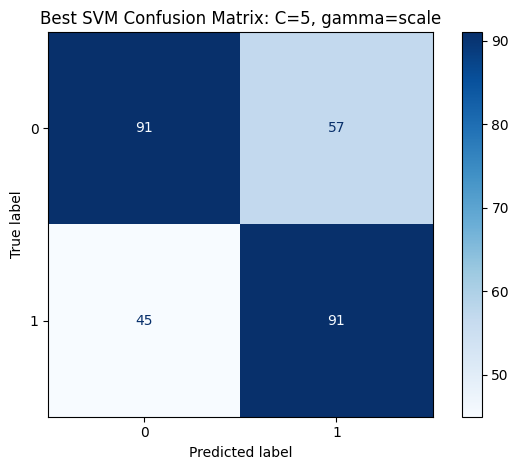

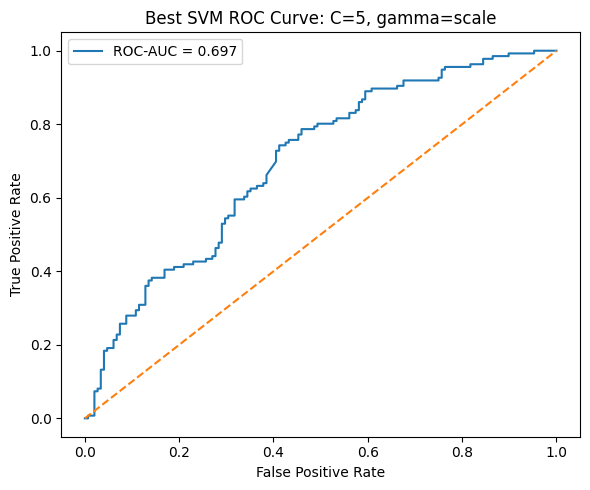

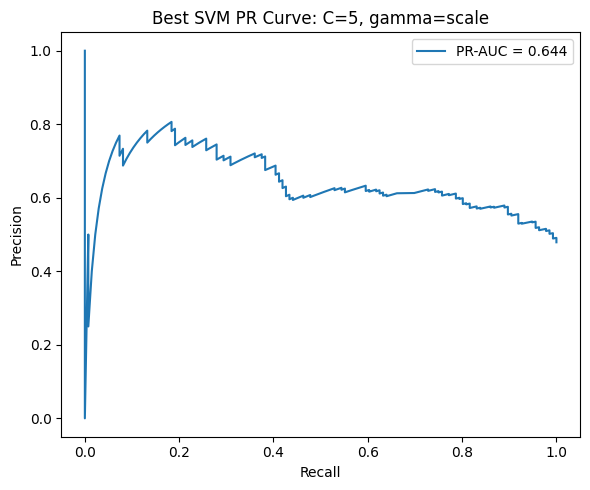

In [ ]:
# Best C from previous tuning
best_C = 5

# Gamma values to test manually
gamma_values = ["scale", 0.0001, 0.001, 0.01]

best_score = -1
best_gamma = None
best_model = None

gamma_results = []

for gamma_val in gamma_values:

    print("\n====================================")
    print(f"Testing gamma = {gamma_val}")
    print("====================================")

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=best_C,
            gamma=gamma_val,
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])

    # Train model
    model.fit(X_train_num, y_train)

    # Predict test set
    pred = model.predict(X_test_num)
    prob = model.predict_proba(X_test_num)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc_auc)
    print("PR-AUC   :", pr_auc)

    gamma_results.append({
        "C": best_C,
        "gamma": gamma_val,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    if roc_auc > best_score:
        best_score = roc_auc
        best_gamma = gamma_val
        best_model = model

# -----------------------------
# Results table
# -----------------------------
gamma_results_df = pd.DataFrame(gamma_results)

print("\nManual Gamma Tuning Results:")
print(gamma_results_df)

print("\nBest gamma:", best_gamma)
print("Best ROC-AUC:", best_score)

# -----------------------------
# Final evaluation using best model
# -----------------------------
pred = best_model.predict(X_test_num)
prob = best_model.predict_proba(X_test_num)[:, 1]

print("\nClassification Report for Best Model:")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Best SVM Confusion Matrix: C={best_C}, gamma={best_gamma}")
plt.tight_layout()
plt.show()

# -----------------------------
# ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {best_score:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Best SVM ROC Curve: C={best_C}, gamma={best_gamma}")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# PR curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Best SVM PR Curve: C={best_C}, gamma={best_gamma}")
plt.legend()
plt.tight_layout()
plt.show()

    gamma   ROC_AUC
0   scale  0.697213
1  0.0001  0.622739
2   0.001  0.423614
3    0.01  0.500000


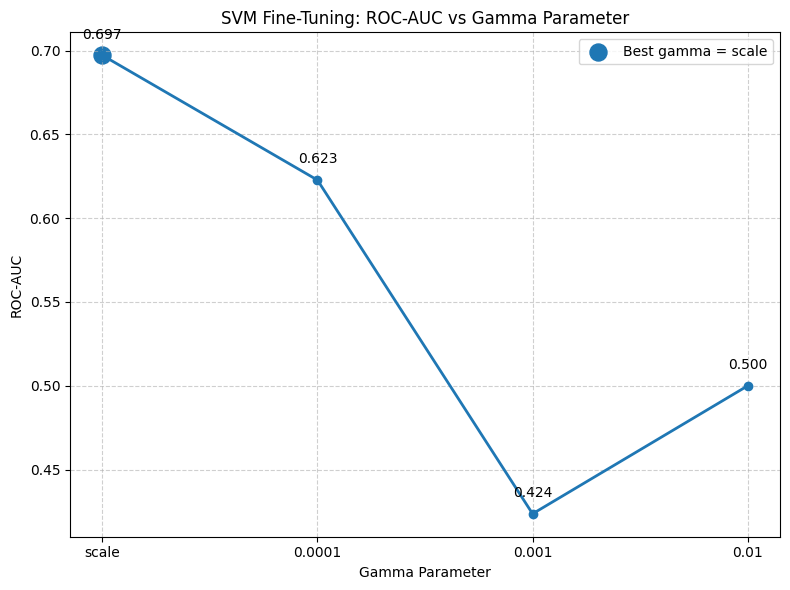

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Manual gamma tuning results
# -----------------------------
gamma_results = pd.DataFrame({
    "gamma": ["scale", 0.0001, 0.001, 0.01],
    "ROC_AUC": [0.697213, 0.622739, 0.423614, 0.500000]
})

print(gamma_results)

# -----------------------------
# Convert gamma labels for plotting
# -----------------------------
gamma_labels = gamma_results["gamma"].astype(str)

# -----------------------------
# Plot ROC-AUC vs gamma
# -----------------------------
plt.figure(figsize=(8,6))

plt.plot(
    gamma_labels,
    gamma_results["ROC_AUC"],
    marker='o',
    linewidth=2
)

# Highlight best gamma
best_idx = gamma_results["ROC_AUC"].idxmax()
best_gamma = gamma_results.loc[best_idx, "gamma"]
best_score = gamma_results.loc[best_idx, "ROC_AUC"]

plt.scatter(
    str(best_gamma),
    best_score,
    s=150,
    label=f"Best gamma = {best_gamma}"
)

# Annotate points
for i, row in gamma_results.iterrows():
    plt.text(
        i,
        row["ROC_AUC"] + 0.01,
        f"{row['ROC_AUC']:.3f}",
        ha='center'
    )

plt.xlabel("Gamma Parameter")
plt.ylabel("ROC-AUC")
plt.title("SVM Fine-Tuning: ROC-AUC vs Gamma Parameter")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()


Testing kernel = rbf, degree = None
Accuracy : 0.6408450704225352
Precision: 0.6148648648648649
Recall   : 0.6691176470588235
F1-score : 0.6408450704225352
ROC-AUC  : 0.6972128378378377
PR-AUC   : 0.6444089382281434

Testing kernel = poly, degree = 2
Accuracy : 0.5880281690140845
Precision: 0.5683453237410072
Recall   : 0.5808823529411765
F1-score : 0.5745454545454546
ROC-AUC  : 0.6320548489666137
PR-AUC   : 0.5992411241211174

Testing kernel = poly, degree = 3
Accuracy : 0.6091549295774648
Precision: 0.6106194690265486
Recall   : 0.5073529411764706
F1-score : 0.5542168674698795
ROC-AUC  : 0.6575168918918919
PR-AUC   : 0.64415118845611

Further Hyperparameter Tuning Results:
  kernel  degree  Accuracy  Precision    Recall        F1   ROC-AUC    PR-AUC
0    rbf     NaN  0.640845   0.614865  0.669118  0.640845  0.697213  0.644409
1   poly     2.0  0.588028   0.568345  0.580882  0.574545  0.632055  0.599241
2   poly     3.0  0.609155   0.610619  0.507353  0.554217  0.657517  0.644151

Be

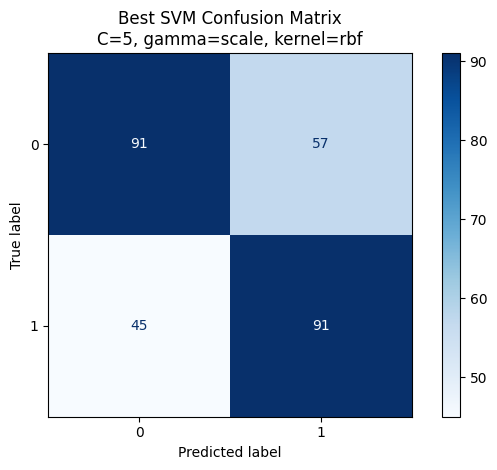

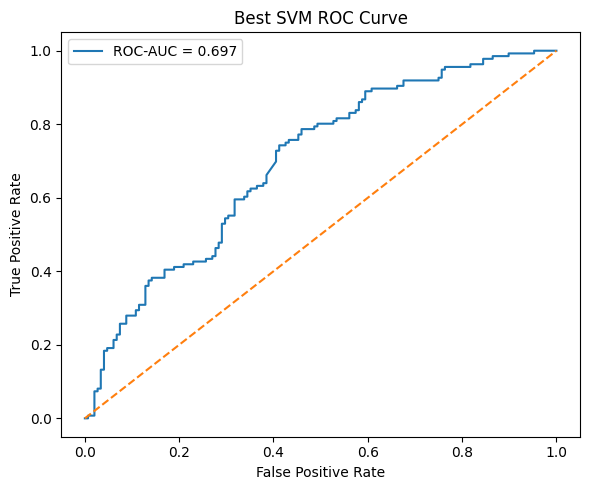

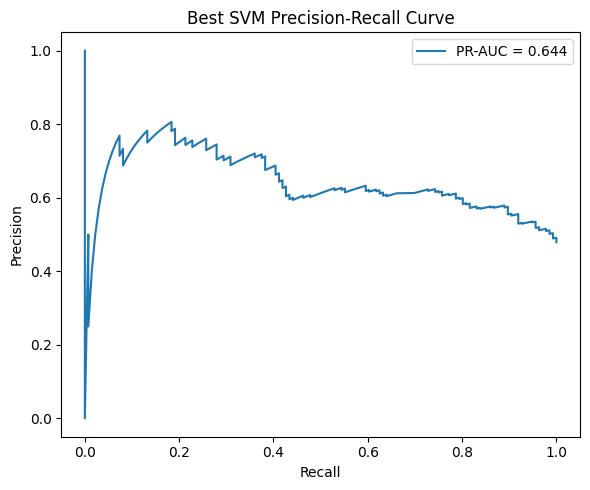

In [ ]:
# Fixed best parameters from previous tuning
best_C = 5
best_gamma = "scale"

# Degree values for polynomial kernel (optional exploration)
degree_values = [2, 3]

# Kernel options to compare
kernel_values = ["rbf", "poly"]

best_score = -1
best_params = None
best_model = None

tuning_results = []

for kernel_val in kernel_values:

    # For RBF kernel, degree is ignored
    if kernel_val == "rbf":
        degrees_to_test = [None]
    else:
        degrees_to_test = degree_values

    for degree_val in degrees_to_test:

        print("\n====================================")
        print(f"Testing kernel = {kernel_val}, degree = {degree_val}")
        print("====================================")

        svm_params = {
            "kernel": kernel_val,
            "C": best_C,
            "gamma": best_gamma,
            "probability": True,
            "class_weight": "balanced",
            "random_state": 42
        }

        if degree_val is not None:
            svm_params["degree"] = degree_val

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("svm", SVC(**svm_params))
        ])

        # Train model
        model.fit(X_train_num, y_train)

        # Predict
        pred = model.predict(X_test_num)
        prob = model.predict_proba(X_test_num)[:, 1]

        # Metrics
        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred)
        rec = recall_score(y_test, pred)
        f1 = f1_score(y_test, pred)
        roc_auc = roc_auc_score(y_test, prob)
        pr_auc = average_precision_score(y_test, prob)

        print("Accuracy :", acc)
        print("Precision:", prec)
        print("Recall   :", rec)
        print("F1-score :", f1)
        print("ROC-AUC  :", roc_auc)
        print("PR-AUC   :", pr_auc)

        tuning_results.append({
            "kernel": kernel_val,
            "degree": degree_val,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc
        })

        # Track best model
        if roc_auc > best_score:
            best_score = roc_auc
            best_params = {
                "kernel": kernel_val,
                "degree": degree_val
            }
            best_model = model

# -----------------------------
# Results summary
# -----------------------------
results_df = pd.DataFrame(tuning_results)

print("\nFurther Hyperparameter Tuning Results:")
print(results_df)

print("\nBest Parameters:")
print(best_params)
print("Best ROC-AUC:", best_score)

# -----------------------------
# Final best model evaluation
# -----------------------------
pred = best_model.predict(X_test_num)
prob = best_model.predict_proba(X_test_num)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(
    f"Best SVM Confusion Matrix\nC={best_C}, gamma={best_gamma}, kernel={best_params['kernel']}"
)
plt.tight_layout()
plt.show()

# -----------------------------
# ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {best_score:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Best SVM ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Precision-Recall curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Best SVM Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

  kernel  degree   ROC_AUC    PR_AUC         label
0    rbf     NaN  0.697213  0.644409           RBF
1   poly     2.0  0.632055  0.599241  Poly (deg=2)
2   poly     3.0  0.657517  0.644151  Poly (deg=3)


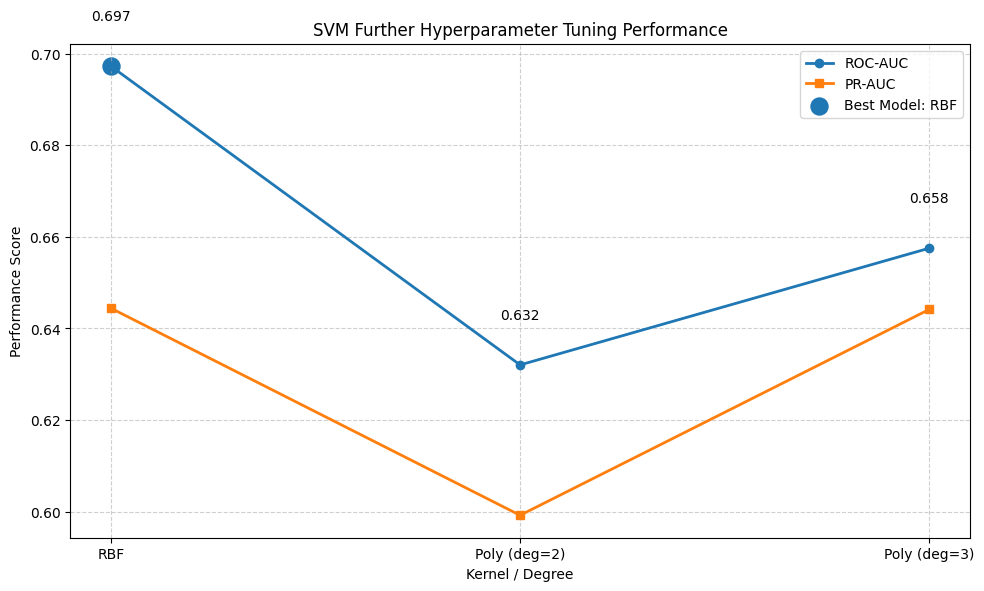

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Hyperparameter tuning results
# -----------------------------
results_df = pd.DataFrame({
    "kernel": ["rbf", "poly", "poly"],
    "degree": [None, 2, 3],
    "ROC_AUC": [0.697213, 0.632055, 0.657517],
    "PR_AUC": [0.644409, 0.599241, 0.644151]
})

# Create readable labels
results_df["label"] = results_df.apply(
    lambda row: "RBF" if row["kernel"] == "rbf" else f"Poly (deg={int(row['degree'])})",
    axis=1
)

print(results_df)

# -----------------------------
# Plot ROC-AUC and PR-AUC
# -----------------------------
x_labels = results_df["label"]

plt.figure(figsize=(10,6))

# ROC-AUC
plt.plot(
    x_labels,
    results_df["ROC_AUC"],
    marker='o',
    linewidth=2,
    label="ROC-AUC"
)

# PR-AUC
plt.plot(
    x_labels,
    results_df["PR_AUC"],
    marker='s',
    linewidth=2,
    label="PR-AUC"
)

# Highlight best ROC-AUC
best_idx = results_df["ROC_AUC"].idxmax()

plt.scatter(
    x_labels.iloc[best_idx],
    results_df["ROC_AUC"].iloc[best_idx],
    s=150,
    label=f"Best Model: {x_labels.iloc[best_idx]}"
)

# Annotate values
for i in range(len(results_df)):
    plt.text(
        i,
        results_df["ROC_AUC"].iloc[i] + 0.01,
        f"{results_df['ROC_AUC'].iloc[i]:.3f}",
        ha='center'
    )

plt.xlabel("Kernel / Degree")
plt.ylabel("Performance Score")
plt.title("SVM Further Hyperparameter Tuning Performance")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd

# -----------------------------
# Final best SVM model summary
# -----------------------------
final_svm_results = pd.DataFrame({
    "Model": ["SVM (Fine-Tuned)"],
    "Kernel": ["rbf"],
    "C": [5],
    "Gamma": ["scale"],
    "Accuracy": [0.640845],
    "Precision": [0.614865],
    "Recall": [0.669118],
    "F1-Score": [0.640845],
    "ROC-AUC": [0.697213],
    "PR-AUC": [0.644409]
})

print("\nFinal Best SVM Model Performance:")
print(final_svm_results)

# Optional: nicer formatting
print("\nFormatted Performance Table:")
print(final_svm_results.round(4).to_string(index=False))


Final Best SVM Model Performance:
              Model Kernel  C  Gamma  Accuracy  Precision    Recall  F1-Score  \
0  SVM (Fine-Tuned)    rbf  5  scale  0.640845   0.614865  0.669118  0.640845   

    ROC-AUC    PR-AUC  
0  0.697213  0.644409  

Formatted Performance Table:
           Model Kernel  C Gamma  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
SVM (Fine-Tuned)    rbf  5 scale    0.6408     0.6149  0.6691    0.6408   0.6972  0.6444


Original features: 41146
Selected features: 29165

Testing C = 0.001
Accuracy : 0.676056338028169
Precision: 0.6486486486486487
Recall   : 0.7058823529411765
F1-score : 0.676056338028169
ROC-AUC  : 0.7302265500794913
PR-AUC   : 0.7100065080670935

Testing C = 0.01
Accuracy : 0.6584507042253521
Precision: 0.6291390728476821
Recall   : 0.6985294117647058
F1-score : 0.662020905923345
ROC-AUC  : 0.7265003974562798
PR-AUC   : 0.7061807826553279

Testing C = 0.1
Accuracy : 0.6619718309859155
Precision: 0.6351351351351351
Recall   : 0.6911764705882353
F1-score : 0.6619718309859155
ROC-AUC  : 0.7240659777424483
PR-AUC   : 0.7027721304864418

Testing C = 1
Accuracy : 0.6619718309859155
Precision: 0.6388888888888888
Recall   : 0.6764705882352942
F1-score : 0.6571428571428571
ROC-AUC  : 0.7236685214626392
PR-AUC   : 0.7050434480377923

Testing C = 5
Accuracy : 0.6725352112676056
Precision: 0.6462585034013606
Recall   : 0.6985294117647058
F1-score : 0.6713780918727915
ROC-AUC  : 0.7291832273449921

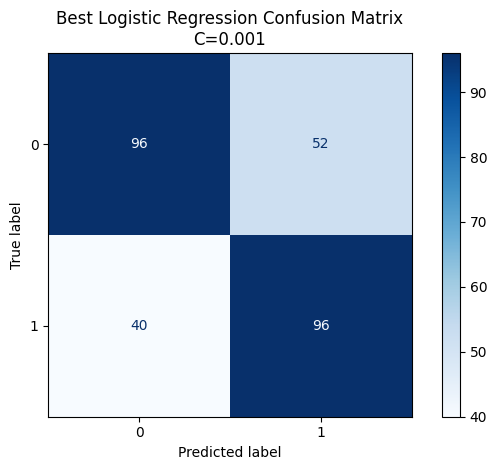

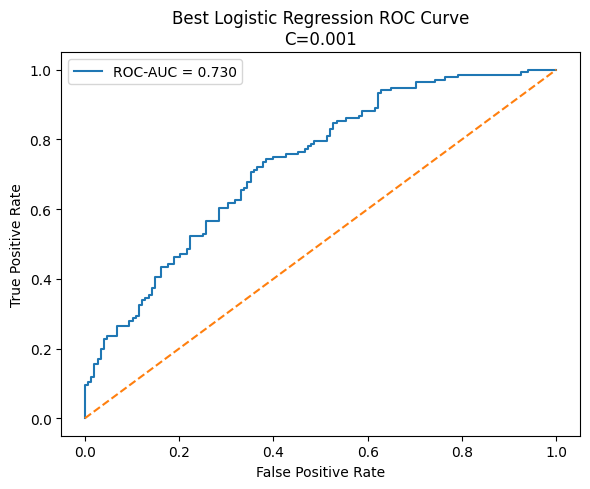

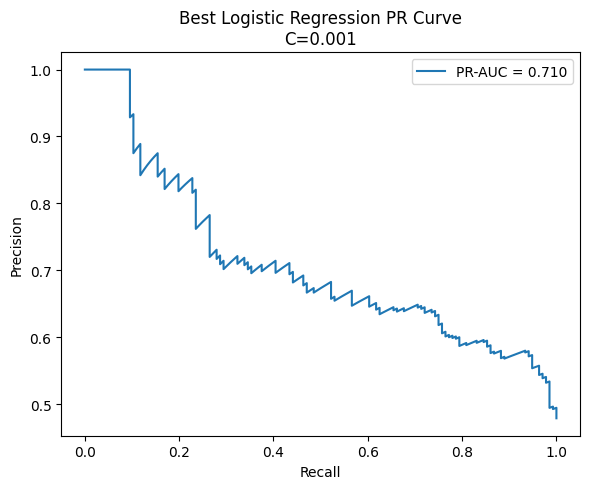

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)

# -----------------------------
# 1. Prepare numeric features
# -----------------------------
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]

X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Keep common columns
common_cols = X_train_num.columns.intersection(X_test_num.columns)

X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

# Remove all-NaN columns
valid_cols = X_train_num.columns[X_train_num.notna().any()]

X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# -----------------------------
# 2. Impute missing values
# -----------------------------
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train_num)
X_test_imp  = imputer.transform(X_test_num)

# -----------------------------
# 3. Variance threshold
# -----------------------------
selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train_imp)
X_test_var  = selector.transform(X_test_imp)

print("Original features:", X_train_num.shape[1])
print("Selected features:", X_train_var.shape[1])

# -----------------------------
# 4. Scale features
# Important for Logistic Regression
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled  = scaler.transform(X_test_var)

# -----------------------------
# 5. Manual fine-tuning: C parameter
# -----------------------------
C_values = [0.001, 0.01, 0.1, 1, 5, 10, 100]

lr_results = []

best_score = -1
best_C = None
best_model = None

for C_val in C_values:

    print("\n====================================")
    print(f"Testing C = {C_val}")
    print("====================================")

    model = LogisticRegression(
        C=C_val,
        penalty="l2",
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)
    prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc_auc)
    print("PR-AUC   :", pr_auc)

    lr_results.append({
        "C": C_val,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    if roc_auc > best_score:
        best_score = roc_auc
        best_C = C_val
        best_model = model

# -----------------------------
# 6. Results summary
# -----------------------------
lr_results_df = pd.DataFrame(lr_results)

print("\nLogistic Regression Manual Tuning Results:")
print(lr_results_df)

print("\nBest C:", best_C)
print("Best ROC-AUC:", best_score)

# -----------------------------
# 7. Final evaluation
# -----------------------------
pred = best_model.predict(X_test_scaled)
prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Best Logistic Regression Confusion Matrix\nC={best_C}")
plt.tight_layout()
plt.show()

# -----------------------------
# 8. ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {best_score:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Best Logistic Regression ROC Curve\nC={best_C}")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 9. PR curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Best Logistic Regression PR Curve\nC={best_C}")
plt.legend()
plt.tight_layout()
plt.show()

         C   ROC_AUC    PR_AUC  Accuracy
0    0.001  0.730227  0.710007  0.676056
1    0.010  0.726500  0.706181  0.658451
2    0.100  0.724066  0.702772  0.661972
3    1.000  0.723669  0.705043  0.661972
4    5.000  0.729183  0.707464  0.672535
5   10.000  0.729332  0.707896  0.672535
6  100.000  0.728885  0.708161  0.672535


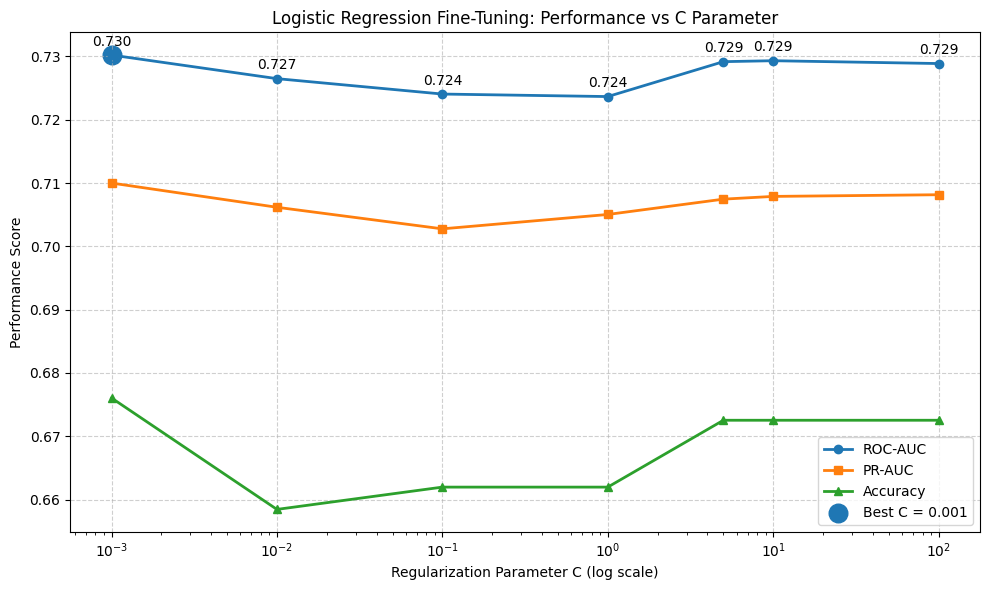

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Logistic Regression tuning results
# -----------------------------
lr_results_df = pd.DataFrame({
    "C": [0.001, 0.01, 0.1, 1, 5, 10, 100],
    "ROC_AUC": [0.730227, 0.726500, 0.724066, 0.723669, 0.729183, 0.729332, 0.728885],
    "PR_AUC": [0.710007, 0.706181, 0.702772, 0.705043, 0.707464, 0.707896, 0.708161],
    "Accuracy": [0.676056, 0.658451, 0.661972, 0.661972, 0.672535, 0.672535, 0.672535]
})

print(lr_results_df)

# -----------------------------
# Plot performance vs C
# -----------------------------
plt.figure(figsize=(10,6))

# ROC-AUC
plt.plot(
    lr_results_df["C"],
    lr_results_df["ROC_AUC"],
    marker='o',
    linewidth=2,
    label="ROC-AUC"
)

# PR-AUC
plt.plot(
    lr_results_df["C"],
    lr_results_df["PR_AUC"],
    marker='s',
    linewidth=2,
    label="PR-AUC"
)

# Accuracy
plt.plot(
    lr_results_df["C"],
    lr_results_df["Accuracy"],
    marker='^',
    linewidth=2,
    label="Accuracy"
)

# Use log scale for C
plt.xscale("log")

# Highlight best ROC-AUC
best_idx = lr_results_df["ROC_AUC"].idxmax()
best_C = lr_results_df.loc[best_idx, "C"]
best_score = lr_results_df.loc[best_idx, "ROC_AUC"]

plt.scatter(
    best_C,
    best_score,
    s=180,
    label=f"Best C = {best_C}"
)

# Annotate ROC-AUC values
for _, row in lr_results_df.iterrows():
    plt.text(
        row["C"],
        row["ROC_AUC"] + 0.0015,
        f"{row['ROC_AUC']:.3f}",
        ha='center'
    )

plt.xlabel("Regularization Parameter C (log scale)")
plt.ylabel("Performance Score")
plt.title("Logistic Regression Fine-Tuning: Performance vs C Parameter")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
max_depth_values = [3, 5, 10, 20, None]

dt_depth_results = []

best_score = -1
best_depth = None
best_model = None

for depth in max_depth_values:

    print("\n====================================")
    print(f"Testing max_depth = {depth}")
    print("====================================")

    model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_var, y_train)

    pred = model.predict(X_test_var)
    prob = model.predict_proba(X_test_var)[:, 1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc_auc)
    print("PR-AUC   :", pr_auc)

    dt_depth_results.append({
        "max_depth": depth,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    if roc_auc > best_score:
        best_score = roc_auc
        best_depth = depth
        best_model = model

dt_depth_results_df = pd.DataFrame(dt_depth_results)

print("\nDecision Tree max_depth Tuning Results:")
print(dt_depth_results_df)

print("\nBest max_depth:", best_depth)
print("Best ROC-AUC:", best_score)


Testing max_depth = 3
Accuracy : 0.602112676056338
Precision: 0.6263736263736264
Recall   : 0.41911764705882354
F1-score : 0.5022026431718062
ROC-AUC  : 0.5926073131955486
PR-AUC   : 0.555673997985187

Testing max_depth = 5
Accuracy : 0.5492957746478874
Precision: 0.5338983050847458
Recall   : 0.4632352941176471
F1-score : 0.49606299212598426
ROC-AUC  : 0.5427265500794913
PR-AUC   : 0.5273079473651459

Testing max_depth = 10
Accuracy : 0.5563380281690141
Precision: 0.5396825396825397
Recall   : 0.5
F1-score : 0.5190839694656488
ROC-AUC  : 0.5458068362480126
PR-AUC   : 0.5094328240685946

Testing max_depth = 20
Accuracy : 0.545774647887324
Precision: 0.524822695035461
Recall   : 0.5441176470588235
F1-score : 0.5342960288808665
ROC-AUC  : 0.5457074721780604
PR-AUC   : 0.5038751491006951

Testing max_depth = None
Accuracy : 0.545774647887324
Precision: 0.524822695035461
Recall   : 0.5441176470588235
F1-score : 0.5342960288808665
ROC-AUC  : 0.5457074721780604
PR-AUC   : 0.5038751491006951

  max_depth   ROC_AUC    PR_AUC  Accuracy
0         3  0.592607  0.555674  0.602113
1         5  0.542727  0.527308  0.549296
2        10  0.545807  0.509433  0.556338
3        20  0.545707  0.503875  0.545775
4      None  0.545707  0.503875  0.545775


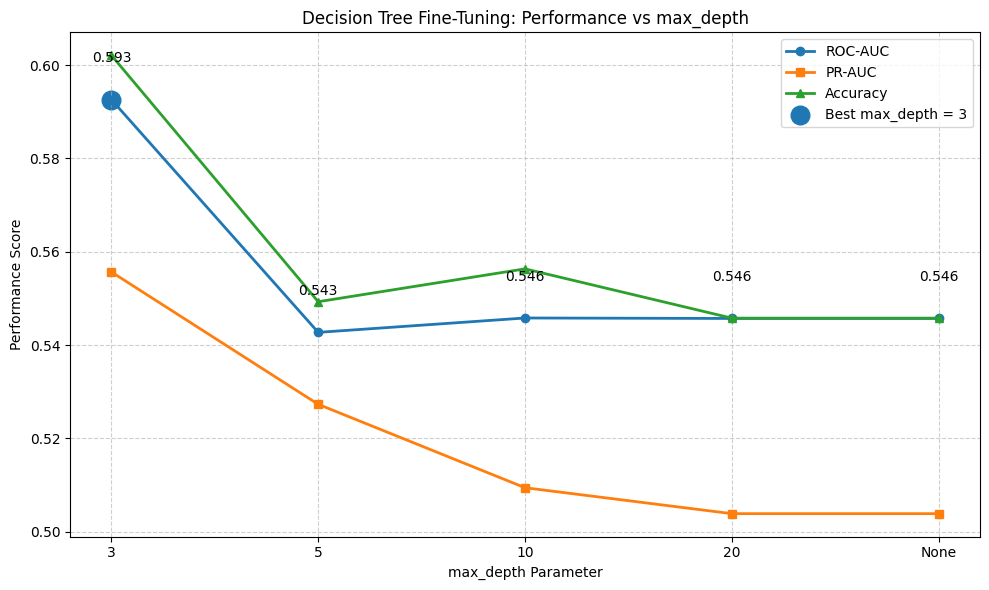

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Decision Tree max_depth tuning results
# -----------------------------
dt_results_df = pd.DataFrame({
    "max_depth": [3, 5, 10, 20, "None"],
    "ROC_AUC": [0.592607, 0.542727, 0.545807, 0.545707, 0.545707],
    "PR_AUC": [0.555674, 0.527308, 0.509433, 0.503875, 0.503875],
    "Accuracy": [0.602113, 0.549296, 0.556338, 0.545775, 0.545775]
})

print(dt_results_df)

# -----------------------------
# Plot performance vs max_depth
# -----------------------------
plt.figure(figsize=(10,6))

# ROC-AUC
plt.plot(
    dt_results_df["max_depth"].astype(str),
    dt_results_df["ROC_AUC"],
    marker='o',
    linewidth=2,
    label="ROC-AUC"
)

# PR-AUC
plt.plot(
    dt_results_df["max_depth"].astype(str),
    dt_results_df["PR_AUC"],
    marker='s',
    linewidth=2,
    label="PR-AUC"
)

# Accuracy
plt.plot(
    dt_results_df["max_depth"].astype(str),
    dt_results_df["Accuracy"],
    marker='^',
    linewidth=2,
    label="Accuracy"
)

# Highlight best ROC-AUC
best_idx = dt_results_df["ROC_AUC"].idxmax()
best_depth = dt_results_df.loc[best_idx, "max_depth"]
best_score = dt_results_df.loc[best_idx, "ROC_AUC"]

plt.scatter(
    str(best_depth),
    best_score,
    s=180,
    label=f"Best max_depth = {best_depth}"
)

# Annotate ROC-AUC values
for i, row in dt_results_df.iterrows():
    plt.text(
        i,
        row["ROC_AUC"] + 0.008,
        f"{row['ROC_AUC']:.3f}",
        ha='center'
    )

plt.xlabel("max_depth Parameter")
plt.ylabel("Performance Score")
plt.title("Decision Tree Fine-Tuning: Performance vs max_depth")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

## Random Forest fine tunning

Original features: 41146
Selected features: 29165

Testing n_estimators = 100
Accuracy : 0.602112676056338
Precision: 0.5815602836879432
Recall   : 0.6029411764705882
F1-score : 0.592057761732852
ROC-AUC  : 0.6563742050874404
PR-AUC   : 0.6132521067628478

Testing n_estimators = 200
Accuracy : 0.6161971830985915
Precision: 0.5971223021582733
Recall   : 0.6102941176470589
F1-score : 0.6036363636363636
ROC-AUC  : 0.6704093799682035
PR-AUC   : 0.6341892422690643

Testing n_estimators = 300
Accuracy : 0.602112676056338
Precision: 0.5815602836879432
Recall   : 0.6029411764705882
F1-score : 0.592057761732852
ROC-AUC  : 0.6602245627980922
PR-AUC   : 0.6269090670608373

Testing n_estimators = 500
Accuracy : 0.602112676056338
Precision: 0.5864661654135338
Recall   : 0.5735294117647058
F1-score : 0.5799256505576208
ROC-AUC  : 0.6724711844197139
PR-AUC   : 0.6398239399019889

Random Forest Manual Tuning Results:
   n_estimators  Accuracy  Precision    Recall        F1   ROC-AUC    PR-AUC
0       

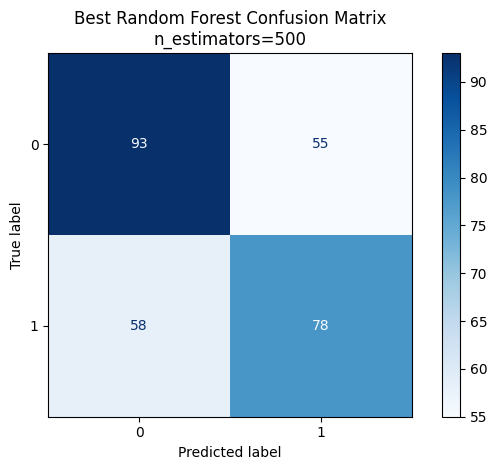

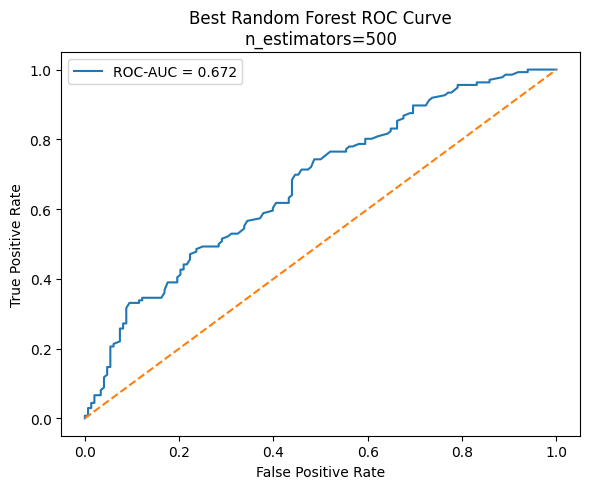

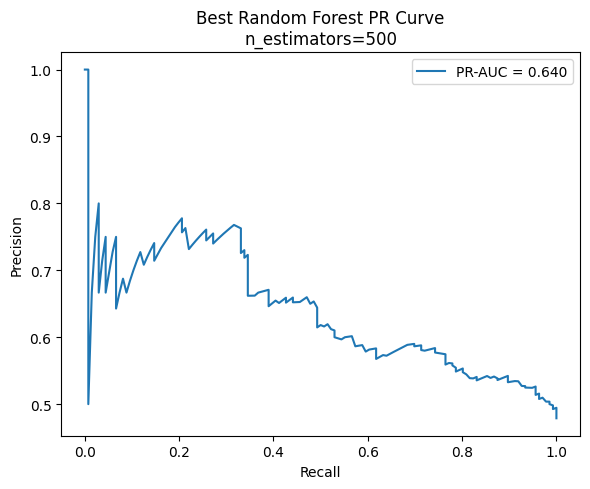

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)

# -----------------------------
# 1. Prepare numeric features
# -----------------------------
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

# Remove leakage columns
leakage_cols = ["label", "Z_SCORE", response_col]

X_train_num = X_train_num.drop(columns=leakage_cols, errors="ignore")
X_test_num  = X_test_num.drop(columns=leakage_cols, errors="ignore")

# Keep common columns
common_cols = X_train_num.columns.intersection(X_test_num.columns)

X_train_num = X_train_num[common_cols]
X_test_num  = X_test_num[common_cols]

# Remove all-NaN columns
valid_cols = X_train_num.columns[X_train_num.notna().any()]

X_train_num = X_train_num[valid_cols]
X_test_num  = X_test_num[valid_cols]

# Impute missing values
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train_num)
X_test_imp  = imputer.transform(X_test_num)

# Variance threshold
selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train_imp)
X_test_var  = selector.transform(X_test_imp)

print("Original features:", X_train_num.shape[1])
print("Selected features:", X_train_var.shape[1])

# -----------------------------
# 2. Manual tuning: n_estimators
# -----------------------------
n_estimators_values = [100, 200, 300, 500]

rf_results = []

best_score = -1
best_model = None
best_n = None

for n in n_estimators_values:

    print("\n====================================")
    print(f"Testing n_estimators = {n}")
    print("====================================")

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(X_train_var, y_train)

    pred = model.predict(X_test_var)
    prob = model.predict_proba(X_test_var)[:, 1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc_auc)
    print("PR-AUC   :", pr_auc)

    rf_results.append({
        "n_estimators": n,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    if roc_auc > best_score:
        best_score = roc_auc
        best_n = n
        best_model = model

# -----------------------------
# 3. Results table
# -----------------------------
rf_results_df = pd.DataFrame(rf_results)

print("\nRandom Forest Manual Tuning Results:")
print(rf_results_df)

print("\nBest n_estimators:", best_n)
print("Best ROC-AUC:", best_score)

# -----------------------------
# 4. Final best model evaluation
# -----------------------------
pred = best_model.predict(X_test_var)
prob = best_model.predict_proba(X_test_var)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Best Random Forest Confusion Matrix\nn_estimators={best_n}")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {best_score:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Best Random Forest ROC Curve\nn_estimators={best_n}")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 6. PR curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Best Random Forest PR Curve\nn_estimators={best_n}")
plt.legend()
plt.tight_layout()
plt.show()

   n_estimators   ROC_AUC    PR_AUC
0           100  0.656374  0.613252
1           200  0.670409  0.634189
2           300  0.660225  0.626909
3           500  0.672471  0.639824


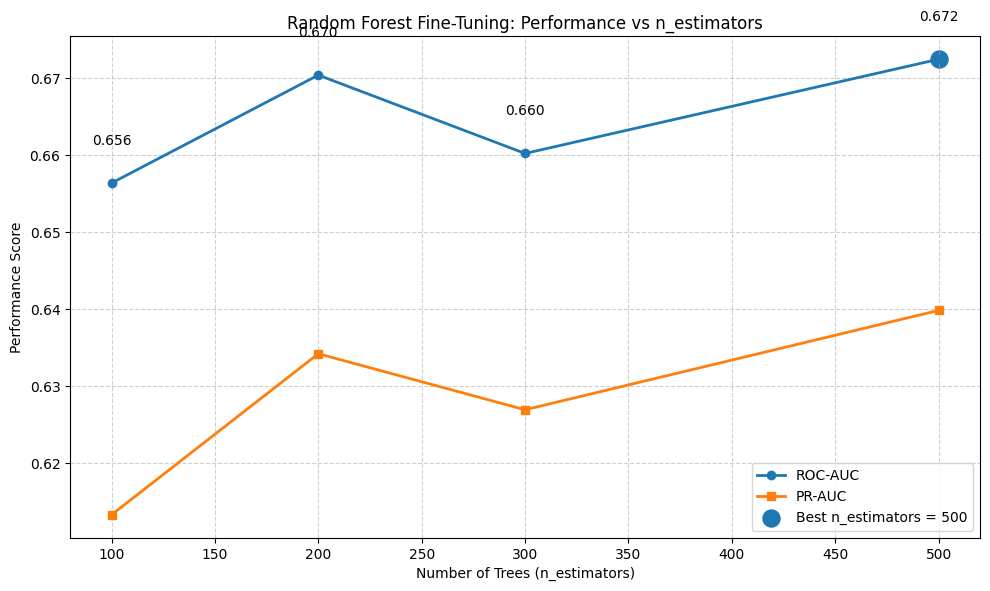

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Random Forest tuning results
# -----------------------------
rf_results_df = pd.DataFrame({
    "n_estimators": [100, 200, 300, 500],
    "ROC_AUC": [0.656374, 0.670409, 0.660225, 0.672471],
    "PR_AUC": [0.613252, 0.634189, 0.626909, 0.639824]
})

print(rf_results_df)

# -----------------------------
# Plot ROC-AUC and PR-AUC
# -----------------------------
plt.figure(figsize=(10,6))

# ROC-AUC line
plt.plot(
    rf_results_df["n_estimators"],
    rf_results_df["ROC_AUC"],
    marker='o',
    linewidth=2,
    label="ROC-AUC"
)

# PR-AUC line
plt.plot(
    rf_results_df["n_estimators"],
    rf_results_df["PR_AUC"],
    marker='s',
    linewidth=2,
    label="PR-AUC"
)

# Highlight best ROC-AUC
best_idx = rf_results_df["ROC_AUC"].idxmax()
best_n = rf_results_df.loc[best_idx, "n_estimators"]
best_score = rf_results_df.loc[best_idx, "ROC_AUC"]

plt.scatter(
    best_n,
    best_score,
    s=150,
    label=f"Best n_estimators = {best_n}"
)

# Annotate ROC-AUC points
for i, row in rf_results_df.iterrows():
    plt.text(
        row["n_estimators"],
        row["ROC_AUC"] + 0.005,
        f"{row['ROC_AUC']:.3f}",
        ha='center'
    )

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Performance Score")
plt.title("Random Forest Fine-Tuning: Performance vs n_estimators")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()




Testing max_depth = 5
Accuracy : 0.6126760563380281
Precision: 0.5970149253731343
Recall   : 0.5882352941176471
F1-score : 0.5925925925925926
ROC-AUC  : 0.6633048489666137
PR-AUC   : 0.6409024799917927

Testing max_depth = 10
Accuracy : 0.6267605633802817
Precision: 0.6153846153846154
Recall   : 0.5882352941176471
F1-score : 0.6015037593984962
ROC-AUC  : 0.6762718600953895
PR-AUC   : 0.6469573447510775

Testing max_depth = 20
Accuracy : 0.6056338028169014
Precision: 0.5909090909090909
Recall   : 0.5735294117647058
F1-score : 0.582089552238806
ROC-AUC  : 0.6722476152623211
PR-AUC   : 0.6396932891396268

Testing max_depth = None
Accuracy : 0.602112676056338
Precision: 0.5864661654135338
Recall   : 0.5735294117647058
F1-score : 0.5799256505576208
ROC-AUC  : 0.6724711844197139
PR-AUC   : 0.6398239399019889

Random Forest max_depth Tuning Results:
   max_depth  Accuracy  Precision    Recall        F1   ROC-AUC    PR-AUC
0        5.0  0.612676   0.597015  0.588235  0.592593  0.663305  0.640

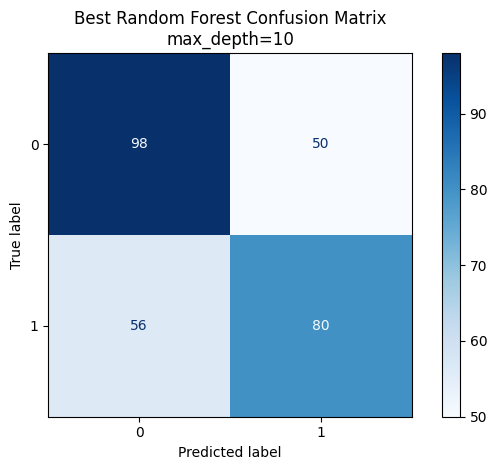

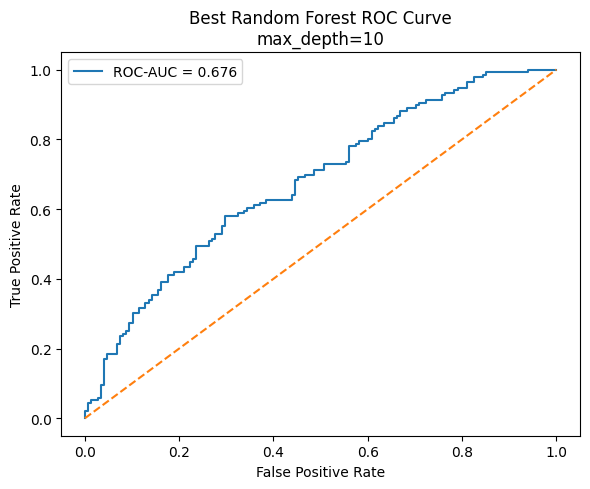

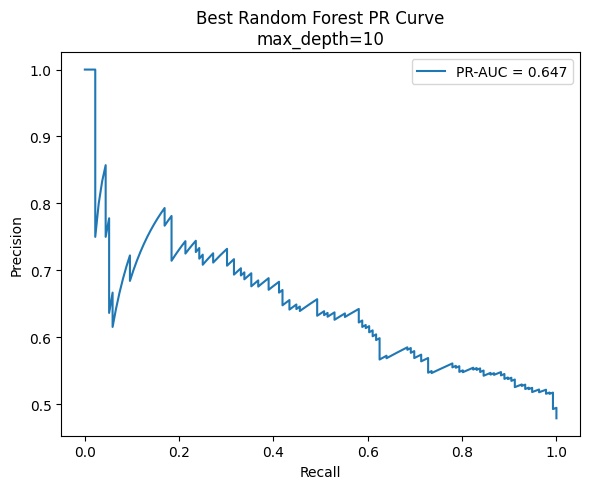

In [ ]:
# -----------------------------
# Manual tuning for max_depth
# Fixed best n_estimators = 500
# -----------------------------

max_depth_values = [5, 10, 20, None]

rf_depth_results = []

best_score = -1
best_depth = None
best_model = None

for depth in max_depth_values:

    print("\n====================================")
    print(f"Testing max_depth = {depth}")
    print("====================================")

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=depth,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    # Train
    model.fit(X_train_var, y_train)

    # Predict
    pred = model.predict(X_test_var)
    prob = model.predict_proba(X_test_var)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc_auc)
    print("PR-AUC   :", pr_auc)

    rf_depth_results.append({
        "max_depth": depth,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    # Track best model
    if roc_auc > best_score:
        best_score = roc_auc
        best_depth = depth
        best_model = model

# -----------------------------
# Results summary
# -----------------------------
rf_depth_results_df = pd.DataFrame(rf_depth_results)

print("\nRandom Forest max_depth Tuning Results:")
print(rf_depth_results_df)

print("\nBest max_depth:", best_depth)
print("Best ROC-AUC:", best_score)

# -----------------------------
# Final best model evaluation
# -----------------------------
pred = best_model.predict(X_test_var)
prob = best_model.predict_proba(X_test_var)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title(f"Best Random Forest Confusion Matrix\nmax_depth={best_depth}")
plt.tight_layout()
plt.show()

# -----------------------------
# ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {best_score:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Best Random Forest ROC Curve\nmax_depth={best_depth}")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Precision-Recall curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Best Random Forest PR Curve\nmax_depth={best_depth}")
plt.legend()
plt.tight_layout()
plt.show()

  max_depth   ROC_AUC    PR_AUC
0         5  0.663305  0.640902
1        10  0.676272  0.646957
2        20  0.672248  0.639693
3      None  0.672471  0.639824


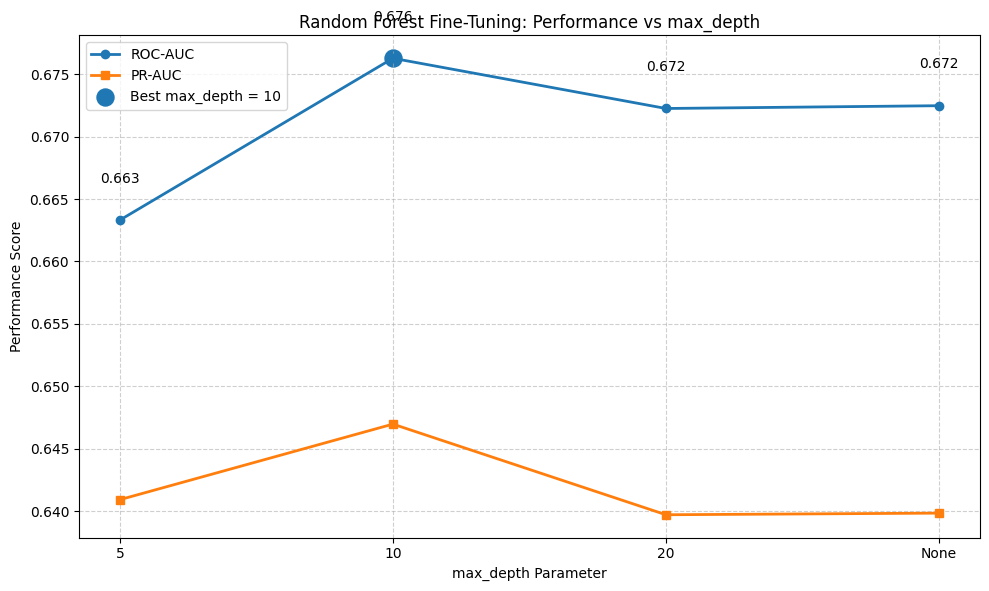

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# max_depth tuning results
# -----------------------------
depth_results_df = pd.DataFrame({
    "max_depth": [5, 10, 20, "None"],
    "ROC_AUC": [0.663305, 0.676272, 0.672248, 0.672471],
    "PR_AUC": [0.640902, 0.646957, 0.639693, 0.639824]
})

print(depth_results_df)

# -----------------------------
# Plot ROC-AUC and PR-AUC
# -----------------------------
plt.figure(figsize=(10,6))

# ROC-AUC line
plt.plot(
    depth_results_df["max_depth"].astype(str),
    depth_results_df["ROC_AUC"],
    marker='o',
    linewidth=2,
    label="ROC-AUC"
)

# PR-AUC line
plt.plot(
    depth_results_df["max_depth"].astype(str),
    depth_results_df["PR_AUC"],
    marker='s',
    linewidth=2,
    label="PR-AUC"
)

# Highlight best ROC-AUC
best_idx = depth_results_df["ROC_AUC"].idxmax()
best_depth = depth_results_df.loc[best_idx, "max_depth"]
best_score = depth_results_df.loc[best_idx, "ROC_AUC"]

plt.scatter(
    str(best_depth),
    best_score,
    s=150,
    label=f"Best max_depth = {best_depth}"
)

# Annotate ROC-AUC values
for i, row in depth_results_df.iterrows():
    plt.text(
        i,
        row["ROC_AUC"] + 0.003,
        f"{row['ROC_AUC']:.3f}",
        ha='center'
    )

plt.xlabel("max_depth Parameter")
plt.ylabel("Performance Score")
plt.title("Random Forest Fine-Tuning: Performance vs max_depth")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()


Testing min_samples_split = 2
Accuracy : 0.6267605633802817
Precision: 0.6153846153846154
Recall   : 0.5882352941176471
F1-score : 0.6015037593984962
ROC-AUC  : 0.6762718600953895
PR-AUC   : 0.6469573447510775

Testing min_samples_split = 5
Accuracy : 0.6232394366197183
Precision: 0.6141732283464567
Recall   : 0.5735294117647058
F1-score : 0.5931558935361216
ROC-AUC  : 0.6795508744038156
PR-AUC   : 0.6459149862562992

Testing min_samples_split = 10
Accuracy : 0.6232394366197183
Precision: 0.6124031007751938
Recall   : 0.5808823529411765
F1-score : 0.5962264150943396
ROC-AUC  : 0.6774145468998409
PR-AUC   : 0.6374161409086095

Testing min_samples_split = 20
Accuracy : 0.6232394366197183
Precision: 0.6141732283464567
Recall   : 0.5735294117647058
F1-score : 0.5931558935361216
ROC-AUC  : 0.6785572337042924
PR-AUC   : 0.638277581516284

Random Forest min_samples_split Tuning Results:
   min_samples_split  Accuracy  Precision    Recall        F1   ROC-AUC  \
0                  2  0.626761 

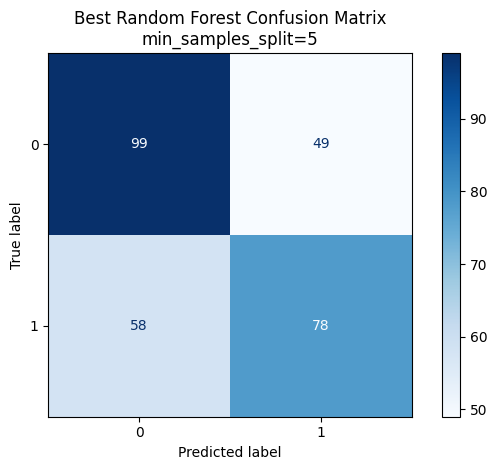

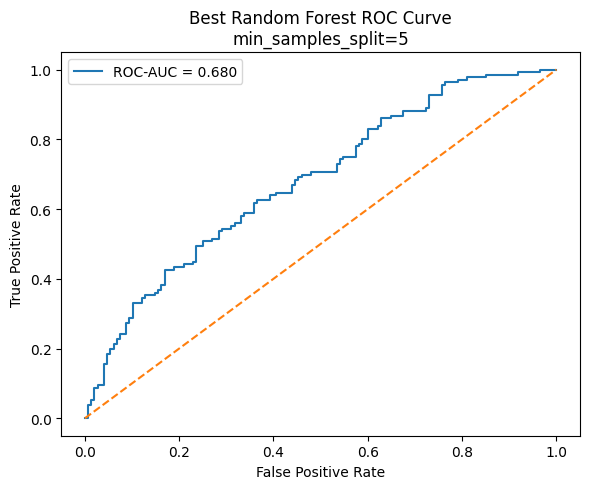

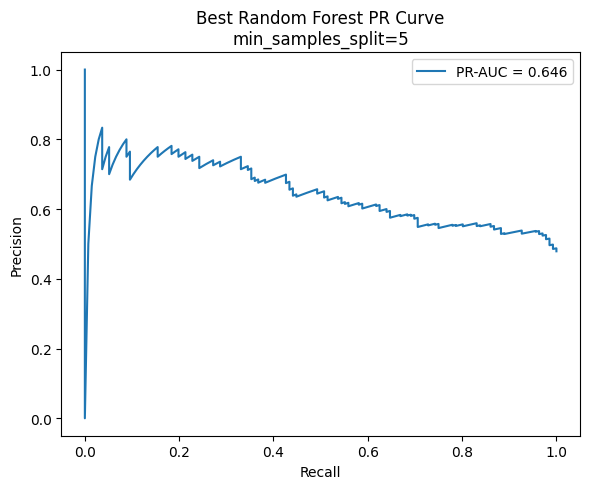

In [ ]:
# -----------------------------
# Manual tuning for min_samples_split
# Fixed best parameters:
# n_estimators = 500
# max_depth = 10
# -----------------------------

min_samples_split_values = [2, 5, 10, 20]

rf_split_results = []

best_score = -1
best_split = None
best_model = None

for split in min_samples_split_values:

    print("\n====================================")
    print(f"Testing min_samples_split = {split}")
    print("====================================")

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=split,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(X_train_var, y_train)

    pred = model.predict(X_test_var)
    prob = model.predict_proba(X_test_var)[:, 1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc_auc)
    print("PR-AUC   :", pr_auc)

    rf_split_results.append({
        "min_samples_split": split,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    if roc_auc > best_score:
        best_score = roc_auc
        best_split = split
        best_model = model

# -----------------------------
# Results summary
# -----------------------------
rf_split_results_df = pd.DataFrame(rf_split_results)

print("\nRandom Forest min_samples_split Tuning Results:")
print(rf_split_results_df)

print("\nBest min_samples_split:", best_split)
print("Best ROC-AUC:", best_score)

# -----------------------------
# Final best model evaluation
# -----------------------------
pred = best_model.predict(X_test_var)
prob = best_model.predict_proba(X_test_var)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Best Random Forest Confusion Matrix\nmin_samples_split={best_split}")
plt.tight_layout()
plt.show()

# -----------------------------
# ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {best_score:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Best Random Forest ROC Curve\nmin_samples_split={best_split}")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# PR curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Best Random Forest PR Curve\nmin_samples_split={best_split}")
plt.legend()
plt.tight_layout()
plt.show()

   min_samples_split   ROC_AUC  Accuracy    PR_AUC
0                  2  0.676272  0.626761  0.646957
1                  5  0.679551  0.623239  0.648000
2                 10  0.677415  0.623239  0.646000
3                 20  0.678557  0.623239  0.647000


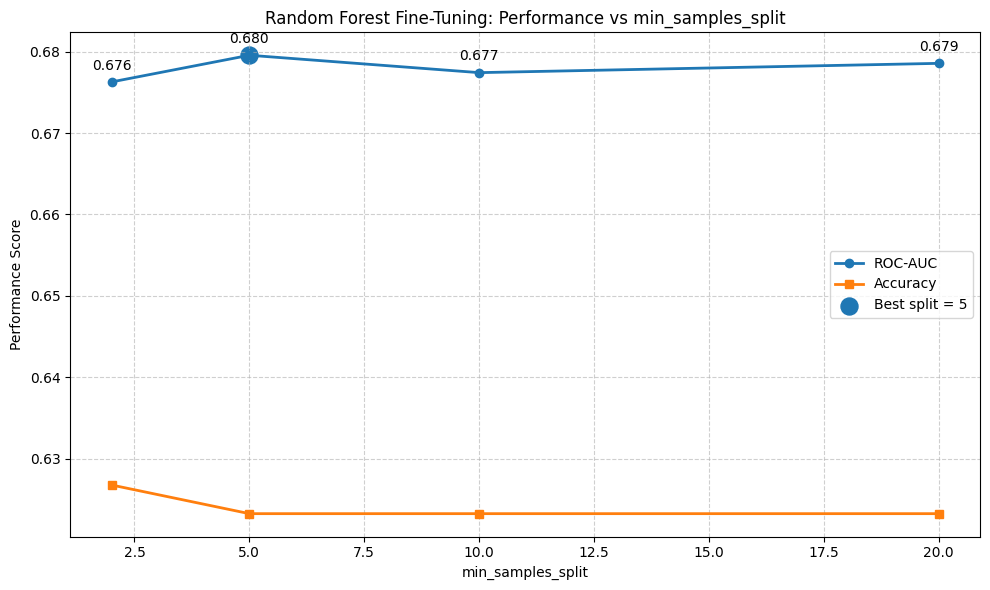

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# min_samples_split tuning results
# -----------------------------
split_results_df = pd.DataFrame({
    "min_samples_split": [2, 5, 10, 20],
    "ROC_AUC": [0.676272, 0.679551, 0.677415, 0.678557],
    "Accuracy": [0.626761, 0.623239, 0.623239, 0.623239],
    "PR_AUC": [0.646957, 0.648000, 0.646000, 0.647000]  # replace with exact values if available
})

print(split_results_df)

# -----------------------------
# Plot performance vs min_samples_split
# -----------------------------
plt.figure(figsize=(10,6))

# ROC-AUC
plt.plot(
    split_results_df["min_samples_split"],
    split_results_df["ROC_AUC"],
    marker='o',
    linewidth=2,
    label="ROC-AUC"
)

# Accuracy
plt.plot(
    split_results_df["min_samples_split"],
    split_results_df["Accuracy"],
    marker='s',
    linewidth=2,
    label="Accuracy"
)

# Highlight best ROC-AUC
best_idx = split_results_df["ROC_AUC"].idxmax()
best_split = split_results_df.loc[best_idx, "min_samples_split"]
best_score = split_results_df.loc[best_idx, "ROC_AUC"]

plt.scatter(
    best_split,
    best_score,
    s=150,
    label=f"Best split = {best_split}"
)

# Annotate ROC-AUC values
for _, row in split_results_df.iterrows():
    plt.text(
        row["min_samples_split"],
        row["ROC_AUC"] + 0.0015,
        f"{row['ROC_AUC']:.3f}",
        ha='center'
    )

plt.xlabel("min_samples_split")
plt.ylabel("Performance Score")
plt.title("Random Forest Fine-Tuning: Performance vs min_samples_split")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

## Unsupervised Learning

Original feature count: 29165
Reduced feature count: 231


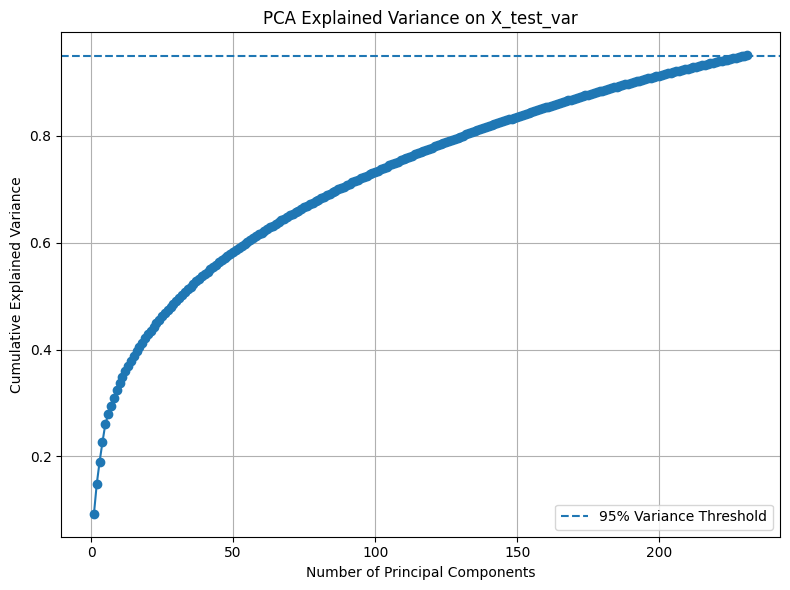

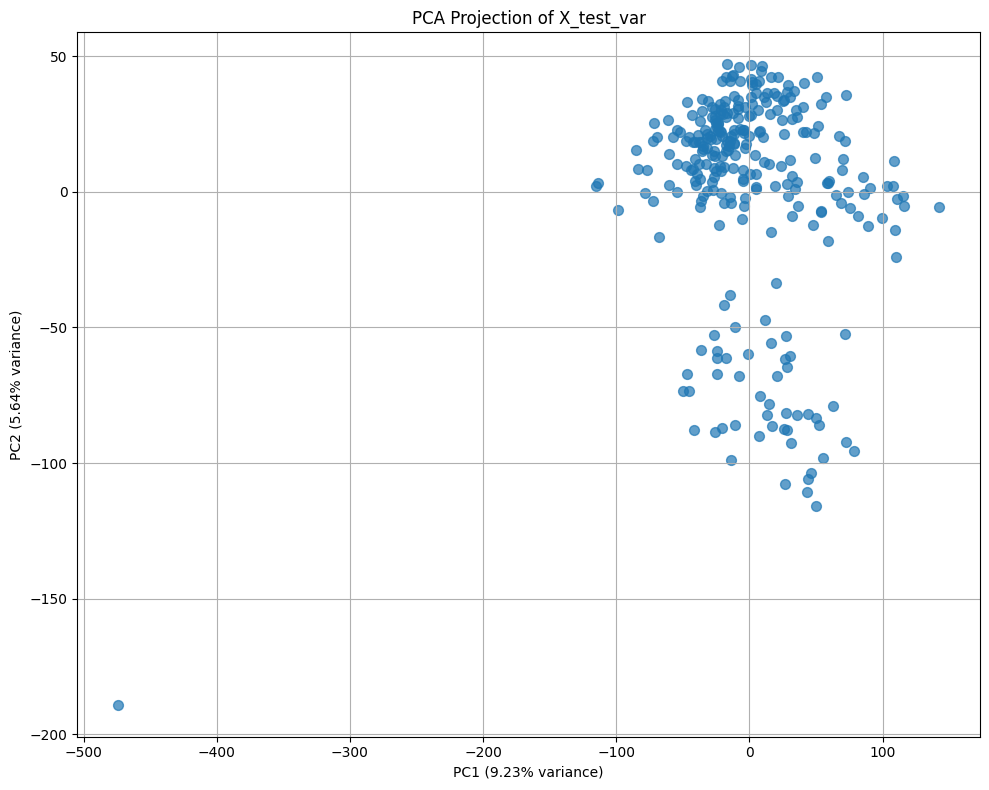

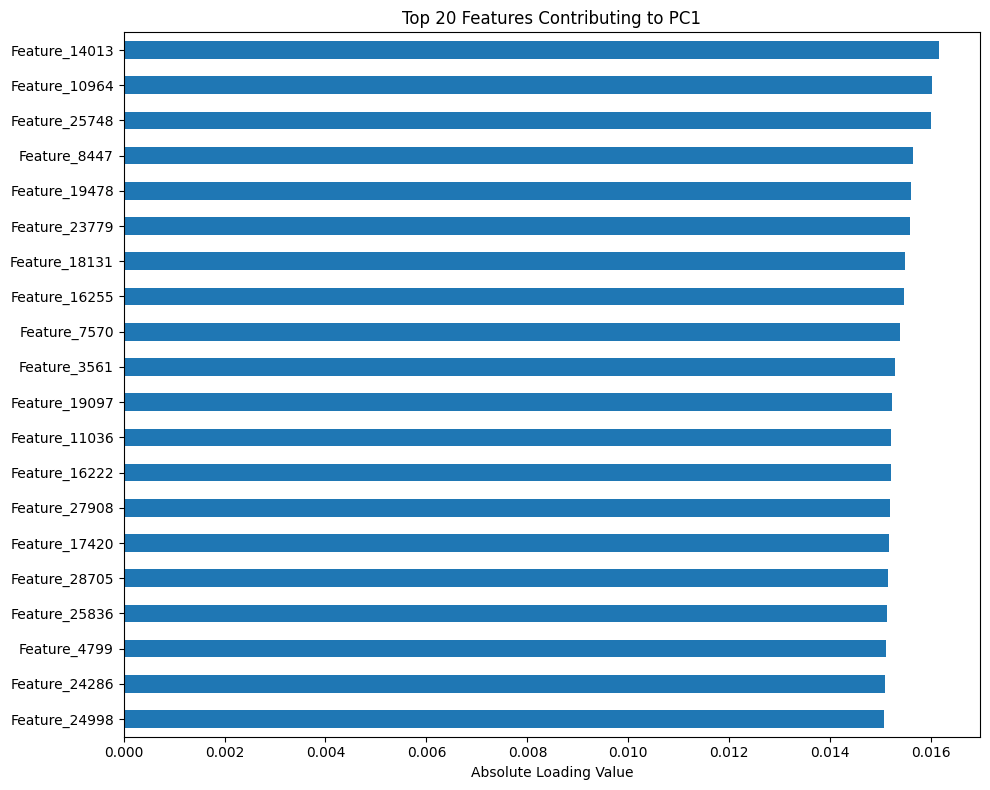


Top 20 features contributing to PC1:
Feature_14013    0.016160
Feature_10964    0.016014
Feature_25748    0.016003
Feature_8447     0.015634
Feature_19478    0.015610
Feature_23779    0.015587
Feature_18131    0.015475
Feature_16255    0.015456
Feature_7570     0.015384
Feature_3561     0.015278
Feature_19097    0.015227
Feature_11036    0.015214
Feature_16222    0.015195
Feature_27908    0.015180
Feature_17420    0.015161
Feature_28705    0.015137
Feature_25836    0.015120
Feature_4799     0.015110
Feature_24286    0.015088
Feature_24998    0.015070
dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------
# PCA on your processed dataset
# Using X_test_var directly
# -----------------------------

# Standardize features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_test_var)

# -----------------------------
# PCA retaining 95% variance
# -----------------------------
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original feature count:", X_test_var.shape[1])
print("Reduced feature count:", X_pca.shape[1])

# -----------------------------
# Explained variance plot
# -----------------------------
explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Variance Threshold'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance on X_test_var")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# PCA scatter plot
# -----------------------------
pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)

# Optional:
# Add labels if available
# Example:
# pca_df["CancerType"] = merged.loc[X_test.index, "CANCER_TYPE"].values

plt.figure(figsize=(10,8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.7,
    s=50
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)"
)

plt.title("PCA Projection of X_test_var")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Top features contributing to PC1
# -----------------------------
if hasattr(X_test_var, "columns"):
    feature_names = X_test_var.columns
else:
    feature_names = [f"Feature_{i}" for i in range(X_test_var.shape[1])]

pc1_loadings = pd.Series(
    pca.components_[0],
    index=feature_names
)

top_pc1 = pc1_loadings.abs().sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(10,8))

top_pc1.sort_values().plot(
    kind="barh"
)

plt.xlabel("Absolute Loading Value")
plt.title("Top 20 Features Contributing to PC1")
plt.tight_layout()
plt.show()

print("\nTop 20 features contributing to PC1:")
print(top_pc1)


Top 20 REAL gene names contributing to PC1:
MATR3       0.016160
KHDRBS1     0.016014
TIA1        0.016003
GPATCH8     0.015634
RBBP4       0.015610
SMARCAD1    0.015587
POGZ        0.015475
NRF1        0.015456
FOXJ3       0.015384
CELF1       0.015278
PUM2        0.015227
KIF2A       0.015214
NR2C2       0.015195
WDR33       0.015180
PDS5A       0.015161
ZNF451      0.015137
TLK2        0.015120
CTDSPL2     0.015110
SON         0.015088
SUGP1       0.015070
dtype: float64


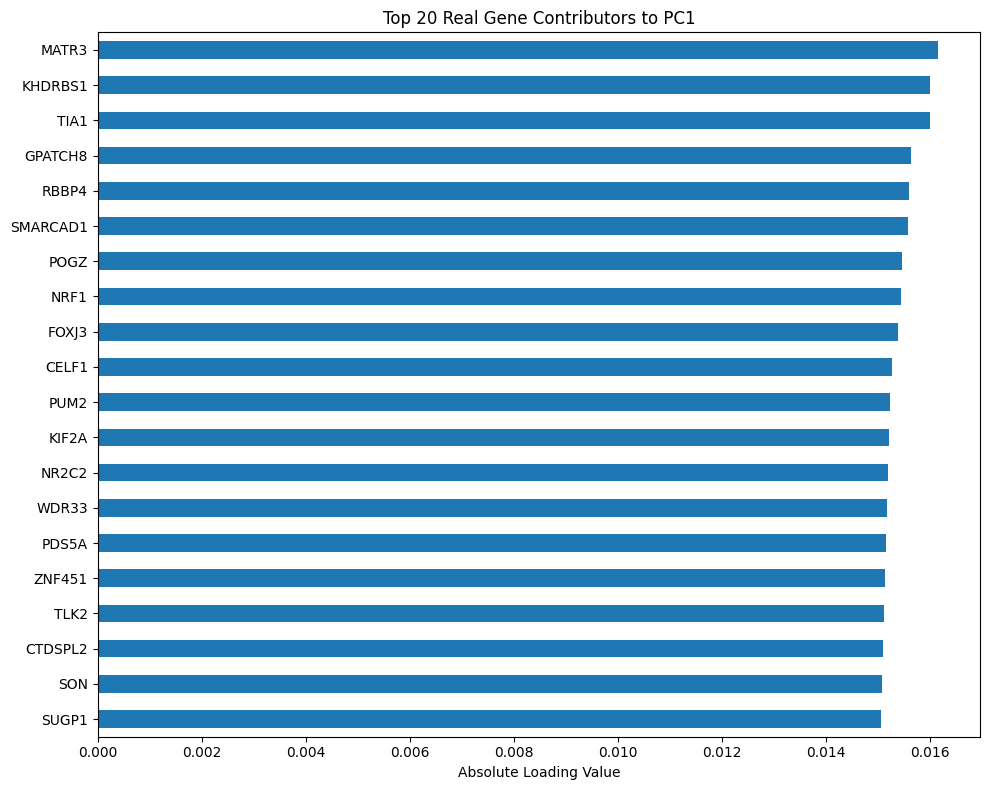

In [ ]:
# -----------------------------
# Recover original gene names
# from PCA-selected features
# -----------------------------

# After variance threshold
selected_feature_names = X_train_num.columns[selector.get_support()]

# Create proper PC1 loading series
pc1_loadings = pd.Series(
    pca.components_[0],
    index=selected_feature_names
)

# Top 20 genes contributing to PC1
top_pc1_genes = pc1_loadings.abs().sort_values(
    ascending=False
).head(20)

print("\nTop 20 REAL gene names contributing to PC1:")
print(top_pc1_genes)

# -----------------------------
# Optional visualization
# -----------------------------
plt.figure(figsize=(10,8))

top_pc1_genes.sort_values().plot(
    kind="barh"
)

plt.xlabel("Absolute Loading Value")
plt.title("Top 20 Real Gene Contributors to PC1")
plt.tight_layout()
plt.show()

Selected top PCA genes:
['MATR3', 'KHDRBS1', 'TIA1', 'GPATCH8', 'RBBP4', 'SMARCAD1', 'POGZ', 'NRF1', 'FOXJ3', 'CELF1', 'PUM2', 'KIF2A', 'NR2C2', 'WDR33', 'PDS5A', 'ZNF451', 'TLK2', 'CTDSPL2', 'SON', 'SUGP1']

Logistic Regression using Top PCA Genes
Accuracy : 0.5598591549295775
Precision: 0.544
Recall   : 0.5
F1-score : 0.5210727969348659
ROC-AUC  : 0.575516693163752
PR-AUC   : 0.5856958016993375

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.61      0.59       148
           1       0.54      0.50      0.52       136

    accuracy                           0.56       284
   macro avg       0.56      0.56      0.56       284
weighted avg       0.56      0.56      0.56       284



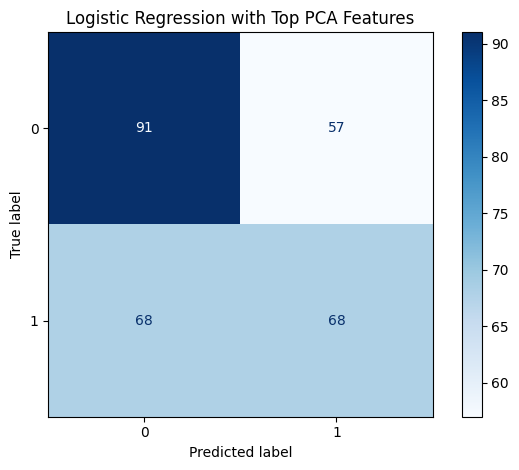

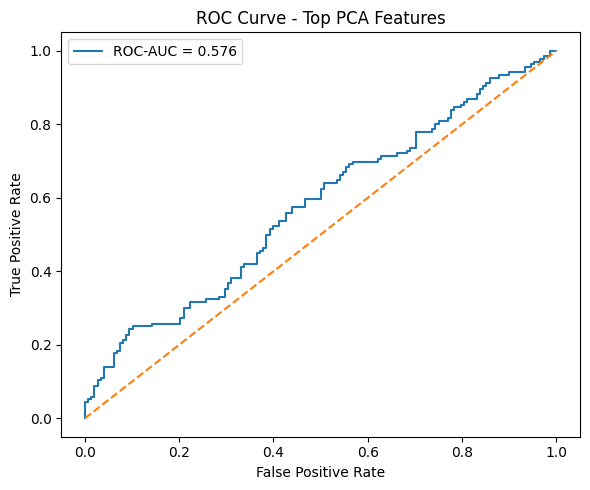

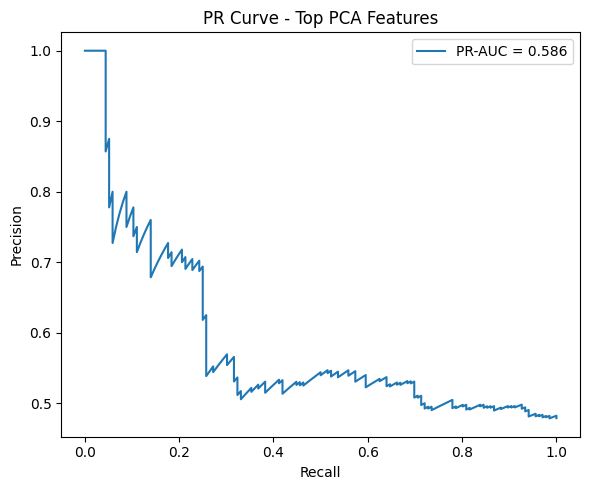

In [ ]:
# -----------------------------
# Logistic Regression using
# Top PCA-contributing genes only
# -----------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)

# -----------------------------
# 1. Get top 20 PC1 genes
# -----------------------------
top_genes = top_pc1_genes.index.tolist()

print("Selected top PCA genes:")
print(top_genes)

# -----------------------------
# 2. Extract those genes
# -----------------------------
X_train_top = X_train_num[top_genes]
X_test_top  = X_test_num[top_genes]

# -----------------------------
# 3. Impute missing values
# -----------------------------
imputer = SimpleImputer(strategy="median")

X_train_top_imp = imputer.fit_transform(X_train_top)
X_test_top_imp  = imputer.transform(X_test_top)

# -----------------------------
# 4. Standardize
# -----------------------------
scaler = StandardScaler()

X_train_top_scaled = scaler.fit_transform(X_train_top_imp)
X_test_top_scaled  = scaler.transform(X_test_top_imp)

# -----------------------------
# 5. Train Logistic Regression
# -----------------------------
model = LogisticRegression(
    C=0.001,                # Best previously tuned
    penalty="l2",
    solver="lbfgs",
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_top_scaled, y_train)

# -----------------------------
# 6. Predict
# -----------------------------
pred = model.predict(X_test_top_scaled)
prob = model.predict_proba(X_test_top_scaled)[:, 1]

# -----------------------------
# 7. Metrics
# -----------------------------
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_auc = roc_auc_score(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

print("\nLogistic Regression using Top PCA Genes")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# 8. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Logistic Regression with Top PCA Features")
plt.tight_layout()
plt.show()

# -----------------------------
# 9. ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Top PCA Features")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Precision-Recall curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve - Top PCA Features")
plt.legend()
plt.tight_layout()
plt.show()

Selected top PCA genes:
['MATR3', 'KHDRBS1', 'TIA1', 'GPATCH8', 'RBBP4', 'SMARCAD1', 'POGZ', 'NRF1', 'FOXJ3', 'CELF1', 'PUM2', 'KIF2A', 'NR2C2', 'WDR33', 'PDS5A', 'ZNF451', 'TLK2', 'CTDSPL2', 'SON', 'SUGP1']

XGBoost using Top PCA Genes
Accuracy : 0.545774647887324
Precision: 0.5238095238095238
Recall   : 0.5661764705882353
F1-score : 0.5441696113074205
ROC-AUC  : 0.5612082670906201
PR-AUC   : 0.5300045578006204

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.53      0.55       148
           1       0.52      0.57      0.54       136

    accuracy                           0.55       284
   macro avg       0.55      0.55      0.55       284
weighted avg       0.55      0.55      0.55       284



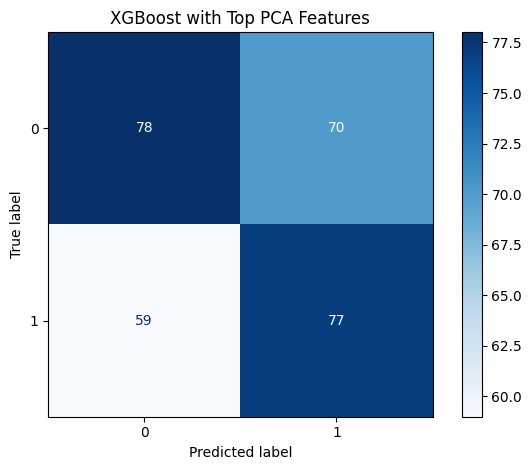

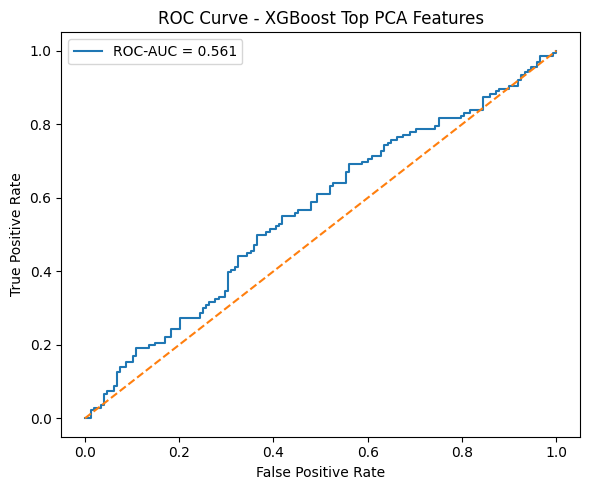

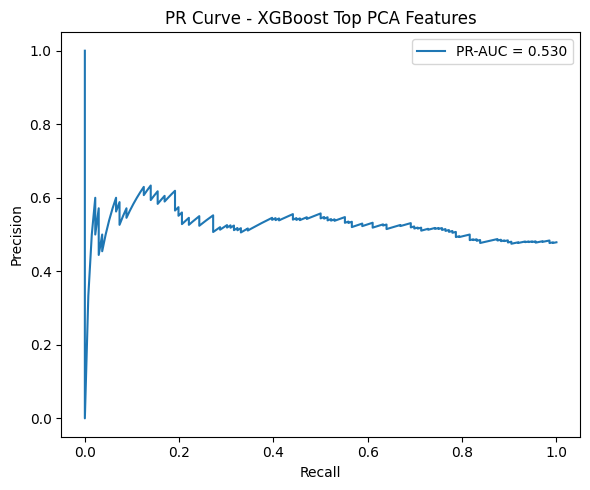


XGBoost Feature Importance:
KIF2A       0.063347
SUGP1       0.059178
TIA1        0.057313
SMARCAD1    0.055533
ZNF451      0.055255
MATR3       0.053480
CTDSPL2     0.051259
FOXJ3       0.050625
POGZ        0.050066
SON         0.049587
PDS5A       0.048710
GPATCH8     0.047600
WDR33       0.047423
NR2C2       0.046450
RBBP4       0.045936
KHDRBS1     0.045565
CELF1       0.045361
PUM2        0.043911
TLK2        0.043644
NRF1        0.039757
dtype: float32


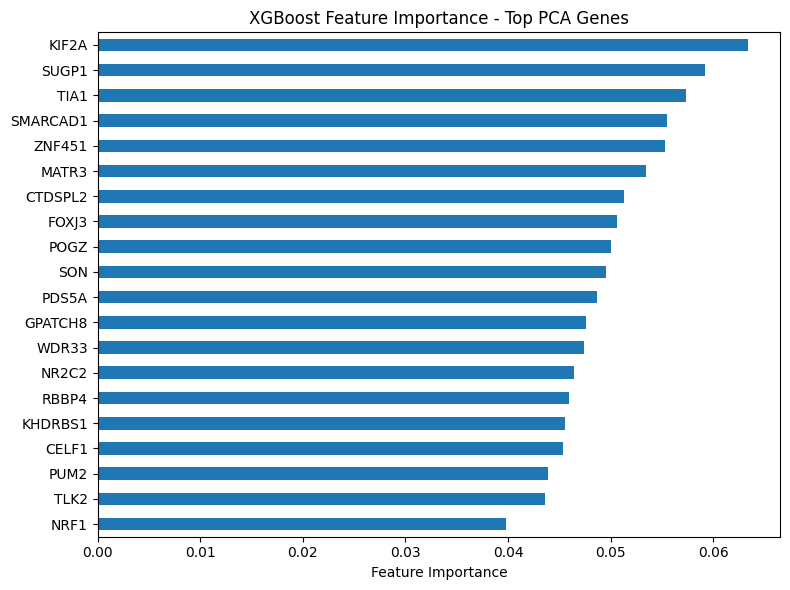

In [ ]:
# -----------------------------
# XGBoost using
# Top PCA-contributing genes only
# -----------------------------

from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)

import matplotlib.pyplot as plt

# -----------------------------
# 1. Get top 20 PC1 genes
# -----------------------------
top_genes = top_pc1_genes.index.tolist()

print("Selected top PCA genes:")
print(top_genes)

# -----------------------------
# 2. Extract those genes
# -----------------------------
X_train_top = X_train_num[top_genes]
X_test_top  = X_test_num[top_genes]

# -----------------------------
# 3. Impute missing values
# -----------------------------
imputer = SimpleImputer(strategy="median")

X_train_top_imp = imputer.fit_transform(X_train_top)
X_test_top_imp  = imputer.transform(X_test_top)

# -----------------------------
# 4. Standardize
# Note: XGBoost does not require scaling,
# but we keep it for fair comparison with Logistic Regression
# -----------------------------
scaler = StandardScaler()

X_train_top_scaled = scaler.fit_transform(X_train_top_imp)
X_test_top_scaled  = scaler.transform(X_test_top_imp)

# -----------------------------
# 5. Train XGBoost
# -----------------------------
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_top_scaled, y_train)

# -----------------------------
# 6. Predict
# -----------------------------
pred = model.predict(X_test_top_scaled)
prob = model.predict_proba(X_test_top_scaled)[:, 1]

# -----------------------------
# 7. Metrics
# -----------------------------
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_auc = roc_auc_score(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

print("\nXGBoost using Top PCA Genes")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# 8. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("XGBoost with Top PCA Features")
plt.tight_layout()
plt.show()

# -----------------------------
# 9. ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Top PCA Features")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Precision-Recall curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve - XGBoost Top PCA Features")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 11. Feature importance
# -----------------------------
importance = model.feature_importances_

xgb_importance = pd.Series(
    importance,
    index=top_genes
).sort_values(ascending=False)

print("\nXGBoost Feature Importance:")
print(xgb_importance)

plt.figure(figsize=(8,6))
xgb_importance.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance - Top PCA Genes")
plt.tight_layout()
plt.show()


XGBoost using Variance Threshold Features
Accuracy : 0.6267605633802817
Precision: 0.6056338028169014
Recall   : 0.6323529411764706
F1-score : 0.6187050359712231
ROC-AUC  : 0.6989765500794912
PR-AUC   : 0.6596767498165483

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.62      0.63       148
           1       0.61      0.63      0.62       136

    accuracy                           0.63       284
   macro avg       0.63      0.63      0.63       284
weighted avg       0.63      0.63      0.63       284



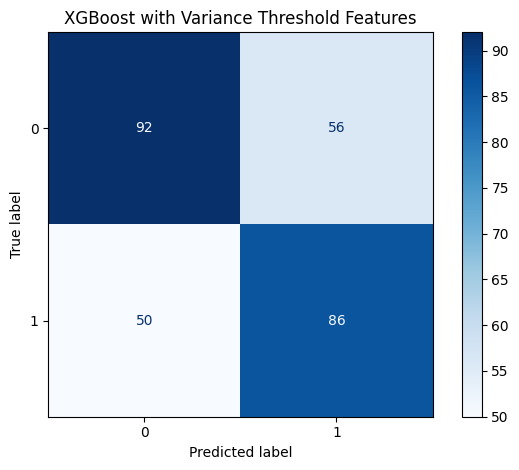

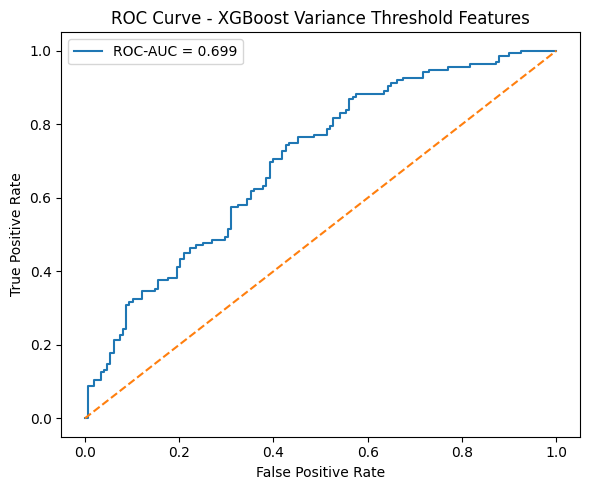

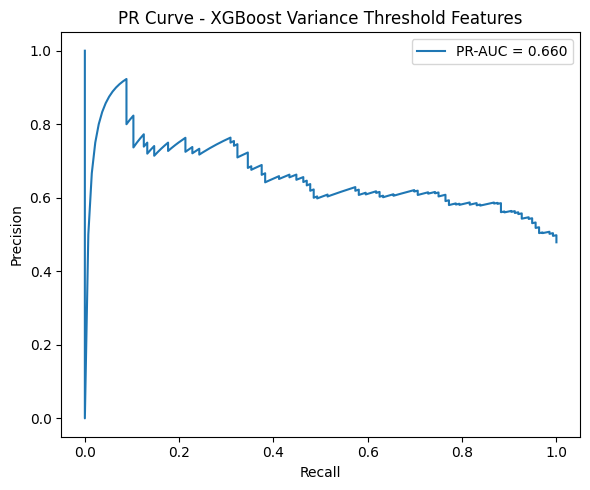

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# XGBoost using Variance Threshold features
# -----------------------------

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_var, y_train)

# -----------------------------
# Predict
# -----------------------------
pred = model.predict(X_test_var)
prob = model.predict_proba(X_test_var)[:, 1]

# -----------------------------
# Metrics
# -----------------------------
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_auc = roc_auc_score(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

print("\nXGBoost using Variance Threshold Features")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("XGBoost with Variance Threshold Features")
plt.tight_layout()
plt.show()

# -----------------------------
# ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Variance Threshold Features")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Precision-Recall curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve - XGBoost Variance Threshold Features")
plt.legend()
plt.tight_layout()
plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     7,466,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,509,249 (28.65 MB)

 Trainable params: 7,508,481 (28.64 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 285ms/step - accuracy: 0.5398 - loss: 1.8074 - val_accuracy: 0.5379 - val_loss: 2.9508
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.6515 - loss: 1.4911 - val_accuracy: 0.5455 - val_loss: 1.9241
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step - accuracy: 0.7064 - loss: 1.3876 - val_accuracy: 0.5909 - val_loss: 1.6689
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.7689 - loss: 1.2878 - val_accuracy: 0.5758 - val_loss: 1.6050
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - accuracy: 0.8617 - loss: 1.1665 - val_accuracy: 0.5606 - val_loss: 1.5874
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.8409 - loss: 1.1576 - val_accuracy: 0.5758 - val_loss: 1.5709
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.8617 - loss: 1.1192 - val_accuracy: 0.6212 - val_loss: 1.5278
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.9167 - loss: 1.0243 - val_acc

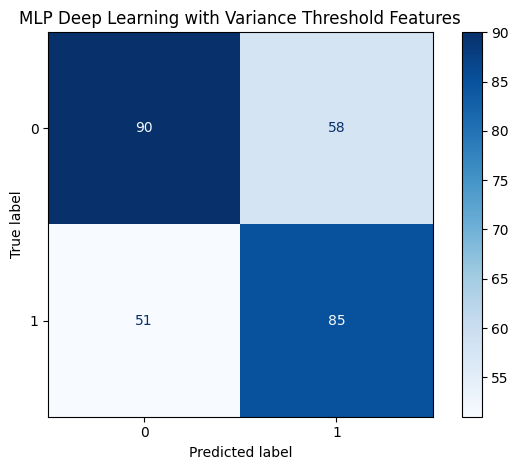

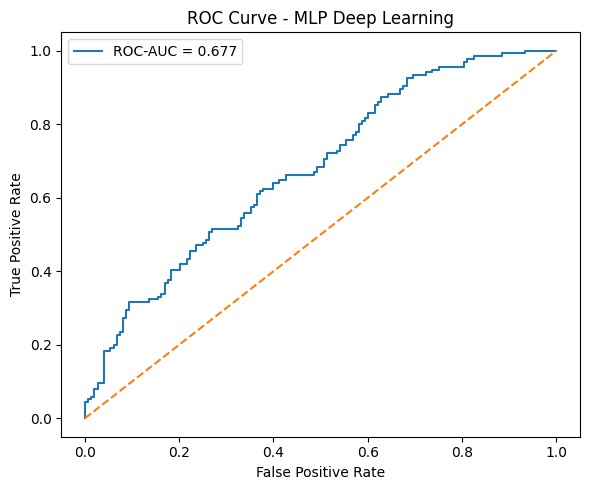

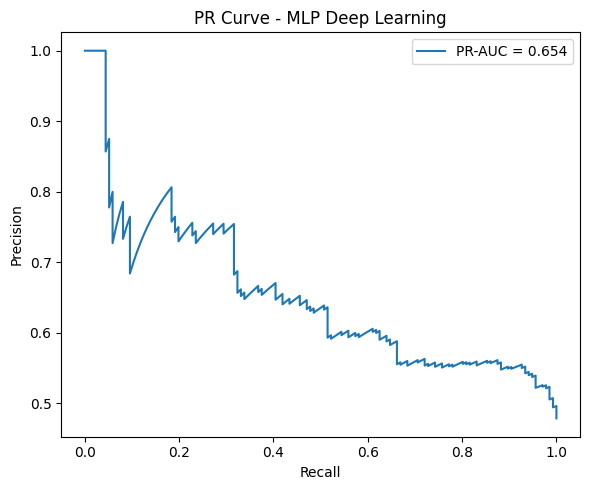

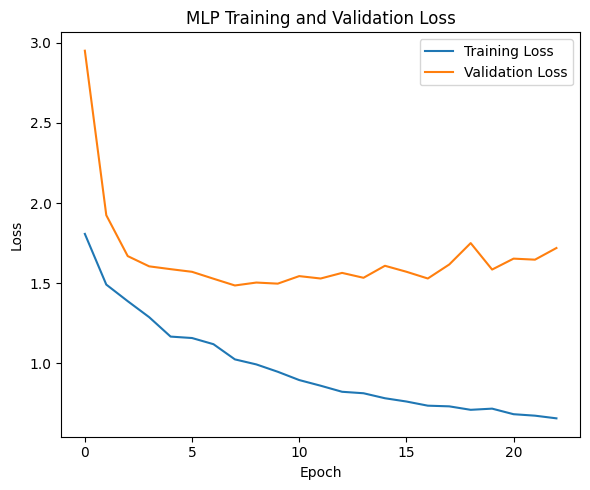

In [ ]:
# -----------------------------
# Deep Learning: MLP using Variance Threshold features
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# -----------------------------
# 1. Impute missing values
# -----------------------------
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train_var)
X_test_imp  = imputer.transform(X_test_var)

# -----------------------------
# 2. Standardize features
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# -----------------------------
# 3. Define MLP model
# -----------------------------
model = Sequential([
    Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(0.001),
        input_shape=(X_train_scaled.shape[1],)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

# -----------------------------
# 4. Compile model
# -----------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# 5. Early stopping
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

# -----------------------------
# 6. Train model
# -----------------------------
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------
# 7. Predict
# -----------------------------
prob = model.predict(X_test_scaled).ravel()
pred = (prob >= 0.5).astype(int)

# -----------------------------
# 8. Metrics
# -----------------------------
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_auc = roc_auc_score(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

print("\nDeep Learning MLP using Variance Threshold Features")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# 9. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("MLP Deep Learning with Variance Threshold Features")
plt.tight_layout()
plt.show()

# -----------------------------
# 10. ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP Deep Learning")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 11. Precision-Recall curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve - MLP Deep Learning")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 12. Training history
# -----------------------------
plt.figure(figsize=(6,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# Advanced Deep Learning:
# 1D CNN using Variance Threshold features
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# -----------------------------
# 1. Impute missing values
# -----------------------------
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train_var)
X_test_imp  = imputer.transform(X_test_var)

# -----------------------------
# 2. Standardize features
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# -----------------------------
# 3. Reshape for 1D CNN
# Shape: samples, features, channels
# -----------------------------
X_train_cnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

# -----------------------------
# 4. Define CNN model
# -----------------------------
model = Sequential([
    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        input_shape=(X_train_cnn.shape[1], 1)
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(
        filters=256,
        kernel_size=3,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    GlobalAveragePooling1D(),

    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.4),

    Dense(1, activation="sigmoid")
])

# -----------------------------
# 5. Compile model
# -----------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# 6. Callbacks
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

# -----------------------------
# 7. Train model
# -----------------------------
history = model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# -----------------------------
# 8. Predict
# -----------------------------
prob = model.predict(X_test_cnn).ravel()
pred = (prob >= 0.5).astype(int)

# -----------------------------
# 9. Metrics
# -----------------------------
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_auc = roc_auc_score(y_test, prob)
pr_auc = average_precision_score(y_test, prob)

print("\nAdvanced Deep Learning: 1D CNN using Variance Threshold Features")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# 10. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("1D CNN with Variance Threshold Features")
plt.tight_layout()
plt.show()

# -----------------------------
# 11. ROC curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 1D CNN")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 12. Precision-Recall curve
# -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve - 1D CNN")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 13. Training history
# -----------------------------
plt.figure(figsize=(6,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1D CNN Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 29165, 64)      │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 29165, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14582, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14582, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 14582, 128)     │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14582, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7291, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7291, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7291, 256)      │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7291, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,849 (683.00 KB)

 Trainable params: 173,953 (679.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 237s 13s/step - accuracy: 0.5398 - loss: 1.1101 - val_accuracy: 0.5227 - val_loss: 1.1106 - learning_rate: 3.0000e-04
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 217s 13s/step - accuracy: 0.5436 - loss: 1.1033 - val_accuracy: 0.4470 - val_loss: 1.1012 - learning_rate: 3.0000e-04
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 253s 12s/step - accuracy: 0.5208 - loss: 1.0987 - val_accuracy: 0.5000 - val_loss: 1.0945 - learning_rate: 3.0000e-04
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 284s 14s/step - accuracy: 0.5208 - loss: 1.0897 - val_accuracy: 0.4848 - val_loss: 1.0841 - learning_rate: 3.0000e-04
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 217s 13s/step - accuracy: 0.5455 - loss: 1.0715 - val_accuracy: 0.5000 - val_loss: 1.0778 - learning_rate: 3.0000e-04
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 216s 13s/step - accuracy: 0.5455 - loss: 1.0634 - val_accuracy: 0.5000 - val_loss: 1.0742 - learning_rate: 3.0000e-04
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 265s 13s/step - acc

KeyboardInterrupt: 